# 2H — Hollow cabinet unified flux and AP dose-rate field

This notebook is the second step in the H-series. It consumes the two final
flux tables produced by
`1H_F1_SIDES_AND_FRONT_F2_Hollow_cabinet_geo_+_n_and_g_runs.ipynb` and uses
the **same fixed asymmetric hollow geometry**:

- rear $-x$ f2 wall: 15 cm solid steel;
- front $+x$ f2 wall: 2 cm steel + 5 cm air + 8 cm steel;
- both f1/$y$ walls: 2 cm steel + 5 cm air + 6 cm steel;
- bottom f3 and top f4: 25 cm and 12 cm solid steel.

The detector-specific neutron and photon fluxes remain separate particle-field
quantities. They are never added. New co-located
$2\times2\times2\ \mathrm{cm^3}$ OpenMC tallies apply energy-dependent
fluence-to-ambient-dose-equivalent conversion coefficients in AP geometry.
Only the compatible dose-rate components are combined:

$$
\dot H_{\mathrm{tot}}=\dot H_n+\dot H_\gamma.
$$

The notebook also retains co-located unweighted neutron and photon fluxes for
diagnostics and produces explicitly labelled instrument-equivalent proxies for
the later comparison notebook. Statistical uncertainties are propagated from
the OpenMC batch standard deviations; model, source, nuclear-data, positioning,
and detector-response uncertainties are outside that statistical budget.


# 1) Setup, fixed hollow geometry, and analysis conventions

The notebook imports the uniquely named verified hollow-model module and checks
its revision marker before constructing any OpenMC model. The cabinet
configuration is fixed to the final three-hollow-face interpretation used in
1H; an older solid or four-sided hollow module therefore cannot be selected by
Python's import cache.

The source is the same source-specific AMN 24 record evaluated on
2026-03-15. ALPHANSO independently supplies the neutron spectrum and the gamma
line yield used for the photon-source normalization.


In [1]:
from pathlib import Path
import importlib
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D

import openmc
import ambe_base_model_f1_sides_and_front_f2_hollow as hollow_model_module

ambe_base_model = hollow_model_module


# Reload after deliberate edits to the shared module.
importlib.reload(hollow_model_module)
ambe_base_model = hollow_model_module


# ------------------------------------------------------------
# Physical normalization date
# ------------------------------------------------------------

EXPERIMENT_DATE = "2026-03-15"

EXPECTED_HOLLOW_MODEL_REVISION = (
    "F1_SIDES_AND_FRONT_F2_HOLLOW_2026-08-14"
)
actual_model_revision = getattr(
    hollow_model_module,
    "HOLLOW_MODEL_REVISION",
    None,
)
if actual_model_revision != EXPECTED_HOLLOW_MODEL_REVISION:
    raise RuntimeError(
        "Incorrect hollow-model module revision: "
        f"expected {EXPECTED_HOLLOW_MODEL_REVISION!r}, "
        f"found {actual_model_revision!r} in "
        f"{hollow_model_module.__file__}."
    )

HOLLOW_CONFIG = hollow_model_module.normalize_cabinet_config(
    hollow_model_module.MEASURED_HOLLOW_CABINET_CONFIG
)
if HOLLOW_CONFIG["hollow_faces"] != ("x_max", "y_min", "y_max"):
    raise AssertionError(
        "2H requires front f2 and both f1 sides to be hollow."
    )
if not HOLLOW_CONFIG["rear_x_wall_solid"]:
    raise AssertionError("The rear (-x) f2 wall must remain solid.")


# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

OUTPUT_DIR = Path("H2_hollow_cabinet_unified_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"
OPENMC_RUN_DIR = OUTPUT_DIR / "openmc_runs"
H1_OUTPUT_DIR = Path("H1_f1_sides_and_front_f2_hollow_transport_outputs")

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)
OPENMC_RUN_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Shared model and source record
# ------------------------------------------------------------

base = ambe_base_model.build_base_model(
    export_xml=False,
    verbose=True,
    cabinet_config=HOLLOW_CONFIG,
    source_evaluation_date=EXPERIMENT_DATE,
)

globals().update(base)

if base.get("CABINET_CONFIG") != HOLLOW_CONFIG:
    raise AssertionError(
        "The built OpenMC model does not use the fixed H-series geometry."
    )

required_base_names = [
    "geometry",
    "materials",
    "CABINET_ZMIN",
    "SOURCE_MANUFACTURER",
    "SOURCE_MODEL",
    "SOURCE_SERIAL_NUMBER",
    "SOURCE_NEUTRON_EMISSION_REF",
    "SOURCE_NEUTRON_EMISSION_REF_DATE",
    "SOURCE_NEUTRON_EMISSION",
    "SOURCE_EVALUATION_DATE",
    "SOURCE_NORMALIZATION_STATUS",
]

missing_base_names = [
    name for name in required_base_names
    if name not in globals()
]

if missing_base_names:
    raise NameError(
        "The shared base model is missing: "
        + ", ".join(missing_base_names)
    )

if SOURCE_EVALUATION_DATE != EXPERIMENT_DATE:
    raise ValueError(
        "The shared source model did not use the selected experiment date. "
        f"Expected {EXPERIMENT_DATE}, got {SOURCE_EVALUATION_DATE}."
    )


# ------------------------------------------------------------
# Neutron and gamma source distributions
# ------------------------------------------------------------

neutron_energy_dist = ambe_base_model.build_ambe_energy_distribution(
    make_plot=False,
    verbose=False,
)

gamma_energy_dist, gamma_data = (
    ambe_base_model.build_ambe_gamma_line_distribution(
        make_plot=False,
        verbose=True,
    )
)

alphanso_results = gamma_data.get("alphanso_results")

if not isinstance(alphanso_results, dict):
    raise RuntimeError(
        "ALPHANSO results are required for the final gamma-source "
        "normalization."
    )

if "an_yield" in alphanso_results:
    alphanso_neutron_yield = float(alphanso_results["an_yield"])
    alphanso_neutron_yield_key = "an_yield"
elif "combined_yield" in alphanso_results:
    alphanso_neutron_yield = float(alphanso_results["combined_yield"])
    alphanso_neutron_yield_key = "combined_yield"
else:
    raise KeyError(
        "ALPHANSO results contain neither 'an_yield' nor "
        "'combined_yield'."
    )

alphanso_gamma_yield = float(gamma_data["gamma_yield"])

for name, value in [
    ("ALPHANSO neutron yield", alphanso_neutron_yield),
    ("ALPHANSO gamma yield", alphanso_gamma_yield),
]:
    if not np.isfinite(value) or value <= 0.0:
        raise ValueError(f"{name} must be finite and positive; got {value}.")

GAMMA_TO_NEUTRON_RATIO_ALPHANSO = (
    alphanso_gamma_yield / alphanso_neutron_yield
)

GAMMA_SOURCE_EMISSION = (
    GAMMA_TO_NEUTRON_RATIO_ALPHANSO
    * SOURCE_NEUTRON_EMISSION
)

GAMMA_SOURCE_NORMALIZATION_STATUS = (
    "decay-corrected source-specific neutron emission multiplied by the "
    "ALPHANSO total gamma-to-neutron yield ratio"
)


# ------------------------------------------------------------
# Monte Carlo uncertainty convention
# ------------------------------------------------------------

MC_LOW_U_MAX_PERCENT = 5.0
MC_MODERATE_U_MAX_PERCENT = 10.0
MC_HIGH_U_MAX_PERCENT = 25.0

# Notebook 1H gamma workflow may not reach its originally configured 10% group-1 target.
# Its flux estimates and actual pointwise uncertainties are nevertheless retained
# for the GCA-equivalent proxy. This switch permits that documented handoff.
ALLOW_UNCONVERGED_H1_GAMMA_INPUT = True
H1_GAMMA_INPUT_REFERENCE_LIMIT_PERCENT = 50.0

MC_UNCERTAINTY_ORDER = [
    "low",
    "moderate",
    "high",
    "very high",
    "unknown",
]


def classify_relative_mc_uncertainty(relative_uncertainty_percent):
    if not np.isfinite(relative_uncertainty_percent):
        return "unknown"
    if relative_uncertainty_percent < MC_LOW_U_MAX_PERCENT:
        return "low"
    if relative_uncertainty_percent < MC_MODERATE_U_MAX_PERCENT:
        return "moderate"
    if relative_uncertainty_percent < MC_HIGH_U_MAX_PERCENT:
        return "high"
    return "very high"


# ------------------------------------------------------------
# Shared P1--P5 plot style
# ------------------------------------------------------------

POSITION_ORDER = ["P1", "P2", "P3", "P4", "P5"]

POSITION_COLORS = {
    "P1": "tab:blue",
    "P2": "tab:orange",
    "P3": "tab:green",
    "P4": "tab:red",
    "P5": "tab:purple",
}


def lighten_color(color, amount):
    """Blend a Matplotlib colour with white."""

    base_rgb = np.asarray(to_rgb(color), dtype=float)
    white_rgb = np.ones(3)
    return tuple((1.0 - amount) * base_rgb + amount * white_rgb)


def make_position_height_colors(dataframe):
    """Return fixed position colours with lighter shades at higher heights."""

    color_map = {}

    for position in POSITION_ORDER:
        heights = np.sort(
            dataframe.loc[
                dataframe["position"] == position,
                "height_cm",
            ]
            .dropna()
            .unique()
        )

        if len(heights) == 0:
            continue

        if len(heights) == 1:
            lightening_amounts = np.array([0.0])
        else:
            lightening_amounts = np.linspace(0.0, 0.48, len(heights))

        for height_cm, amount in zip(heights, lightening_amounts):
            color_map[(position, float(height_cm))] = lighten_color(
                POSITION_COLORS[position],
                amount,
            )

    return color_map


print("Notebook 2H setup complete.")
print(f"Hollow model revision:      {actual_model_revision}")
print(f"Hollow faces:               {HOLLOW_CONFIG['hollow_faces']}")
print(f"Physical source:            {SOURCE_MODEL}, {SOURCE_SERIAL_NUMBER}")
print(
    "Factory neutron emission:  "
    f"{SOURCE_NEUTRON_EMISSION_REF:.6e} n/s on "
    f"{SOURCE_NEUTRON_EMISSION_REF_DATE}"
)
print(
    "Selected neutron emission: "
    f"{SOURCE_NEUTRON_EMISSION:.6e} n/s on "
    f"{SOURCE_EVALUATION_DATE}"
)
print(f"Gamma/neutron yield ratio: {GAMMA_TO_NEUTRON_RATIO_ALPHANSO:.6e}")
print(f"Selected gamma emission:   {GAMMA_SOURCE_EMISSION:.6e} photons/s")
print(f"Output folder:             {OUTPUT_DIR}")


Geometry summary:
  Cabinet outer dimensions      = 85.0 x 67.0 x 96.0 cm
  Cabinet x-wall thickness      = 15.0 cm
  Cabinet y-wall thickness      = 13.0 cm
  Hollow cabinet faces          = ('x_max', 'y_min', 'y_max')
  Rear (-x) f2 wall              = 15.0 cm solid steel
  Front (+x) f2 wall stack       = 2.0 cm steel + 5.0 cm air + 8.0 cm steel
  Both f1/y wall stacks          = 2.0 cm steel + 5.0 cm air + 6.0 cm steel
  Cabinet bottom thickness      = 25.0 cm
  Cabinet top thickness         = 12.0 cm
  Cabinet z range               = -41.0 to 55.0 cm
  Cabinet inner x width         = 55.0 cm
  Cabinet inner y width         = 41.0 cm
  Cabinet inner z height        = 59.0 cm
  Cabinet inner z range         = -16.0 to 43.0 cm
  Paraffin radius               = 14.500 cm
  Paraffin height               = 32.000 cm
  Paraffin z range              = -16.000 to 16.000 cm
  Plastic outer radius          = 4.500 cm
  Plastic inner radius          = 4.400 cm
  Source outer radius           

# 2) Load and match the two 1H flux-coordinate systems

The neutron flux is scored in the 2 cm virtual cube centred at the Studsvik
reference position. The photon flux is scored in the finite LND 712 active gas
cylinder. Their physical centres are therefore retained separately and are
matched only by the nominal P1–P5 placement, distance, and height.

This section deliberately accepts only the final H1 output paths. If the gamma
run is still underway, the missing-file message is the expected stopping point;
rerun 2H after 1H has written both final CSV files.


In [2]:
def find_first_existing_file(candidates, label):
    """Return the first existing project file from an ordered candidate list."""

    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            print(f"Found {label}: {candidate}")
            return candidate

    candidate_text = "\n".join(f"  {Path(path)}" for path in candidates)
    raise FileNotFoundError(
        f"Could not find {label}. Tried:\n{candidate_text}"
    )


def find_first_existing_column(dataframe, candidates, label):
    """Return the first available column name from a compatibility list."""

    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    raise KeyError(
        f"Could not find {label}. Tried {candidates}. "
        f"Available columns: {dataframe.columns.tolist()}"
    )


def find_optional_column(dataframe, candidates):
    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate
    return None


neutron_flux_path = find_first_existing_file(
    [
        H1_OUTPUT_DIR / "neutron" / "tables"
        / "hollow_neutron_flux_summary_final.csv",
    ],
    "final H1 hollow-cabinet neutron-flux table",
)

gamma_flux_path = find_first_existing_file(
    [
        H1_OUTPUT_DIR / "gamma" / "tables"
        / "hollow_gamma_flux_summary_final.csv",
    ],
    "final H1 hollow-cabinet LND 712 gamma-flux table",
)

neutron_flux_raw = pd.read_csv(neutron_flux_path)
gamma_flux_raw = pd.read_csv(gamma_flux_path)


MATCH_COLUMNS = [
    "point_name",
    "position",
    "distance_cm",
    "height_cm",
]
INPUT_COORDINATE_COLUMNS = ["x_cm", "y_cm", "z_cm"]
REQUIRED_INPUT_COLUMNS = MATCH_COLUMNS + INPUT_COORDINATE_COLUMNS

for table_name, dataframe in [
    ("neutron", neutron_flux_raw),
    ("gamma", gamma_flux_raw),
]:
    missing_columns = [
        column for column in REQUIRED_INPUT_COLUMNS
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The {table_name} flux table is missing required columns: "
            + ", ".join(missing_columns)
        )

    if dataframe["point_name"].duplicated().any():
        duplicates = dataframe.loc[
            dataframe["point_name"].duplicated(keep=False),
            "point_name",
        ].tolist()
        raise ValueError(
            f"The {table_name} table contains duplicate point names: "
            f"{duplicates[:10]}"
        )


neutron_flux_value_col = find_first_existing_column(
    neutron_flux_raw,
    ["flux_physical [n/cm2/s]", "neutron_flux [n/cm2/s]"],
    "physical neutron-flux column",
)
neutron_flux_u_col = find_first_existing_column(
    neutron_flux_raw,
    [
        "u_mc_physical [n/cm2/s]",
        "std_physical [n/cm2/s]",
        "neutron_flux_std [n/cm2/s]",
    ],
    "neutron-flux MC standard-uncertainty column",
)
neutron_flux_rel_u_col = find_first_existing_column(
    neutron_flux_raw,
    ["rel_u_mc [%]", "rel_unc [%]", "neutron_flux_rel_unc [%]"],
    "relative neutron-flux MC uncertainty column",
)

gamma_flux_value_col = find_first_existing_column(
    gamma_flux_raw,
    [
        "gamma_flux_physical [photon/cm2/s]",
        "gamma_flux [photon/cm2/s]",
    ],
    "physical gamma-flux column",
)
gamma_flux_u_col = find_first_existing_column(
    gamma_flux_raw,
    [
        "u_mc_physical [photon/cm2/s]",
        "gamma_std_physical [photon/cm2/s]",
        "gamma_flux_std [photon/cm2/s]",
    ],
    "gamma-flux MC standard-uncertainty column",
)
gamma_flux_rel_u_col = find_first_existing_column(
    gamma_flux_raw,
    ["rel_u_mc [%]", "rel_unc [%]", "gamma_flux_rel_unc [%]"],
    "relative gamma-flux MC uncertainty column",
)

neutron_volume_col = find_optional_column(
    neutron_flux_raw,
    ["detector_volume_cm3", "tally_volume_cm3"],
)
gamma_volume_col = find_optional_column(
    gamma_flux_raw,
    ["detector_volume_cm3", "tally_volume_cm3"],
)


neutron_flux_df = neutron_flux_raw[
    REQUIRED_INPUT_COLUMNS
    + [
        neutron_flux_value_col,
        neutron_flux_u_col,
        neutron_flux_rel_u_col,
    ]
    + ([neutron_volume_col] if neutron_volume_col else [])
].copy()

neutron_flux_df = neutron_flux_df.rename(columns={
    "x_cm": "neutron_flux_x_cm",
    "y_cm": "neutron_flux_y_cm",
    "z_cm": "neutron_flux_z_cm",
    neutron_flux_value_col: "neutron_flux [n/cm2/s]",
    neutron_flux_u_col: "u_mc_neutron_flux [n/cm2/s]",
    neutron_flux_rel_u_col: "rel_u_mc_neutron_flux [%]",
})

if neutron_volume_col:
    neutron_flux_df = neutron_flux_df.rename(columns={
        neutron_volume_col: "neutron_flux_tally_volume_cm3",
    })
else:
    neutron_flux_df["neutron_flux_tally_volume_cm3"] = np.nan


gamma_flux_df = gamma_flux_raw[
    REQUIRED_INPUT_COLUMNS
    + [
        gamma_flux_value_col,
        gamma_flux_u_col,
        gamma_flux_rel_u_col,
    ]
    + ([gamma_volume_col] if gamma_volume_col else [])
].copy()

gamma_flux_df = gamma_flux_df.rename(columns={
    "x_cm": "gamma_flux_x_cm",
    "y_cm": "gamma_flux_y_cm",
    "z_cm": "gamma_flux_z_cm",
    gamma_flux_value_col: "gamma_flux [photon/cm2/s]",
    gamma_flux_u_col: "u_mc_gamma_flux [photon/cm2/s]",
    gamma_flux_rel_u_col: "rel_u_mc_gamma_flux [%]",
})

if gamma_volume_col:
    gamma_flux_df = gamma_flux_df.rename(columns={
        gamma_volume_col: "gamma_flux_tally_volume_cm3",
    })
else:
    gamma_flux_df["gamma_flux_tally_volume_cm3"] = np.nan


expected_point_count = 61

for table_name, dataframe in [
    ("neutron", neutron_flux_df),
    ("gamma", gamma_flux_df),
]:
    if len(dataframe) != expected_point_count:
        raise ValueError(
            f"The {table_name} flux table must contain "
            f"{expected_point_count} points; found {len(dataframe)}."
        )


point_alignment = neutron_flux_df[
    MATCH_COLUMNS
    + ["neutron_flux_x_cm", "neutron_flux_y_cm", "neutron_flux_z_cm"]
].merge(
    gamma_flux_df[
        MATCH_COLUMNS
        + ["gamma_flux_x_cm", "gamma_flux_y_cm", "gamma_flux_z_cm"]
    ],
    on="point_name",
    how="outer",
    suffixes=("_neutron", "_gamma"),
    indicator=True,
    validate="one_to_one",
)

if not (point_alignment["_merge"] == "both").all():
    unmatched = point_alignment.loc[
        point_alignment["_merge"] != "both",
        ["point_name", "_merge"],
    ]
    raise ValueError(
        "Neutron and gamma flux tables do not contain the same nominal "
        f"measurement configurations:\n{unmatched.to_string(index=False)}"
    )

if not (
    point_alignment["position_neutron"].astype(str)
    == point_alignment["position_gamma"].astype(str)
).all():
    raise ValueError("Neutron and gamma position labels are inconsistent.")

for nominal_coordinate in ["distance_cm", "height_cm"]:
    difference = np.abs(
        point_alignment[f"{nominal_coordinate}_neutron"].astype(float)
        - point_alignment[f"{nominal_coordinate}_gamma"].astype(float)
    )
    if np.nanmax(difference) > 1.0e-9:
        raise ValueError(
            f"Neutron and gamma values disagree for {nominal_coordinate}; "
            f"maximum difference = {np.nanmax(difference):.6e} cm."
        )

for axis in ["x", "y", "z"]:
    point_alignment[f"flux_centre_delta_{axis}_cm"] = (
        point_alignment[f"gamma_flux_{axis}_cm"].astype(float)
        - point_alignment[f"neutron_flux_{axis}_cm"].astype(float)
    )

point_alignment["flux_centre_separation_cm"] = np.sqrt(
    sum(
        point_alignment[f"flux_centre_delta_{axis}_cm"]**2
        for axis in ["x", "y", "z"]
    )
)

point_count_check = (
    neutron_flux_df
    .groupby("position")
    .size()
    .rename("number_of_points")
    .reindex(POSITION_ORDER)
    .reset_index()
)

print()
print("Nominal input-table matching passed.")
print(f"Neutron rows: {len(neutron_flux_df)}")
print(f"Gamma rows:   {len(gamma_flux_df)}")
print(
    "Flux-centre separation range: "
    f"{point_alignment['flux_centre_separation_cm'].min():.6f} to "
    f"{point_alignment['flux_centre_separation_cm'].max():.6f} cm"
)
display(point_count_check)


Found final H1 hollow-cabinet neutron-flux table: H1_f1_sides_and_front_f2_hollow_transport_outputs/neutron/tables/hollow_neutron_flux_summary_final.csv
Found final H1 hollow-cabinet LND 712 gamma-flux table: H1_f1_sides_and_front_f2_hollow_transport_outputs/gamma/tables/hollow_gamma_flux_summary_final.csv

Nominal input-table matching passed.
Neutron rows: 61
Gamma rows:   61
Flux-centre separation range: 8.845000 to 8.845000 cm


,position,number_of_points
0,P1,17
1,P2,17
2,P3,18
3,P4,5
4,P5,4


## 2.1) Verify H1 normalization, detector geometry, and precision metadata

The two hand-off tables must contain exactly the same 61 nominal placements
and must use the same experiment date, source record, ALPHANSO photon
normalization, and final hollow geometry. The LND 712 volume and reference
offset are checked directly from the gamma table. The existing H1 MAGIC
weight-window file is reused only as a spatial importance map for a new,
statistically independent photon dose calculation.


In [4]:
def read_metadata_map(path, label):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")

    metadata_df = pd.read_csv(path)

    if not {"quantity", "value"}.issubset(metadata_df.columns):
        raise ValueError(
            f"{label} lacks quantity/value columns: {path}"
        )

    return path, dict(
        zip(
            metadata_df["quantity"].astype(str),
            metadata_df["value"],
        )
    )


# ============================================================
# Load H1 metadata
# ============================================================

neutron_metadata_path, neutron_metadata = read_metadata_map(
    H1_OUTPUT_DIR
    / "neutron"
    / "metadata"
    / "hollow_neutron_transport_metadata.csv",
    "H1 neutron metadata",
)

gamma_metadata_path, gamma_metadata = read_metadata_map(
    H1_OUTPUT_DIR
    / "gamma"
    / "metadata"
    / "hollow_gamma_transport_metadata.csv",
    "H1 gamma metadata",
)

master_metadata_path = (
    H1_OUTPUT_DIR
    / "metadata"
    / "hollow_transport_master_metadata.csv"
)

if master_metadata_path.exists():
    master_metadata_path, master_metadata = read_metadata_map(
        master_metadata_path,
        "H1 master metadata",
    )
else:
    master_metadata = {}
    warnings.warn(
        "H1 master metadata were not found. "
        "The known exploratory target of 80% will be used.",
        RuntimeWarning,
        stacklevel=2,
    )


# ============================================================
# Geometry and source-record validation
# ============================================================

EXPECTED_GEOMETRY_DESCRIPTION = (
    "both f1/y walls and front (+x) f2 hollow; "
    "rear (-x) f2 solid"
)

for metadata_label, metadata in [
    ("H1 neutron", neutron_metadata),
    ("H1 gamma", gamma_metadata),
]:
    if (
        str(metadata.get("geometry"))
        != EXPECTED_GEOMETRY_DESCRIPTION
    ):
        raise ValueError(
            f"{metadata_label} metadata do not identify "
            "the final hollow geometry."
        )

    if str(metadata.get("source_model")) != SOURCE_MODEL:
        raise ValueError(
            f"{metadata_label} source model does not match 2H."
        )

    if (
        str(metadata.get("source_serial_number"))
        != SOURCE_SERIAL_NUMBER
    ):
        raise ValueError(
            f"{metadata_label} source serial number "
            "does not match 2H."
        )

    if (
        str(metadata.get("selected_source_date"))
        != SOURCE_EVALUATION_DATE
    ):
        raise ValueError(
            f"{metadata_label} source date does not match 2H."
        )


metadata_neutron_emission = float(
    neutron_metadata["selected_neutron_emission_n_s"]
)

if not np.isclose(
    metadata_neutron_emission,
    SOURCE_NEUTRON_EMISSION,
    rtol=1.0e-10,
    atol=0.0,
):
    raise ValueError(
        "H1 neutron normalization does not match "
        "the 2H source record."
    )


metadata_gamma_ratio = float(
    gamma_metadata["gamma_to_neutron_ratio_alphanso"]
)

metadata_gamma_emission = float(
    gamma_metadata["gamma_source_emission_photon_s"]
)

if not np.isclose(
    metadata_gamma_ratio,
    GAMMA_TO_NEUTRON_RATIO_ALPHANSO,
    rtol=1.0e-10,
    atol=0.0,
):
    raise ValueError(
        "H1 and 2H use different ALPHANSO "
        "gamma-to-neutron ratios."
    )

if not np.isclose(
    metadata_gamma_emission,
    GAMMA_SOURCE_EMISSION,
    rtol=1.0e-10,
    atol=0.0,
):
    raise ValueError(
        "H1 and 2H use different physical gamma source rates."
    )


# ============================================================
# LND 712 tally geometry
# ============================================================

EXPECTED_LND712_VOLUME_CM3 = (
    np.pi * (0.91 / 2.0) ** 2 * 3.81
)

finite_gamma_volumes = pd.to_numeric(
    gamma_flux_df["gamma_flux_tally_volume_cm3"],
    errors="coerce",
).dropna()

if finite_gamma_volumes.empty:
    raise ValueError(
        "The H1 gamma table does not report its tally volume."
    )

if not np.allclose(
    finite_gamma_volumes,
    EXPECTED_LND712_VOLUME_CM3,
    rtol=1.0e-10,
    atol=0.0,
):
    raise ValueError(
        "The H1 gamma table does not use the LND 712 volume."
    )

GAMMA_FLUX_LND712_VOLUME_CM3 = (
    EXPECTED_LND712_VOLUME_CM3
)


if "reference_offset_cm" not in gamma_flux_raw.columns:
    raise KeyError(
        "The H1 gamma table lacks reference_offset_cm."
    )

gamma_reference_offsets = (
    pd.to_numeric(
        gamma_flux_raw["reference_offset_cm"],
        errors="coerce",
    )
    .dropna()
    .unique()
)

if len(gamma_reference_offsets) != 1:
    raise ValueError(
        "The H1 gamma table must use one common "
        "active-centre offset."
    )

GAMMA_FLUX_REFERENCE_OFFSET_CM = float(
    gamma_reference_offsets[0]
)


# ============================================================
# Read the actual H1 exploratory gamma target
# ============================================================

target_value = master_metadata.get(
    "gamma_target_relative_mc_uncertainty",
    0.80,
)

target_value = float(target_value)

if not np.isfinite(target_value) or target_value <= 0.0:
    raise ValueError(
        "The H1 gamma relative-error target is invalid: "
        f"{target_value!r}."
    )

# H1 stores the target as a fraction, e.g. 0.80 for 80%.
if target_value <= 1.0:
    GROUP_1_FLUX_TARGET_PERCENT = 100.0 * target_value
else:
    GROUP_1_FLUX_TARGET_PERCENT = target_value


# ============================================================
# Repair relative gamma uncertainties where possible
# ============================================================

reported_relative_errors = pd.to_numeric(
    gamma_flux_raw[gamma_flux_rel_u_col],
    errors="coerce",
)

gamma_flux_values = pd.to_numeric(
    gamma_flux_raw[gamma_flux_value_col],
    errors="coerce",
)

gamma_flux_uncertainties = pd.to_numeric(
    gamma_flux_raw[gamma_flux_u_col],
    errors="coerce",
)

recalculated_relative_errors = pd.Series(
    np.nan,
    index=gamma_flux_raw.index,
    dtype=float,
)

can_recalculate = (
    np.isfinite(gamma_flux_values)
    & np.isfinite(gamma_flux_uncertainties)
    & (gamma_flux_values > 0.0)
    & (gamma_flux_uncertainties >= 0.0)
)

recalculated_relative_errors.loc[can_recalculate] = (
    100.0
    * gamma_flux_uncertainties.loc[can_recalculate]
    / gamma_flux_values.loc[can_recalculate]
)

reported_values_are_valid = (
    np.isfinite(reported_relative_errors)
    & (reported_relative_errors >= 0.0)
)

effective_relative_errors = (
    reported_relative_errors.where(
        reported_values_are_valid,
        recalculated_relative_errors,
    )
)

recovered_relative_error_mask = (
    ~reported_values_are_valid
    & np.isfinite(effective_relative_errors)
)

number_of_recovered_relative_errors = int(
    recovered_relative_error_mask.sum()
)

# Store the repaired values in both input representations.
# Values that cannot be calculated remain NaN and will later receive
# the uncertainty class "unknown"; they are never replaced by zero.
gamma_flux_raw[gamma_flux_rel_u_col] = (
    effective_relative_errors
)

gamma_flux_df["rel_u_mc_gamma_flux [%]"] = (
    effective_relative_errors.reindex(gamma_flux_df.index)
)


# ============================================================
# Group-1 precision audit
# ============================================================

if "transport_group" in gamma_flux_raw.columns:
    transport_group_numeric = pd.to_numeric(
        gamma_flux_raw["transport_group"],
        errors="coerce",
    )

    group_1_mask = transport_group_numeric.eq(1)

    if not group_1_mask.any():
        raise ValueError(
            "The H1 gamma table contains no transport-group-1 points."
        )
else:
    group_1_mask = pd.Series(
        True,
        index=gamma_flux_raw.index,
    )


group_1_relative_errors = (
    effective_relative_errors.loc[group_1_mask]
)

group_1_finite_mask = (
    np.isfinite(group_1_relative_errors)
    & (group_1_relative_errors >= 0.0)
)

group_1_finite_relative_errors = (
    group_1_relative_errors.loc[group_1_finite_mask]
)

group_1_invalid_indices = (
    group_1_relative_errors.index[~group_1_finite_mask]
)

GROUP_1_FLUX_INVALID_RELATIVE_ERROR_COUNT = int(
    len(group_1_invalid_indices)
)

if group_1_finite_relative_errors.empty:
    GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT = np.nan
else:
    GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT = float(
        group_1_finite_relative_errors.max()
    )


GROUP_1_FLUX_TARGET_REACHED = bool(
    GROUP_1_FLUX_INVALID_RELATIVE_ERROR_COUNT == 0
    and np.isfinite(
        GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT
    )
    and (
        GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT
        <= GROUP_1_FLUX_TARGET_PERCENT + 1.0e-10
    )
)


if GROUP_1_FLUX_TARGET_REACHED:
    H1_GAMMA_INPUT_CONVERGENCE_STATUS = (
        f"configured {GROUP_1_FLUX_TARGET_PERCENT:g}% "
        "exploratory target reached"
    )
elif GROUP_1_FLUX_INVALID_RELATIVE_ERROR_COUNT > 0:
    H1_GAMMA_INPUT_CONVERGENCE_STATUS = (
        f"configured {GROUP_1_FLUX_TARGET_PERCENT:g}% "
        "exploratory target not demonstrably reached; "
        f"{GROUP_1_FLUX_INVALID_RELATIVE_ERROR_COUNT} "
        "point(s) have undefined relative MC uncertainty"
    )
else:
    H1_GAMMA_INPUT_CONVERGENCE_STATUS = (
        f"configured {GROUP_1_FLUX_TARGET_PERCENT:g}% "
        "exploratory target not reached; retained with "
        "pointwise MC uncertainties"
    )


# ============================================================
# Document unresolved and high-uncertainty points
# ============================================================

ALLOW_UNCONVERGED_H1_GAMMA_INPUT = True

# This corresponds to the open-marker convention in Notebook 1H.
H1_GAMMA_INPUT_REFERENCE_LIMIT_PERCENT = 100.0


if GROUP_1_FLUX_INVALID_RELATIVE_ERROR_COUNT > 0:
    invalid_point_names = (
        gamma_flux_raw.loc[
            group_1_invalid_indices,
            "point_name",
        ]
        .astype(str)
        .tolist()
    )

    warnings.warn(
        "H1 contains "
        f"{GROUP_1_FLUX_INVALID_RELATIVE_ERROR_COUNT} "
        "group-1 gamma point(s) with undefined relative MC "
        "uncertainty. They are retained and labelled 'unknown': "
        + ", ".join(invalid_point_names),
        RuntimeWarning,
        stacklevel=2,
    )


if not GROUP_1_FLUX_TARGET_REACHED:
    if np.isfinite(
        GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT
    ):
        maximum_error_text = (
            f"{GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT:.3f}%"
        )
    else:
        maximum_error_text = "undefined"

    handoff_message = (
        "H1 gamma group 1 did not reach its configured "
        f"{GROUP_1_FLUX_TARGET_PERCENT:g}% exploratory target. "
        f"The maximum finite relative uncertainty is "
        f"{maximum_error_text}. 2H retains the reported "
        "pointwise uncertainties. The H1 MAGIC importance map "
        "remains valid for the statistically independent "
        "2H photon run."
    )

    if not ALLOW_UNCONVERGED_H1_GAMMA_INPUT:
        raise RuntimeError(handoff_message)

    warnings.warn(
        handoff_message,
        RuntimeWarning,
        stacklevel=2,
    )


if (
    np.isfinite(
        GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT
    )
    and (
        GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT
        >= H1_GAMMA_INPUT_REFERENCE_LIMIT_PERCENT
    )
):
    warnings.warn(
        "At least one H1 detector-specific gamma-flux "
        "estimate has a relative MC uncertainty of at least "
        f"{H1_GAMMA_INPUT_REFERENCE_LIMIT_PERCENT:.0f}%. "
        "These values remain exploratory and are represented "
        "by open markers.",
        RuntimeWarning,
        stacklevel=2,
    )


# ============================================================
# Verify the H1 MAGIC weight-window hand-off
# ============================================================

H1_GROUP_1_WEIGHT_WINDOWS_PATH = (
    H1_OUTPUT_DIR
    / "gamma"
    / "openmc_runs"
    / "hollow_gamma_scan_lnd712_cellfilter_group_1_ww_generation"
    / "weight_windows.h5"
)

if not H1_GROUP_1_WEIGHT_WINDOWS_PATH.exists():
    raise FileNotFoundError(
        "The H1 MAGIC weight-window file is not ready: "
        f"{H1_GROUP_1_WEIGHT_WINDOWS_PATH}. "
        "Run the H1 weight-window generation before running 2H."
    )


# ============================================================
# Validation summary
# ============================================================

if np.isfinite(
    GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT
):
    group_1_maximum_text = (
        f"{GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT:.3f}%"
    )
else:
    group_1_maximum_text = "undefined"


print("H1 hand-off validation passed.")
print(f"Neutron metadata:             {neutron_metadata_path}")
print(f"Gamma metadata:               {gamma_metadata_path}")

if master_metadata:
    print(f"Master metadata:              {master_metadata_path}")

print(
    "LND 712 active volume:        "
    f"{GAMMA_FLUX_LND712_VOLUME_CM3:.6f} cm3"
)
print(
    "LND 712 centre offset:        "
    f"{GAMMA_FLUX_REFERENCE_OFFSET_CM:.6f} cm"
)
print(
    "H1 group-1 target:            "
    f"{GROUP_1_FLUX_TARGET_PERCENT:.1f}%"
)
print(
    "H1 group-1 maximum rel. u:    "
    f"{group_1_maximum_text}"
)
print(
    "H1 group-1 undefined rel. u:  "
    f"{GROUP_1_FLUX_INVALID_RELATIVE_ERROR_COUNT}"
)
print(
    "Recovered relative errors:    "
    f"{number_of_recovered_relative_errors}"
)
print(
    "H1 group-1 target reached:    "
    f"{GROUP_1_FLUX_TARGET_REACHED}"
)
print(
    "H1 gamma hand-off status:     "
    f"{H1_GAMMA_INPUT_CONVERGENCE_STATUS}"
)
print(
    "H1 MAGIC weight windows:      "
    f"{H1_GROUP_1_WEIGHT_WINDOWS_PATH}"
)

H1 hand-off validation passed.
Neutron metadata:             H1_f1_sides_and_front_f2_hollow_transport_outputs/neutron/metadata/hollow_neutron_transport_metadata.csv
Gamma metadata:               H1_f1_sides_and_front_f2_hollow_transport_outputs/gamma/metadata/hollow_gamma_transport_metadata.csv
Master metadata:              H1_f1_sides_and_front_f2_hollow_transport_outputs/metadata/hollow_transport_master_metadata.csv
LND 712 active volume:        2.477979 cm3
LND 712 centre offset:        1.905000 cm
H1 group-1 target:            80.0%
H1 group-1 maximum rel. u:    100.000%
H1 group-1 undefined rel. u:  21
Recovered relative errors:    0
H1 group-1 target reached:    False
H1 gamma hand-off status:     configured 80% exploratory target not demonstrably reached; 21 point(s) have undefined relative MC uncertainty
H1 MAGIC weight windows:      H1_f1_sides_and_front_f2_hollow_transport_outputs/gamma/openmc_runs/hollow_gamma_scan_lnd712_cellfilter_group_1_ww_generation/weight_windows.h5


/openmc_venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3699: RuntimeWarning: H1 contains 21 group-1 gamma point(s) with undefined relative MC uncertainty. They are retained and labelled 'unknown': P1_x320_h42, P1_x420_h85, P2_x176_h55, P2_x420_h55, P2_x114_h85, P2_x300_h85, P2_x321_h85, P3_x176_h45, P3_x199_h45, P3_x225_h45, P3_x300_h45, P3_x57_h85, P3_x100_h85, P3_x114_h85, P3_x176_h85, P3_x200_h85, P3_x225_h85, P3_x300_h85, P3_x400_h85, P4_x0_h42, P4_x152_h113
  exec(code_obj, self.user_global_ns, self.user_ns)
/openmc_venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3699: RuntimeWarning: H1 gamma group 1 did not reach its configured 80% exploratory target. The maximum finite relative uncertainty is 100.000%. 2H retains the reported pointwise uncertainties. The H1 MAGIC importance map remains valid for the statistically independent 2H photon run.
  exec(code_obj, self.user_global_ns, self.user_ns)
/openmc_venv/lib/python3.12/site-packages/IPython

# 3) Reconstruct the common P1--P5 dose-reference points

The Notebook 1H neutron coordinates define the centres of the common dose
tallies. Each neutron and gamma dose component is evaluated in the same virtual
$2\times2\times2\ \mathrm{cm^3}$ cube, so the two component dose rates can be
added point by point.

This cube is a **common dose-reference volume**. It is not the LND 712 geometry
and it is not used to reinterpret the detector-specific gamma-flux result from
Notebook 1H gamma workflow. The three coordinate systems remain explicitly labelled.


In [5]:
DOSE_SCAN_DET_SIZE = 2.0  # cm
DOSE_SCAN_DET_VOLUME = DOSE_SCAN_DET_SIZE**3

DOSE_SCAN_POINTS = {}

for row in neutron_flux_df.itertuples(index=False):
    point_name = row.point_name

    if point_name in DOSE_SCAN_POINTS:
        raise KeyError(f"Duplicate dose-tally point: {point_name}")

    DOSE_SCAN_POINTS[point_name] = {
        "position": row.position,
        "distance_cm": float(row.distance_cm),
        "height_cm": float(row.height_cm),
        "center": (
            float(row.neutron_flux_x_cm),
            float(row.neutron_flux_y_cm),
            float(row.neutron_flux_z_cm),
        ),
    }

if len(DOSE_SCAN_POINTS) != 61:
    raise ValueError(
        "The dose scan must contain 61 points; "
        f"found {len(DOSE_SCAN_POINTS)}."
    )

dose_point_definition_df = pd.DataFrame([
    {
        "position": point_data["position"],
        "point_name": point_name,
        "distance_cm": point_data["distance_cm"],
        "height_cm": point_data["height_cm"],
        "common_dose_x_cm": point_data["center"][0],
        "common_dose_y_cm": point_data["center"][1],
        "common_dose_z_cm": point_data["center"][2],
    }
    for point_name, point_data in DOSE_SCAN_POINTS.items()
])

dose_point_definition_df = dose_point_definition_df.sort_values(
    ["position", "height_cm", "distance_cm"]
).reset_index(drop=True)

print("Common dose-tally point set created.")
print(f"Number of points:       {len(DOSE_SCAN_POINTS)}")
print(f"Tally side length:      {DOSE_SCAN_DET_SIZE:.3f} cm")
print(f"Tally averaging volume: {DOSE_SCAN_DET_VOLUME:.3f} cm3")
print("Coordinate source:      Notebook 1H neutron-flux tally centres")

display(
    dose_point_definition_df
    .groupby("position")
    .size()
    .rename("number_of_points")
    .reindex(POSITION_ORDER)
    .reset_index()
)


Common dose-tally point set created.
Number of points:       61
Tally side length:      2.000 cm
Tally averaging volume: 8.000 cm3
Coordinate source:      Notebook 1H neutron-flux tally centres


,position,number_of_points
0,P1,17
1,P2,17
2,P3,18
3,P4,5
4,P5,4


# 4) Energy-dependent fluence-to-dose conversion

OpenMC's tabulated fluence-to-dose coefficients are used through an
`EnergyFunctionFilter`. The filter multiplies the flux score by a function of
incident energy. This notebook explicitly requests ICRP Publication 116
coefficients for effective dose in anterior--posterior (`AP`) irradiation
geometry.

For each particle type,

$$
\frac{H}{N_\mathrm{source}}
=
\int \Phi(E)h(E)\,\mathrm{d}E,
$$

where $h(E)$ is given in $\mathrm{pSv\,cm^2}$. After division by the mesh volume
and scaling by the physical emission rate, the result is converted using

$$
1\ \mathrm{pSv\,s^{-1}}
=
3.6\times10^{-3}\ \mu\mathrm{Sv\,h^{-1}}.
$$

The selected quantity is therefore an AP effective-dose-rate estimate. It is
not an instrument-response simulation. See the
[OpenMC dose-coefficient documentation](https://docs.openmc.org/en/stable/pythonapi/generated/openmc.data.dose_coefficients.html).


In [6]:
DOSE_GEOMETRY = "AP"
DOSE_DATA_SOURCE = "icrp116"
DOSE_QUANTITY = "effective"
PSV_PER_S_TO_USV_PER_H = 3.6e-3


def get_dose_coefficients(
    particle,
    geometry=DOSE_GEOMETRY,
    data_source=DOSE_DATA_SOURCE,
    dose_quantity=DOSE_QUANTITY,
):
    """Return dose coefficients and record whether explicit API options worked."""

    try:
        energies, coefficients = openmc.data.dose_coefficients(
            particle=particle,
            geometry=geometry,
            data_source=data_source,
            dose_quantity=dose_quantity,
        )
        api_status = (
            f"explicit {data_source}, {dose_quantity}, {geometry} request"
        )
    except TypeError:
        if data_source != "icrp116" or dose_quantity != "effective":
            raise

        energies, coefficients = openmc.data.dose_coefficients(
            particle,
            geometry=geometry,
        )
        api_status = (
            "legacy OpenMC API; default effective-dose data with "
            f"{geometry} geometry"
        )

    energies = np.asarray(energies, dtype=float)
    coefficients = np.asarray(coefficients, dtype=float)

    valid = (
        energies.ndim == 1
        and coefficients.shape == energies.shape
        and energies.size > 1
        and np.all(np.isfinite(energies))
        and np.all(np.isfinite(coefficients))
        and np.all(np.diff(energies) > 0.0)
        and np.all(coefficients >= 0.0)
    )

    if not valid:
        raise ValueError(
            f"Invalid {particle} dose-conversion coefficient table."
        )

    return energies, coefficients, api_status


(
    neutron_dose_energies,
    neutron_dose_coefficients,
    neutron_dose_api_status,
) = get_dose_coefficients("neutron")

(
    photon_dose_energies,
    photon_dose_coefficients,
    photon_dose_api_status,
) = get_dose_coefficients("photon")


neutron_dose_filter = openmc.EnergyFunctionFilter(
    neutron_dose_energies,
    neutron_dose_coefficients,
)

photon_dose_filter = openmc.EnergyFunctionFilter(
    photon_dose_energies,
    photon_dose_coefficients,
)


neutron_dose_coefficients_df = pd.DataFrame({
    "particle": "neutron",
    "geometry": DOSE_GEOMETRY,
    "data_source": DOSE_DATA_SOURCE,
    "dose_quantity": DOSE_QUANTITY,
    "energy_eV": neutron_dose_energies,
    "fluence_to_dose [pSv cm2]": neutron_dose_coefficients,
})

photon_dose_coefficients_df = pd.DataFrame({
    "particle": "photon",
    "geometry": DOSE_GEOMETRY,
    "data_source": DOSE_DATA_SOURCE,
    "dose_quantity": DOSE_QUANTITY,
    "energy_eV": photon_dose_energies,
    "fluence_to_dose [pSv cm2]": photon_dose_coefficients,
})

dose_conversion_coefficients_df = pd.concat(
    [
        neutron_dose_coefficients_df,
        photon_dose_coefficients_df,
    ],
    ignore_index=True,
)

dose_conversion_coefficients_path = (
    TABLE_DIR / "dose_conversion_coefficients_icrp116_effective_AP.csv"
)

dose_conversion_coefficients_df.to_csv(
    dose_conversion_coefficients_path,
    index=False,
)

print("Dose-conversion filters created.")
print(f"Neutron API status: {neutron_dose_api_status}")
print(f"Photon API status:  {photon_dose_api_status}")
print(f"Dose geometry:      {DOSE_GEOMETRY}")
print(f"Dose quantity:      {DOSE_QUANTITY}")
print(f"Coefficient source: {DOSE_DATA_SOURCE}")
print(f"Saved table:        {dose_conversion_coefficients_path}")


Dose-conversion filters created.
Neutron API status: legacy OpenMC API; default effective-dose data with AP geometry
Photon API status:  legacy OpenMC API; default effective-dose data with AP geometry
Dose geometry:      AP
Dose quantity:      effective
Coefficient source: icrp116
Saved table:        H2_hollow_cabinet_unified_outputs/tables/dose_conversion_coefficients_icrp116_effective_AP.csv


## 4.1) Dose-conversion coefficient curves

The coefficient tables are shown over the energy range relevant to the Am--Be
source. The vertical lines indicate the approximate upper neutron energy and
the dominant $4.4389\ \mathrm{MeV}$ gamma line.


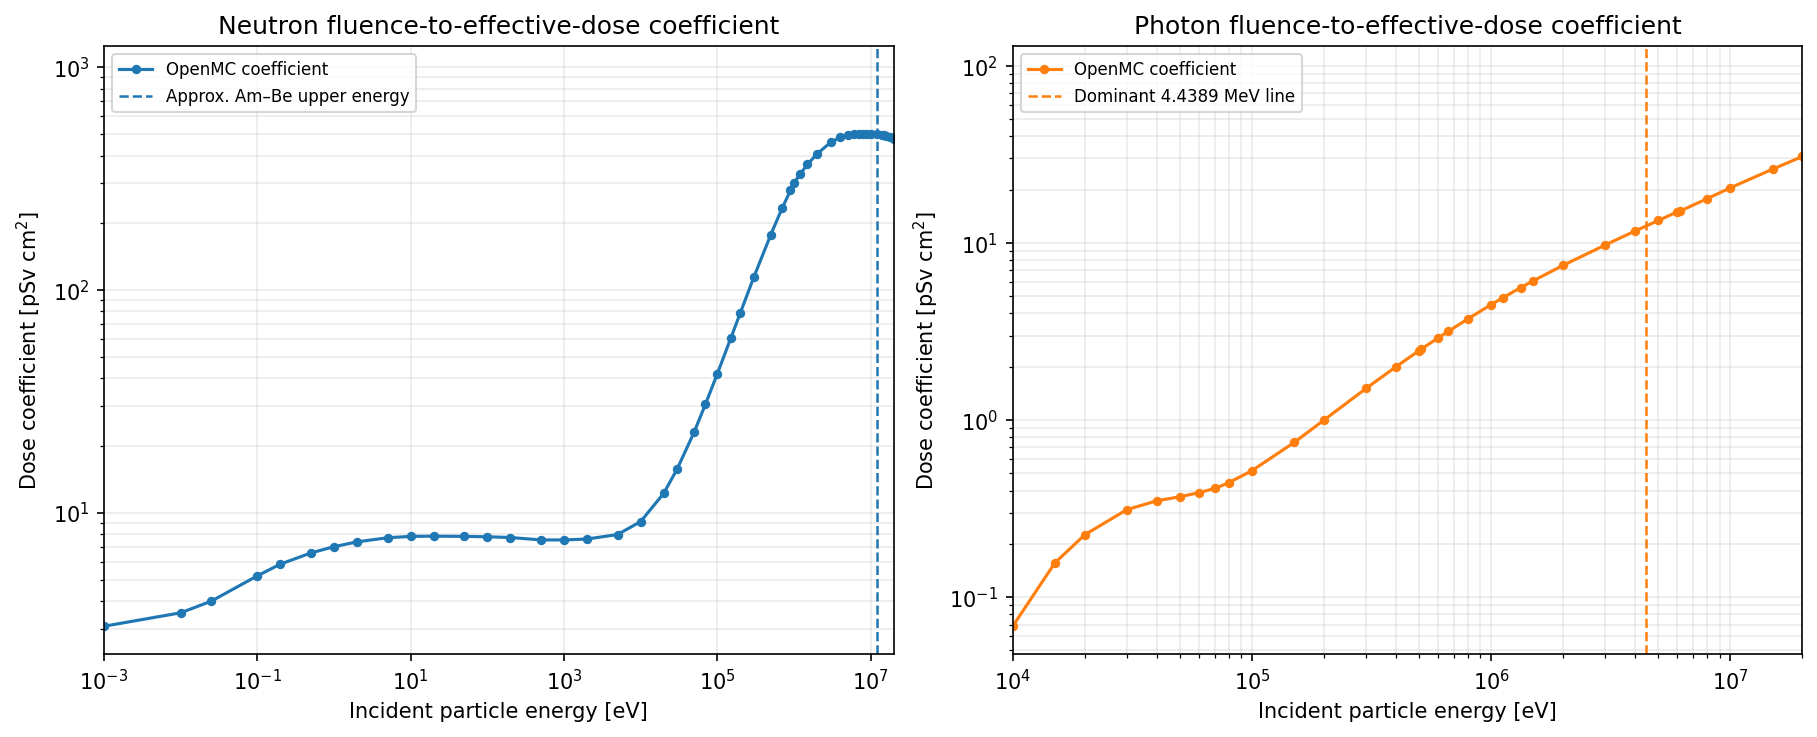

Saved figure: H2_hollow_cabinet_unified_outputs/figures/section_4_dose_conversion_coefficients.png


In [7]:
AMBE_NEUTRON_MAX_ENERGY_EV = 12.0e6
AMBE_GAMMA_LINE_ENERGY_EV = 4.4389e6

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.0, 4.8),
    dpi=150,
    layout="constrained",
)

coefficient_plot_settings = [
    {
        "ax": axes[0],
        "energies": neutron_dose_energies,
        "coefficients": neutron_dose_coefficients,
        "color": "tab:blue",
        "title": "Neutron fluence-to-effective-dose coefficient",
        "reference_energy": AMBE_NEUTRON_MAX_ENERGY_EV,
        "reference_label": "Approx. Am–Be upper energy",
        "x_limits": (1.0e-3, 2.0e7),
    },
    {
        "ax": axes[1],
        "energies": photon_dose_energies,
        "coefficients": photon_dose_coefficients,
        "color": "tab:orange",
        "title": "Photon fluence-to-effective-dose coefficient",
        "reference_energy": AMBE_GAMMA_LINE_ENERGY_EV,
        "reference_label": "Dominant 4.4389 MeV line",
        "x_limits": (1.0e4, 2.0e7),
    },
]

for settings_dict in coefficient_plot_settings:
    ax = settings_dict["ax"]
    energies = settings_dict["energies"]
    coefficients = settings_dict["coefficients"]

    positive = (
        np.isfinite(energies)
        & np.isfinite(coefficients)
        & (energies > 0.0)
        & (coefficients > 0.0)
    )

    ax.loglog(
        energies[positive],
        coefficients[positive],
        marker="o",
        markersize=3.5,
        linewidth=1.5,
        color=settings_dict["color"],
        label="OpenMC coefficient",
    )

    ax.axvline(
        settings_dict["reference_energy"],
        color=settings_dict["color"],
        linestyle="--",
        linewidth=1.2,
        label=settings_dict["reference_label"],
    )

    ax.set_xlim(*settings_dict["x_limits"])
    ax.set_xlabel("Incident particle energy [eV]")
    ax.set_ylabel(r"Dose coefficient [pSv cm$^2$]")
    ax.set_title(settings_dict["title"])
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=8)

coefficient_figure_path = (
    FIGURE_DIR / "section_4_dose_conversion_coefficients.png"
)

fig.savefig(
    coefficient_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved figure: {coefficient_figure_path}")


# 5) Build the common-cube flux and dose-rate models

Each model contains two tallies per point in the same one-cell cubic mesh: an
unweighted particle-flux tally and an energy-weighted dose tally. OpenMC source
strengths remain equal to one emitted source particle; physical source rates
are applied only during post-processing.

The neutron production retains its $200\times100000=2.0\times10^7$
source-neutron configuration. The new gamma production uses the photon
weight-window map generated independently in Notebook 1H gamma workflow. Every gamma dose and
common-flux tally has a 50% relative-error trigger. The configured batch count
is therefore a minimum rather than a fixed total.


In [8]:
def make_dose_mesh_tally(
    name,
    center,
    detector_side_cm,
    particle,
    dose_filter,
):
    """Create a one-cell mesh tally weighted by a dose coefficient."""

    x_cm, y_cm, z_cm = center
    half_side_cm = detector_side_cm / 2.0

    mesh = openmc.RegularMesh()
    mesh.dimension = (1, 1, 1)
    mesh.lower_left = (
        x_cm - half_side_cm,
        y_cm - half_side_cm,
        z_cm - half_side_cm,
    )
    mesh.upper_right = (
        x_cm + half_side_cm,
        y_cm + half_side_cm,
        z_cm + half_side_cm,
    )

    tally = openmc.Tally(name=name)
    tally.filters = [
        openmc.MeshFilter(mesh),
        openmc.ParticleFilter([particle]),
        dose_filter,
    ]
    tally.scores = ["flux"]

    return tally


def make_common_flux_mesh_tally(name, center, detector_side_cm, particle):
    """Create an unweighted one-cell flux tally in the common cube."""

    x_cm, y_cm, z_cm = center
    half_side_cm = detector_side_cm / 2.0
    mesh = openmc.RegularMesh()
    mesh.dimension = (1, 1, 1)
    mesh.lower_left = tuple(v - half_side_cm for v in (x_cm, y_cm, z_cm))
    mesh.upper_right = tuple(v + half_side_cm for v in (x_cm, y_cm, z_cm))

    tally = openmc.Tally(name=name)
    tally.filters = [
        openmc.MeshFilter(mesh),
        openmc.ParticleFilter([particle]),
    ]
    tally.scores = ["flux"]
    return tally


neutron_dose_tally_list = []
gamma_dose_tally_list = []
common_neutron_flux_tally_list = []
common_gamma_flux_tally_list = []

for point_name, point_data in DOSE_SCAN_POINTS.items():
    neutron_dose_tally_list.append(
        make_dose_mesh_tally(
            name=f"neutron_dose_{point_name}",
            center=point_data["center"],
            detector_side_cm=DOSE_SCAN_DET_SIZE,
            particle="neutron",
            dose_filter=neutron_dose_filter,
        )
    )

    gamma_dose_tally_list.append(
        make_dose_mesh_tally(
            name=f"gamma_dose_{point_name}",
            center=point_data["center"],
            detector_side_cm=DOSE_SCAN_DET_SIZE,
            particle="photon",
            dose_filter=photon_dose_filter,
        )
    )

    common_neutron_flux_tally_list.append(
        make_common_flux_mesh_tally(
            name=f"common_neutron_flux_{point_name}",
            center=point_data["center"],
            detector_side_cm=DOSE_SCAN_DET_SIZE,
            particle="neutron",
        )
    )
    common_gamma_flux_tally_list.append(
        make_common_flux_mesh_tally(
            name=f"common_gamma_flux_{point_name}",
            center=point_data["center"],
            detector_side_cm=DOSE_SCAN_DET_SIZE,
            particle="photon",
        )
    )


neutron_dose_tallies = openmc.Tallies(
    neutron_dose_tally_list + common_neutron_flux_tally_list
)
gamma_dose_tallies = openmc.Tallies(
    gamma_dose_tally_list + common_gamma_flux_tally_list
)

NEUTRON_DOSE_TALLY_NAMES = [
    tally.name for tally in neutron_dose_tally_list
]
GAMMA_DOSE_TALLY_NAMES = [
    tally.name for tally in gamma_dose_tally_list
]
COMMON_NEUTRON_FLUX_TALLY_NAMES = [
    tally.name for tally in common_neutron_flux_tally_list
]
COMMON_GAMMA_FLUX_TALLY_NAMES = [
    tally.name for tally in common_gamma_flux_tally_list
]
GAMMA_PRODUCTION_TALLY_NAMES = (
    GAMMA_DOSE_TALLY_NAMES + COMMON_GAMMA_FLUX_TALLY_NAMES
)

if len(NEUTRON_DOSE_TALLY_NAMES) != len(set(NEUTRON_DOSE_TALLY_NAMES)):
    raise ValueError("Neutron dose-tally names are not unique.")

if len(GAMMA_DOSE_TALLY_NAMES) != len(set(GAMMA_DOSE_TALLY_NAMES)):
    raise ValueError("Gamma dose-tally names are not unique.")


NEUTRON_DOSE_RUN_BATCHES = 200
NEUTRON_DOSE_RUN_PARTICLES = 100_000
NEUTRON_DOSE_RUN_SEED = 20260316

GAMMA_DOSE_TARGET_REL_ERR = 0.50
GAMMA_DOSE_MIN_BATCHES = 200
GAMMA_DOSE_MAX_BATCHES = 8_000
GAMMA_DOSE_PARTICLES_PER_BATCH = 25_000
GAMMA_DOSE_TRIGGER_BATCH_INTERVAL = 20
GAMMA_DOSE_RUN_SEED = 20262317


neutron_dose_settings = ambe_base_model.build_neutron_settings(
    energy_dist=neutron_energy_dist,
    batches=NEUTRON_DOSE_RUN_BATCHES,
    particles=NEUTRON_DOSE_RUN_PARTICLES,
    inactive=0,
    source_strength=1.0,
)
neutron_dose_settings.seed = NEUTRON_DOSE_RUN_SEED


def build_gamma_source(gamma_energy_distribution, source_strength=1.0):
    """Build an isotropic point photon source at the capsule centre."""

    source = openmc.IndependentSource(
        space=openmc.stats.Point((0.0, 0.0, 0.0)),
        angle=openmc.stats.Isotropic(),
        energy=gamma_energy_distribution,
        particle="photon",
    )
    source.strength = float(source_strength)
    return source


gamma_dose_settings = openmc.Settings()
gamma_dose_settings.run_mode = "fixed source"
gamma_dose_settings.source = build_gamma_source(
    gamma_energy_distribution=gamma_energy_dist,
    source_strength=1.0,
)
gamma_dose_settings.batches = GAMMA_DOSE_MIN_BATCHES
gamma_dose_settings.particles = GAMMA_DOSE_PARTICLES_PER_BATCH
gamma_dose_settings.inactive = 0
gamma_dose_settings.seed = GAMMA_DOSE_RUN_SEED
gamma_dose_settings.photon_transport = True
gamma_dose_settings.trigger_active = True
gamma_dose_settings.trigger_max_batches = GAMMA_DOSE_MAX_BATCHES
gamma_dose_settings.trigger_batch_interval = (
    GAMMA_DOSE_TRIGGER_BATCH_INTERVAL
)

for tally in gamma_dose_tallies:
    trigger = openmc.Trigger(
        trigger_type="rel_err",
        threshold=GAMMA_DOSE_TARGET_REL_ERR,
        ignore_zeros=False,
    )
    trigger.scores = ["flux"]
    tally.triggers = [trigger]


neutron_dose_model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=neutron_dose_settings,
    tallies=neutron_dose_tallies,
)

gamma_dose_model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=gamma_dose_settings,
    tallies=gamma_dose_tallies,
)


print("Dose-rate models created.")
print(f"Neutron tallies: {len(neutron_dose_tally_list)}")
print(f"Gamma tallies:   {len(gamma_dose_tally_list)}")
print(f"Common neutron-flux tallies: {len(common_neutron_flux_tally_list)}")
print(f"Common gamma-flux tallies:   {len(common_gamma_flux_tally_list)}")
print(
    "Configured source neutrons: "
    f"{NEUTRON_DOSE_RUN_BATCHES * NEUTRON_DOSE_RUN_PARTICLES:.3e}"
)
print(
    "Gamma source photons at minimum batches: "
    f"{GAMMA_DOSE_MIN_BATCHES * GAMMA_DOSE_PARTICLES_PER_BATCH:.3e}"
)
print(
    "Gamma source photons at maximum batches: "
    f"{GAMMA_DOSE_MAX_BATCHES * GAMMA_DOSE_PARTICLES_PER_BATCH:.3e}"
)
print(f"Gamma relative-error target: {100.0 * GAMMA_DOSE_TARGET_REL_ERR:.1f}%")


Dose-rate models created.
Neutron tallies: 61
Gamma tallies:   61
Common neutron-flux tallies: 61
Common gamma-flux tallies:   61
Configured source neutrons: 2.000e+07
Gamma source photons at minimum batches: 5.000e+06
Gamma source photons at maximum batches: 2.000e+08
Gamma relative-error target: 50.0%


# 6) Run the common-cube neutron and variance-reduced gamma models

These are new H2 statepoints; the H1 detector-specific flux statepoints cannot
replace them because the present tallies include energy-dependent AP-dose
conversion filters and co-located common-cube flux scores.

The first complete execution is configured with:

```python
RERUN_NEUTRON_DOSE = True
RUN_GAMMA_DOSE_PRODUCTION = True
ENFORCE_GAMMA_DOSE_TARGET = True
```

The neutron calculation is 200 batches × 100,000 source neutrons. The gamma
calculation reuses only H1's MAGIC spatial importance map, starts a statistically
independent production history, and stops when all 122 gamma dose/flux tallies
reach 50% relative uncertainty or the 8,000-batch ceiling is reached. After
both H2 statepoints pass their audits, set the two run flags to `False` to reuse
them on later notebook executions.


In [9]:
RERUN_NEUTRON_DOSE = True
RUN_GAMMA_DOSE_PRODUCTION = True
ENFORCE_GAMMA_DOSE_TARGET = True

NEUTRON_DOSE_RUN_DIR = (
    OPENMC_RUN_DIR / "neutron_common_cube_flux_and_ap_dose"
)
GAMMA_DOSE_RUN_DIR = (
    OPENMC_RUN_DIR / "gamma_common_cube_flux_and_ap_dose_ww"
)

DEFAULT_H1_WEIGHT_WINDOWS_PATH = (
    H1_OUTPUT_DIR / "gamma" / "openmc_runs"
    / "hollow_gamma_scan_lnd712_cellfilter_group_1_ww_generation"
    / "weight_windows.h5"
)
GROUP_1_WEIGHT_WINDOWS_PATH = find_first_existing_file(
    [
        H1_GROUP_1_WEIGHT_WINDOWS_PATH,
        DEFAULT_H1_WEIGHT_WINDOWS_PATH,
    ],
    "H1 hollow-cabinet photon weight-window file",
).resolve()

gamma_dose_settings.weight_window_checkpoints = {
    "collision": True,
    "surface": True,
}
gamma_dose_settings.survival_biasing = False
gamma_dose_settings.weight_windows_file = GROUP_1_WEIGHT_WINDOWS_PATH
gamma_dose_settings.weight_windows_on = True
gamma_dose_model.settings = gamma_dose_settings


def statepoint_batch_number(path):
    match = re.search(r"statepoint\.(\d+)\.h5$", Path(path).name)
    return int(match.group(1)) if match else -1


def normalize_run_statepoint(run_result, run_directory):
    """Resolve the statepoint path returned by openmc.Model.run."""

    statepoint_path = Path(run_result)

    if not statepoint_path.is_absolute() and not statepoint_path.exists():
        candidate = Path(run_directory) / statepoint_path
        if candidate.exists():
            statepoint_path = candidate

    return statepoint_path.resolve()


def run_model_and_resolve_statepoint(model, run_directory, label):
    run_directory = Path(run_directory)
    run_directory.mkdir(parents=True, exist_ok=True)
    model.export_to_xml(directory=run_directory)

    print(f"Running {label} simulation in {run_directory.resolve()} ...")
    run_result = model.run(cwd=run_directory)
    statepoint_path = normalize_run_statepoint(
        run_result=run_result,
        run_directory=run_directory,
    )

    if not statepoint_path.exists():
        raise FileNotFoundError(
            f"OpenMC did not produce the expected statepoint: {statepoint_path}"
        )

    return statepoint_path


def find_latest_statepoint(run_directory):
    candidates = list(Path(run_directory).glob("statepoint.*.h5"))
    if not candidates:
        raise FileNotFoundError(
            f"No statepoint was found in '{run_directory}'."
        )
    return max(
        candidates,
        key=lambda path: path.stat().st_mtime_ns,
    ).resolve()


def run_or_reuse_statepoint(
    model,
    run_directory,
    batches,
    rerun,
    label,
):
    """Run a model or reuse the exact statepoint for its batch count."""

    run_directory = Path(run_directory)
    expected_statepoint = run_directory / f"statepoint.{batches}.h5"

    if rerun:
        return run_model_and_resolve_statepoint(
            model=model,
            run_directory=run_directory,
            label=label,
        )

    if expected_statepoint.exists():
        print(f"Reusing {label} statepoint: {expected_statepoint}")
        return expected_statepoint

    available_statepoints = sorted(run_directory.glob("statepoint.*.h5"))
    available_text = (
        ", ".join(str(path) for path in available_statepoints)
        if available_statepoints
        else "none"
    )

    raise FileNotFoundError(
        f"Expected {label} statepoint {expected_statepoint} was not found. "
        f"Available statepoints: {available_text}. Set the corresponding "
        "RERUN flag to True to run the configured model."
    )


sp_path_neutron_dose = run_or_reuse_statepoint(
    model=neutron_dose_model,
    run_directory=NEUTRON_DOSE_RUN_DIR,
    batches=NEUTRON_DOSE_RUN_BATCHES,
    rerun=RERUN_NEUTRON_DOSE,
    label="neutron dose-rate",
)

if RUN_GAMMA_DOSE_PRODUCTION:
    sp_path_gamma_dose = run_model_and_resolve_statepoint(
        model=gamma_dose_model,
        run_directory=GAMMA_DOSE_RUN_DIR,
        label="variance-reduced gamma dose-rate",
    )
else:
    sp_path_gamma_dose = find_latest_statepoint(GAMMA_DOSE_RUN_DIR)
    print(
        "Reusing variance-reduced gamma dose-rate statepoint: "
        f"{sp_path_gamma_dose}"
    )


def audit_relative_errors(statepoint_path, tally_names, target_rel_err):
    """Return one row per scalar tally and its statepoint relative error."""

    audit_rows = []

    with openmc.StatePoint(statepoint_path) as statepoint:
        available_tallies = {
            tally.name for tally in statepoint.tallies.values()
        }
        missing_tallies = sorted(set(tally_names) - available_tallies)
        if missing_tallies:
            raise KeyError(
                "Gamma-dose statepoint lacks expected tallies: "
                + ", ".join(missing_tallies[:10])
            )

        for tally_name in tally_names:
            tally = statepoint.get_tally(name=tally_name)
            mean = np.asarray(tally.mean, dtype=float).ravel()
            std_dev = np.asarray(tally.std_dev, dtype=float).ravel()

            if mean.size != 1 or std_dev.size != 1:
                raise ValueError(
                    f"Trigger-audit tally '{tally_name}' is not scalar."
                )

            mean_value = float(mean[0])
            std_dev_value = float(std_dev[0])
            if mean_value == 0.0 or not np.isfinite(mean_value):
                relative_error = np.inf
            else:
                relative_error = abs(std_dev_value / mean_value)

            audit_rows.append({
                "tally_name": tally_name,
                "mean_per_source": mean_value,
                "std_dev_per_source": std_dev_value,
                "relative_error": relative_error,
                "relative_error_percent": 100.0 * relative_error,
                "target_reached": (
                    np.isfinite(relative_error)
                    and relative_error <= target_rel_err
                ),
            })

    return pd.DataFrame(audit_rows)


GAMMA_DOSE_TRIGGER_AUDIT_DF = audit_relative_errors(
    statepoint_path=sp_path_gamma_dose,
    tally_names=GAMMA_PRODUCTION_TALLY_NAMES,
    target_rel_err=GAMMA_DOSE_TARGET_REL_ERR,
)

GAMMA_DOSE_PRODUCTION_BATCHES_COMPLETED = statepoint_batch_number(
    sp_path_gamma_dose
)
GAMMA_DOSE_MAX_RELATIVE_ERROR_PERCENT = float(
    GAMMA_DOSE_TRIGGER_AUDIT_DF["relative_error_percent"].max()
)
GAMMA_DOSE_TARGET_REACHED = bool(
    GAMMA_DOSE_TRIGGER_AUDIT_DF["target_reached"].all()
)

print()
print("Gamma-dose production audit:")
print(f"  Completed batches: {GAMMA_DOSE_PRODUCTION_BATCHES_COMPLETED}")
print(
    "  Maximum relative uncertainty: "
    f"{GAMMA_DOSE_MAX_RELATIVE_ERROR_PERCENT:.3f}%"
)
print(f"  All 122 dose/flux tallies reached target: {GAMMA_DOSE_TARGET_REACHED}")

display(
    GAMMA_DOSE_TRIGGER_AUDIT_DF.sort_values(
        "relative_error_percent",
        ascending=False,
    ).head(10)
)

if ENFORCE_GAMMA_DOSE_TARGET and not GAMMA_DOSE_TARGET_REACHED:
    raise RuntimeError(
        "The gamma-dose run reached its maximum allowed batches before "
        f"all 122 dose/flux tallies met the {100.0 * GAMMA_DOSE_TARGET_REL_ERR:.1f}% "
        "target. Increase GAMMA_DOSE_MAX_BATCHES and rerun only the gamma "
        "dose production; the neutron-dose statepoint remains reusable."
    )


Found H1 hollow-cabinet photon weight-window file: H1_f1_sides_and_front_f2_hollow_transport_outputs/gamma/openmc_runs/hollow_gamma_scan_lnd712_cellfilter_group_1_ww_generation/weight_windows.h5
Running neutron dose-rate simulation in /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H2_hollow_cabinet_unified_outputs/openmc_runs/neutron_common_cube_flux_and_ap_dose ...


/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=4.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/openmc_venv/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=6.
  warn(msg, IDWarning)


Running variance-reduced gamma dose-rate simulation in /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/H2_hollow_cabinet_unified_outputs/openmc_runs/gamma_common_cube_flux_and_ap_dose_ww ...
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ##########

,tally_name,mean_per_source,std_dev_per_source,relative_error,relative_error_percent,target_reached
51,gamma_dose_P3_x400_h85,5.722038e-07,2.856297e-07,0.499175,49.917479,True
112,common_gamma_flux_P3_x400_h85,1.114928e-07,4.232750e-08,0.379643,37.964349,True
40,gamma_dose_P3_x225_h45,1.201592e-06,4.341256e-07,0.361292,36.129210,True
41,gamma_dose_P3_x300_h45,1.215596e-06,4.337429e-07,0.356815,35.681505,True
39,gamma_dose_P3_x199_h45,1.509440e-06,5.109656e-07,0.338513,33.851349,True
23,gamma_dose_P2_x420_h55,1.051290e-06,3.536561e-07,0.336402,33.640218,True
102,common_gamma_flux_P3_x300_h45,1.517121e-07,4.848673e-08,0.319597,31.959691,True
49,gamma_dose_P3_x225_h85,1.099164e-06,3.444760e-07,0.313398,31.339812,True
38,gamma_dose_P3_x176_h45,1.806845e-06,5.413781e-07,0.299626,29.962626,True
50,gamma_dose_P3_x300_h85,1.769748e-06,5.258999e-07,0.297161,29.716084,True


# 7) Post-process the neutron and gamma dose tallies

The mesh tally is divided by its $8\ \mathrm{cm^3}$ averaging volume, scaled by
the relevant physical emission rate, and converted from
$\mathrm{pSv\,s^{-1}}$ to $\mu\mathrm{Sv\,h^{-1}}$.

The new photon statepoint has passed Notebook 2H's mandatory 50% audit for all
122 gamma dose and common-flux tallies. The neutron statepoint retains the
precision produced by its fixed-history calculation.

The uncertainty classes remain stricter than the production stop criterion:

- low: $u_{\mathrm{rel,MC}}<5\%$;
- moderate: $5\%\leq u_{\mathrm{rel,MC}}<10\%$;
- high: $10\%\leq u_{\mathrm{rel,MC}}<25\%$;
- very high: $u_{\mathrm{rel,MC}}\geq25\%$.

Thus, a tally may satisfy the 50% production criterion and still be classified
as having very high uncertainty. Such points are retained for traceability and
should be interpreted as approximate magnitudes rather than precise local
variations.


In [10]:
def get_scalar_tally_mean_std(statepoint, tally_name):
    """Return a scalar tally mean and OpenMC batch standard deviation."""

    tally = statepoint.get_tally(name=tally_name)
    mean = np.asarray(tally.mean, dtype=float).flatten()
    standard_deviation = np.asarray(
        tally.std_dev,
        dtype=float,
    ).flatten()

    if mean.size != 1 or standard_deviation.size != 1:
        raise ValueError(
            f"Tally '{tally_name}' is not scalar. "
            f"Mean size: {mean.size}; standard-deviation size: "
            f"{standard_deviation.size}."
        )

    return float(mean[0]), float(standard_deviation[0])


def postprocess_dose_tallies(
    statepoint_path,
    scan_points,
    tally_prefix,
    expected_tally_names,
    source_strength,
    particle_label,
):
    """Convert energy-weighted mesh tallies to physical dose rates."""

    rows = []

    with openmc.StatePoint(statepoint_path) as statepoint:
        available_tally_names = {
            tally.name for tally in statepoint.tallies.values()
        }

        missing_tallies = sorted(
            set(expected_tally_names) - available_tally_names
        )

        if missing_tallies:
            raise LookupError(
                f"Statepoint {statepoint_path} does not contain all expected "
                f"{particle_label} dose tallies. First missing tallies: "
                + ", ".join(missing_tallies[:5])
            )

        for point_name, point_data in scan_points.items():
            tally_name = f"{tally_prefix}_{point_name}"
            mean_raw, u_mc_raw = get_scalar_tally_mean_std(
                statepoint,
                tally_name,
            )

            dose_per_source_pSv = (
                mean_raw / DOSE_SCAN_DET_VOLUME
            )
            u_mc_per_source_pSv = (
                u_mc_raw / DOSE_SCAN_DET_VOLUME
            )

            dose_rate_uSv_h = (
                dose_per_source_pSv
                * source_strength
                * PSV_PER_S_TO_USV_PER_H
            )
            u_mc_dose_rate_uSv_h = (
                u_mc_per_source_pSv
                * source_strength
                * PSV_PER_S_TO_USV_PER_H
            )

            if dose_rate_uSv_h > 0.0:
                rel_u_mc_percent = (
                    100.0
                    * u_mc_dose_rate_uSv_h
                    / dose_rate_uSv_h
                )
            else:
                rel_u_mc_percent = np.nan

            x_cm, y_cm, z_cm = point_data["center"]

            rows.append({
                "position": point_data["position"],
                "point_name": point_name,
                "distance_cm": point_data["distance_cm"],
                "height_cm": point_data["height_cm"],
                "common_dose_x_cm": x_cm,
                "common_dose_y_cm": y_cm,
                "common_dose_z_cm": z_cm,
                "tally_name": tally_name,
                "detector_volume_cm3": DOSE_SCAN_DET_VOLUME,
                f"{particle_label}_dose_per_source [pSv/source]": (
                    dose_per_source_pSv
                ),
                f"u_mc_{particle_label}_dose_per_source [pSv/source]": (
                    u_mc_per_source_pSv
                ),
                f"{particle_label}_dose_rate [uSv/h]": (
                    dose_rate_uSv_h
                ),
                f"u_mc_{particle_label}_dose_rate [uSv/h]": (
                    u_mc_dose_rate_uSv_h
                ),
                f"rel_u_mc_{particle_label}_dose_rate [%]": (
                    rel_u_mc_percent
                ),
                f"{particle_label}_dose_mc_uncertainty_class": (
                    classify_relative_mc_uncertainty(
                        rel_u_mc_percent
                    )
                ),
            })

    dataframe = pd.DataFrame(rows)
    dataframe = dataframe.sort_values(
        ["position", "height_cm", "distance_cm"]
    ).reset_index(drop=True)

    return dataframe


def postprocess_common_flux_tallies(
    statepoint_path,
    scan_points,
    tally_prefix,
    expected_tally_names,
    source_strength,
    particle_label,
    flux_unit,
):
    """Convert common-cube track-length tallies to physical flux."""

    rows = []
    with openmc.StatePoint(statepoint_path) as statepoint:
        available = {tally.name for tally in statepoint.tallies.values()}
        missing = sorted(set(expected_tally_names) - available)
        if missing:
            raise LookupError(
                f"Statepoint {statepoint_path} lacks common {particle_label} "
                "flux tallies: " + ", ".join(missing[:5])
            )

        for point_name, point_data in scan_points.items():
            tally_name = f"{tally_prefix}_{point_name}"
            mean_raw, u_raw = get_scalar_tally_mean_std(statepoint, tally_name)
            flux = mean_raw / DOSE_SCAN_DET_VOLUME * source_strength
            u_flux = u_raw / DOSE_SCAN_DET_VOLUME * source_strength
            rel_u = 100.0 * u_flux / flux if flux > 0.0 else np.nan
            x_cm, y_cm, z_cm = point_data["center"]
            rows.append({
                "point_name": point_name,
                "common_flux_x_cm": x_cm,
                "common_flux_y_cm": y_cm,
                "common_flux_z_cm": z_cm,
                "common_flux_tally_volume_cm3": DOSE_SCAN_DET_VOLUME,
                f"common_{particle_label}_flux [{flux_unit}]": flux,
                f"u_mc_common_{particle_label}_flux [{flux_unit}]": u_flux,
                f"rel_u_mc_common_{particle_label}_flux [%]": rel_u,
            })
    return pd.DataFrame(rows)


neutron_dose_df = postprocess_dose_tallies(
    statepoint_path=sp_path_neutron_dose,
    scan_points=DOSE_SCAN_POINTS,
    tally_prefix="neutron_dose",
    expected_tally_names=NEUTRON_DOSE_TALLY_NAMES,
    source_strength=SOURCE_NEUTRON_EMISSION,
    particle_label="neutron",
)

gamma_dose_df = postprocess_dose_tallies(
    statepoint_path=sp_path_gamma_dose,
    scan_points=DOSE_SCAN_POINTS,
    tally_prefix="gamma_dose",
    expected_tally_names=GAMMA_DOSE_TALLY_NAMES,
    source_strength=GAMMA_SOURCE_EMISSION,
    particle_label="gamma",
)

common_neutron_flux_df = postprocess_common_flux_tallies(
    statepoint_path=sp_path_neutron_dose,
    scan_points=DOSE_SCAN_POINTS,
    tally_prefix="common_neutron_flux",
    expected_tally_names=COMMON_NEUTRON_FLUX_TALLY_NAMES,
    source_strength=SOURCE_NEUTRON_EMISSION,
    particle_label="neutron",
    flux_unit="n/cm2/s",
)

common_gamma_flux_df = postprocess_common_flux_tallies(
    statepoint_path=sp_path_gamma_dose,
    scan_points=DOSE_SCAN_POINTS,
    tally_prefix="common_gamma_flux",
    expected_tally_names=COMMON_GAMMA_FLUX_TALLY_NAMES,
    source_strength=GAMMA_SOURCE_EMISSION,
    particle_label="gamma",
    flux_unit="photon/cm2/s",
)


print("Dose-rate post-processing complete.")
print(f"Neutron points: {len(neutron_dose_df)}")
print(f"Gamma points:   {len(gamma_dose_df)}")
print(f"Common neutron-flux points: {len(common_neutron_flux_df)}")
print(f"Common gamma-flux points:   {len(common_gamma_flux_df)}")

display(
    neutron_dose_df
    .groupby(["position", "neutron_dose_mc_uncertainty_class"])
    .size()
    .rename("count")
    .reset_index()
)

display(
    gamma_dose_df
    .groupby(["position", "gamma_dose_mc_uncertainty_class"])
    .size()
    .rename("count")
    .reset_index()
)


Dose-rate post-processing complete.
Neutron points: 61
Gamma points:   61
Common neutron-flux points: 61
Common gamma-flux points:   61


,position,neutron_dose_mc_uncertainty_class,count
0,P1,high,6
1,P1,low,2
2,P1,moderate,5
3,P1,very high,4
4,P2,high,7
5,P2,moderate,4
6,P2,very high,6
7,P3,high,7
8,P3,low,2
9,P3,moderate,2


,position,gamma_dose_mc_uncertainty_class,count
0,P1,high,4
1,P1,low,7
2,P1,moderate,6
3,P2,high,9
4,P2,moderate,6
5,P2,very high,2
6,P3,high,6
7,P3,moderate,4
8,P3,very high,8
9,P4,high,5


# 8) Merge flux and dose results

All four component tables are merged one-to-one by `point_name`. The final
table keeps the detector-specific `neutron_flux_*` and `gamma_flux_*` results
separate from the new `common_*_flux` results. Only the latter are co-located
and volume matched, so only they are used for the gamma-to-neutron flux ratio.

Only the two dose-rate components evaluated in the identical common cubes are
added:

$$
\dot H_{\mathrm{tot}}=\dot H_n+\dot H_\gamma.
$$

The total MC standard uncertainty is propagated from the independent neutron
and gamma transport runs as

$$
u_{\mathrm{MC}}(\dot H_{\mathrm{tot}})
=
\sqrt{
u_{\mathrm{MC}}^2(\dot H_n)
+
u_{\mathrm{MC}}^2(\dot H_\gamma)
}.
$$

This independence assumption applies to the Monte Carlo estimators. It does not
turn the result into a complete physical simulation-uncertainty budget.


In [11]:
neutron_dose_keep = neutron_dose_df[
    [
        "point_name",
        "common_dose_x_cm",
        "common_dose_y_cm",
        "common_dose_z_cm",
        "neutron_dose_per_source [pSv/source]",
        "u_mc_neutron_dose_per_source [pSv/source]",
        "neutron_dose_rate [uSv/h]",
        "u_mc_neutron_dose_rate [uSv/h]",
        "rel_u_mc_neutron_dose_rate [%]",
        "neutron_dose_mc_uncertainty_class",
    ]
].copy()

gamma_dose_keep = gamma_dose_df[
    [
        "point_name",
        "gamma_dose_per_source [pSv/source]",
        "u_mc_gamma_dose_per_source [pSv/source]",
        "gamma_dose_rate [uSv/h]",
        "u_mc_gamma_dose_rate [uSv/h]",
        "rel_u_mc_gamma_dose_rate [%]",
        "gamma_dose_mc_uncertainty_class",
    ]
].copy()

gamma_flux_keep = gamma_flux_df[
    [
        "point_name",
        "gamma_flux_x_cm",
        "gamma_flux_y_cm",
        "gamma_flux_z_cm",
        "gamma_flux_tally_volume_cm3",
        "gamma_flux [photon/cm2/s]",
        "u_mc_gamma_flux [photon/cm2/s]",
        "rel_u_mc_gamma_flux [%]",
    ]
].copy()


unified_df = neutron_flux_df.merge(
    gamma_flux_keep,
    on="point_name",
    how="inner",
    validate="one_to_one",
)

unified_df = unified_df.merge(
    neutron_dose_keep,
    on="point_name",
    how="inner",
    validate="one_to_one",
)

unified_df = unified_df.merge(
    gamma_dose_keep,
    on="point_name",
    how="inner",
    validate="one_to_one",
)

unified_df = unified_df.merge(
    common_neutron_flux_df,
    on="point_name",
    how="inner",
    validate="one_to_one",
)

common_gamma_flux_keep = common_gamma_flux_df.drop(
    columns=[
        "common_flux_x_cm",
        "common_flux_y_cm",
        "common_flux_z_cm",
        "common_flux_tally_volume_cm3",
    ]
)
unified_df = unified_df.merge(
    common_gamma_flux_keep,
    on="point_name",
    how="inner",
    validate="one_to_one",
)

unified_df = unified_df.sort_values(
    ["position", "height_cm", "distance_cm"]
).reset_index(drop=True)

if len(unified_df) != 61:
    raise ValueError(
        "The unified table must contain 61 points; "
        f"found {len(unified_df)}."
    )


# Explicit coordinate aliases retained for the later comparison notebook.
# They always mean the common dose-reference cube, never the LND 712 centre.
unified_df["x_cm"] = unified_df["common_dose_x_cm"]
unified_df["y_cm"] = unified_df["common_dose_y_cm"]
unified_df["z_cm"] = unified_df["common_dose_z_cm"]

for axis in ["x", "y", "z"]:
    common_vs_neutron = np.abs(
        unified_df[f"common_dose_{axis}_cm"].astype(float)
        - unified_df[f"neutron_flux_{axis}_cm"].astype(float)
    )
    if np.nanmax(common_vs_neutron) > 1.0e-12:
        raise ValueError(
            "Common dose coordinates must equal the Notebook 1H neutron "
            f"coordinates; mismatch found in {axis}."
        )

unified_df["flux_centre_separation_cm"] = np.sqrt(
    sum(
        (
            unified_df[f"gamma_flux_{axis}_cm"].astype(float)
            - unified_df[f"neutron_flux_{axis}_cm"].astype(float)
        )**2
        for axis in ["x", "y", "z"]
    )
)


# ------------------------------------------------------------
# Total dose rate and MC uncertainty
# ------------------------------------------------------------

unified_df["total_dose_rate [uSv/h]"] = (
    unified_df["neutron_dose_rate [uSv/h]"]
    + unified_df["gamma_dose_rate [uSv/h]"]
)

unified_df["u_mc_total_dose_rate [uSv/h]"] = np.sqrt(
    unified_df["u_mc_neutron_dose_rate [uSv/h]"]**2
    + unified_df["u_mc_gamma_dose_rate [uSv/h]"]**2
)

unified_df["rel_u_mc_total_dose_rate [%]"] = np.where(
    unified_df["total_dose_rate [uSv/h]"] > 0.0,
    100.0
    * unified_df["u_mc_total_dose_rate [uSv/h]"]
    / unified_df["total_dose_rate [uSv/h]"],
    np.nan,
)

unified_df["total_dose_mc_uncertainty_class"] = pd.Categorical(
    unified_df["rel_u_mc_total_dose_rate [%]"].apply(
        classify_relative_mc_uncertainty
    ),
    categories=MC_UNCERTAINTY_ORDER,
    ordered=True,
)


# Compatibility aliases retained for the later comparison notebook.
# The u_mc_* columns above are the authoritative current names.
unified_df["neutron_dose_rate_std [uSv/h]"] = (
    unified_df["u_mc_neutron_dose_rate [uSv/h]"]
)
unified_df["gamma_dose_rate_std [uSv/h]"] = (
    unified_df["u_mc_gamma_dose_rate [uSv/h]"]
)
unified_df["total_dose_rate_std [uSv/h]"] = (
    unified_df["u_mc_total_dose_rate [uSv/h]"]
)
unified_df["neutron_dose_rel_unc [%]"] = (
    unified_df["rel_u_mc_neutron_dose_rate [%]"]
)
unified_df["gamma_dose_rel_unc [%]"] = (
    unified_df["rel_u_mc_gamma_dose_rate [%]"]
)
unified_df["total_dose_rel_unc [%]"] = (
    unified_df["rel_u_mc_total_dose_rate [%]"]
)
unified_df["neutron_flux_std [n/cm2/s]"] = (
    unified_df["u_mc_neutron_flux [n/cm2/s]"]
)
unified_df["gamma_flux_std [photon/cm2/s]"] = (
    unified_df["u_mc_gamma_flux [photon/cm2/s]"]
)
unified_df["neutron_flux_rel_unc [%]"] = (
    unified_df["rel_u_mc_neutron_flux [%]"]
)
unified_df["gamma_flux_rel_unc [%]"] = (
    unified_df["rel_u_mc_gamma_flux [%]"]
)


# ------------------------------------------------------------
# Ratios and dose fractions
# ------------------------------------------------------------

common_neutron_flux = unified_df[
    "common_neutron_flux [n/cm2/s]"
].to_numpy(dtype=float)
common_gamma_flux = unified_df[
    "common_gamma_flux [photon/cm2/s]"
].to_numpy(dtype=float)
u_common_neutron_flux = unified_df[
    "u_mc_common_neutron_flux [n/cm2/s]"
].to_numpy(dtype=float)
u_common_gamma_flux = unified_df[
    "u_mc_common_gamma_flux [photon/cm2/s]"
].to_numpy(dtype=float)

unified_df["common_gamma_to_neutron_flux_ratio"] = np.divide(
    common_gamma_flux,
    common_neutron_flux,
    out=np.full(len(unified_df), np.nan),
    where=common_neutron_flux > 0.0,
)
unified_df["common_total_particle_flux [particles/cm2/s]"] = (
    common_neutron_flux + common_gamma_flux
)
unified_df["u_mc_common_total_particle_flux [particles/cm2/s]"] = np.sqrt(
    u_common_neutron_flux**2 + u_common_gamma_flux**2
)

valid_flux_ratio = (common_neutron_flux > 0.0) & (common_gamma_flux > 0.0)
flux_ratio_relative_variance = np.divide(
    u_common_gamma_flux,
    common_gamma_flux,
    out=np.full(len(unified_df), np.nan),
    where=common_gamma_flux > 0.0,
)**2 + np.divide(
    u_common_neutron_flux,
    common_neutron_flux,
    out=np.full(len(unified_df), np.nan),
    where=common_neutron_flux > 0.0,
)**2
unified_df["u_mc_common_gamma_to_neutron_flux_ratio"] = np.where(
    valid_flux_ratio,
    unified_df["common_gamma_to_neutron_flux_ratio"]
    * np.sqrt(flux_ratio_relative_variance),
    np.nan,
)

neutron_rate = unified_df["neutron_dose_rate [uSv/h]"].to_numpy(dtype=float)
gamma_rate = unified_df["gamma_dose_rate [uSv/h]"].to_numpy(dtype=float)
total_rate = unified_df["total_dose_rate [uSv/h]"].to_numpy(dtype=float)

unified_df["gamma_to_neutron_dose_ratio"] = np.divide(
    gamma_rate,
    neutron_rate,
    out=np.full(len(unified_df), np.nan, dtype=float),
    where=neutron_rate > 0.0,
)

unified_df["neutron_dose_fraction"] = np.divide(
    neutron_rate,
    total_rate,
    out=np.full(len(unified_df), np.nan, dtype=float),
    where=total_rate > 0.0,
)

unified_df["gamma_dose_fraction"] = np.divide(
    gamma_rate,
    total_rate,
    out=np.full(len(unified_df), np.nan, dtype=float),
    where=total_rate > 0.0,
)


# MC uncertainty of gamma/neutron dose ratio for independent tallies.
u_neutron_rate = unified_df[
    "u_mc_neutron_dose_rate [uSv/h]"
].to_numpy(dtype=float)
u_gamma_rate = unified_df[
    "u_mc_gamma_dose_rate [uSv/h]"
].to_numpy(dtype=float)

valid_ratio = (neutron_rate > 0.0) & (gamma_rate > 0.0)

relative_u_gamma = np.divide(
    u_gamma_rate,
    gamma_rate,
    out=np.full(len(unified_df), np.nan, dtype=float),
    where=gamma_rate > 0.0,
)
relative_u_neutron = np.divide(
    u_neutron_rate,
    neutron_rate,
    out=np.full(len(unified_df), np.nan, dtype=float),
    where=neutron_rate > 0.0,
)

relative_ratio_variance = (
    relative_u_gamma**2 + relative_u_neutron**2
)

unified_df["u_mc_gamma_to_neutron_dose_ratio"] = np.where(
    valid_ratio,
    unified_df["gamma_to_neutron_dose_ratio"].to_numpy(dtype=float)
    * np.sqrt(relative_ratio_variance),
    np.nan,
)


# MC uncertainty of either two-component fraction.
inverse_total_squared = np.divide(
    1.0,
    total_rate**2,
    out=np.zeros(len(unified_df), dtype=float),
    where=total_rate > 0.0,
)

fraction_variance = (
    (gamma_rate * inverse_total_squared)**2 * u_neutron_rate**2
    + (neutron_rate * inverse_total_squared)**2 * u_gamma_rate**2
)

unified_df["u_mc_neutron_dose_fraction"] = np.where(
    total_rate > 0.0,
    np.sqrt(fraction_variance),
    np.nan,
)

unified_df["u_mc_gamma_dose_fraction"] = (
    unified_df["u_mc_neutron_dose_fraction"]
)


unique_heights = np.sort(unified_df["height_cm"].dropna().unique())
if unique_heights.size < 2:
    raise ValueError("At least two unique heights are required for grouping.")
height_gaps = np.diff(unique_heights)
largest_gap_index = int(np.argmax(height_gaps))
HEIGHT_GROUP_BOUNDARY_CM = float(
    0.5 * (unique_heights[largest_gap_index] + unique_heights[largest_gap_index + 1])
)
LOWER_HEIGHT_LABEL = (
    f"Lower height group ({unique_heights.min():g}–"
    f"{unique_heights[largest_gap_index]:g} cm)"
)
UPPER_HEIGHT_LABEL = (
    f"Upper height group ({unique_heights[largest_gap_index + 1]:g}–"
    f"{unique_heights.max():g} cm)"
)


def assign_height_group(height_cm):
    return (
        LOWER_HEIGHT_LABEL
        if float(height_cm) < HEIGHT_GROUP_BOUNDARY_CM
        else UPPER_HEIGHT_LABEL
    )


unified_df["height_group"] = unified_df["height_cm"].apply(
    assign_height_group
)


# ------------------------------------------------------------
# Validation checks
# ------------------------------------------------------------

dose_fraction_sum = (
    unified_df["neutron_dose_fraction"]
    + unified_df["gamma_dose_fraction"]
)

finite_fraction_sum = np.isfinite(dose_fraction_sum)

if not np.allclose(
    dose_fraction_sum[finite_fraction_sum],
    1.0,
    rtol=1.0e-12,
    atol=1.0e-12,
):
    raise ValueError("Neutron and gamma dose fractions do not sum to one.")

required_result_columns = [
    "neutron_flux [n/cm2/s]",
    "gamma_flux [photon/cm2/s]",
    "neutron_dose_rate [uSv/h]",
    "gamma_dose_rate [uSv/h]",
    "total_dose_rate [uSv/h]",
    "common_neutron_flux [n/cm2/s]",
    "common_gamma_flux [photon/cm2/s]",
    "common_gamma_to_neutron_flux_ratio",
]

if unified_df[required_result_columns].isna().any().any():
    missing_counts = (
        unified_df[required_result_columns]
        .isna()
        .sum()
    )
    raise ValueError(
        "The unified table contains missing core results:\n"
        + missing_counts.to_string()
    )


print("Unified radiation-field table created and validated.")
print(f"Rows:    {len(unified_df)}")
print(f"Columns: {len(unified_df.columns)}")

display(
    unified_df[
        [
            "position",
            "point_name",
            "distance_cm",
            "height_cm",
            "neutron_flux_x_cm",
            "gamma_flux_x_cm",
            "common_dose_x_cm",
            "neutron_dose_rate [uSv/h]",
            "gamma_dose_rate [uSv/h]",
            "total_dose_rate [uSv/h]",
            "rel_u_mc_total_dose_rate [%]",
            "total_dose_mc_uncertainty_class",
            "neutron_dose_fraction",
            "gamma_dose_fraction",
        ]
    ].head(10)
)


Unified radiation-field table created and validated.
Rows:    61
Columns: 72


,position,point_name,distance_cm,height_cm,neutron_flux_x_cm,gamma_flux_x_cm,common_dose_x_cm,neutron_dose_rate [uSv/h],gamma_dose_rate [uSv/h],total_dose_rate [uSv/h],rel_u_mc_total_dose_rate [%],total_dose_mc_uncertainty_class,neutron_dose_fraction,gamma_dose_fraction
0,P1,P1_x0_h42,0.0,42.0,0.0,0.0,0.0,164.434340,2.257005,166.691345,3.114556,low,0.986460,0.013540
1,P1,P1_x4_h42,4.0,42.0,0.0,0.0,0.0,138.604248,1.917927,140.522174,3.229000,low,0.986351,0.013649
2,P1,P1_x57_h42,57.0,42.0,0.0,0.0,0.0,30.089901,0.417814,30.507715,7.087359,moderate,0.986305,0.013695
3,P1,P1_x114_h42,114.0,42.0,0.0,0.0,0.0,12.595880,0.167945,12.763825,11.140150,high,0.986842,0.013158
4,P1,P1_x176_h42,176.0,42.0,0.0,0.0,0.0,8.556378,0.087083,8.643461,14.601349,high,0.989925,0.010075
5,P1,P1_x199_h42,199.0,42.0,0.0,0.0,0.0,5.462633,0.064278,5.526911,17.952147,high,0.988370,0.011630
6,P1,P1_x320_h42,320.0,42.0,0.0,0.0,0.0,2.021798,0.034410,2.056208,25.931904,very high,0.983265,0.016735
7,P1,P1_x420_h42,420.0,42.0,0.0,0.0,0.0,0.781093,0.014805,0.795898,49.757802,very high,0.981398,0.018602
8,P1,P1_x0_h85,0.0,85.0,0.0,0.0,0.0,49.214598,0.494804,49.709402,5.345213,moderate,0.990046,0.009954
9,P1,P1_x4_h85,4.0,85.0,0.0,0.0,0.0,53.085217,0.525219,53.610436,5.040695,moderate,0.990203,0.009797


## 8.1) Validation and descriptive summaries

Dose rates and fluxes at different spatial points are not summed. Such a sum
would depend on the chosen sampling grid and would not represent a local field
quantity. The summaries below therefore report point counts, ranges, and
medians for validation and interpretation.


In [12]:
position_summary_df = (
    unified_df
    .groupby("position", observed=True)
    .agg(
        number_of_points=("point_name", "size"),
        minimum_distance_cm=("distance_cm", "min"),
        maximum_distance_cm=("distance_cm", "max"),
        median_neutron_dose_rate_uSv_h=(
            "neutron_dose_rate [uSv/h]",
            "median",
        ),
        median_gamma_dose_rate_uSv_h=(
            "gamma_dose_rate [uSv/h]",
            "median",
        ),
        median_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "median",
        ),
        minimum_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "min",
        ),
        maximum_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "max",
        ),
        median_gamma_dose_fraction=(
            "gamma_dose_fraction",
            "median",
        ),
        median_rel_u_mc_total_percent=(
            "rel_u_mc_total_dose_rate [%]",
            "median",
        ),
    )
    .reindex(POSITION_ORDER)
    .reset_index()
)

height_position_summary_df = (
    unified_df
    .groupby(
        ["height_group", "position"],
        observed=True,
    )
    .agg(
        number_of_points=("point_name", "size"),
        exact_heights_cm=(
            "height_cm",
            lambda values: ", ".join(
                f"{height:g}"
                for height in sorted(set(values))
            ),
        ),
        median_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "median",
        ),
        minimum_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "min",
        ),
        maximum_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "max",
        ),
        median_gamma_dose_fraction=(
            "gamma_dose_fraction",
            "median",
        ),
    )
    .reset_index()
)

total_dose_uncertainty_counts_df = (
    unified_df
    .groupby(
        ["position", "total_dose_mc_uncertainty_class"],
        observed=True,
    )
    .size()
    .rename("count")
    .reset_index()
)

very_high_total_dose_uncertainty_points_df = (
    unified_df.loc[
        unified_df["total_dose_mc_uncertainty_class"] == "very high",
        [
            "position",
            "point_name",
            "distance_cm",
            "height_cm",
            "total_dose_rate [uSv/h]",
            "u_mc_total_dose_rate [uSv/h]",
            "rel_u_mc_total_dose_rate [%]",
            "neutron_dose_mc_uncertainty_class",
            "gamma_dose_mc_uncertainty_class",
        ],
    ]
    .sort_values(["position", "height_cm", "distance_cm"])
    .reset_index(drop=True)
)

display(position_summary_df)
display(height_position_summary_df)
display(total_dose_uncertainty_counts_df)

print(
    "Points with very-high relative MC uncertainty in total dose rate: "
    f"{len(very_high_total_dose_uncertainty_points_df)}"
)

if not very_high_total_dose_uncertainty_points_df.empty:
    display(very_high_total_dose_uncertainty_points_df)


,position,number_of_points,minimum_distance_cm,maximum_distance_cm,median_neutron_dose_rate_uSv_h,median_gamma_dose_rate_uSv_h,median_total_dose_rate_uSv_h,minimum_total_dose_rate_uSv_h,maximum_total_dose_rate_uSv_h,median_gamma_dose_fraction,median_rel_u_mc_total_percent
0,P1,17,0.0,420.0,8.556378,0.150963,8.643461,0.795898,166.691345,0.013540,13.007813
1,P2,17,0.0,420.0,3.122265,0.014536,3.132116,0.721458,24.491354,0.004024,18.757893
2,P3,18,0.0,400.0,3.640609,0.010362,3.651476,0.206462,84.528565,0.002620,19.978030
3,P4,5,0.0,152.0,6.307294,0.012306,6.313706,3.360980,27.589152,0.001308,14.102342
4,P5,4,0.0,6.0,75.115596,0.330859,75.448380,41.815840,129.847326,0.005337,4.502624


,height_group,position,number_of_points,exact_heights_cm,median_total_dose_rate_uSv_h,minimum_total_dose_rate_uSv_h,maximum_total_dose_rate_uSv_h,median_gamma_dose_fraction
0,Lower height group (42–55 cm),P1,8,42,10.703643,0.795898,166.691345,0.013594
1,Lower height group (42–55 cm),P2,7,55,2.650044,0.721458,24.491354,0.003994
2,Lower height group (42–55 cm),P3,8,45,4.313395,1.069468,84.528565,0.002210
3,Lower height group (42–55 cm),P4,4,"42, 45",12.016164,6.279839,27.589152,0.001234
4,Lower height group (42–55 cm),P5,2,45,116.580812,103.314298,129.847326,0.002345
5,Upper height group (85–113 cm),P1,9,85,8.445737,1.706424,53.610436,0.013406
6,Upper height group (85–113 cm),P2,10,85,3.809718,1.427682,14.838199,0.004384
7,Upper height group (85–113 cm),P3,10,85,3.441490,0.206462,34.102348,0.003593
8,Upper height group (85–113 cm),P4,1,113,3.360980,3.360980,3.360980,0.001634
9,Upper height group (85–113 cm),P5,2,85,44.699151,41.815840,47.582462,0.008673


,position,total_dose_mc_uncertainty_class,count
0,P1,low,2
1,P1,moderate,5
2,P1,high,6
3,P1,very high,4
4,P2,moderate,4
5,P2,high,8
6,P2,very high,5
7,P3,low,2
8,P3,moderate,2
9,P3,high,8


Points with very-high relative MC uncertainty in total dose rate: 15


,position,point_name,distance_cm,height_cm,total_dose_rate [uSv/h],u_mc_total_dose_rate [uSv/h],rel_u_mc_total_dose_rate [%],neutron_dose_mc_uncertainty_class,gamma_dose_mc_uncertainty_class
0,P1,P1_x320_h42,320.0,42.0,2.056208,0.533214,25.931904,very high,high
1,P1,P1_x420_h42,420.0,42.0,0.795898,0.396021,49.757802,very high,high
2,P1,P1_x320_h85,320.0,85.0,2.298979,0.584786,25.436754,very high,high
3,P1,P1_x420_h85,420.0,85.0,1.706424,0.543806,31.868157,very high,high
4,P2,P2_x199_h55,199.0,55.0,2.650044,0.665694,25.120124,very high,high
5,P2,P2_x321_h55,321.0,55.0,1.226550,0.504111,41.099931,very high,high
6,P2,P2_x420_h55,420.0,55.0,0.721458,0.243386,33.735288,very high,very high
7,P2,P2_x300_h85,300.0,85.0,1.560251,0.535154,34.299226,very high,high
8,P2,P2_x321_h85,321.0,85.0,1.499271,0.477015,31.816467,very high,very high
9,P3,P3_x199_h45,199.0,45.0,2.082025,0.565522,27.162102,very high,very high


# 9) Plotting helpers and uncertainty markers

All P1--P5 figures use the shared style established in Notebook 1H neutron workflow and Notebook
2.5:

- P1 blue, P2 orange, P3 green, P4 red, and P5 purple;
- the lowest height uses the darkest shade of its position colour;
- larger heights use progressively lighter shades;
- the position-and-height legend is inside the upper-right corner;
- the relative MC-uncertainty legend is inside the lower-left corner.


In [13]:
UNCERTAINTY_STYLES = {
    "low": {
        "marker": "o",
        "markerfacecolor": "color",
        "markersize": 4.5,
        "label": "Low (<5%)",
    },
    "moderate": {
        "marker": "o",
        "markerfacecolor": "none",
        "markersize": 5.5,
        "label": "Moderate (5–<10%)",
    },
    "high": {
        "marker": "^",
        "markerfacecolor": "none",
        "markersize": 6.5,
        "label": "High (10–<25%)",
    },
    "very high": {
        "marker": "x",
        "markerfacecolor": "none",
        "markersize": 7.0,
        "label": "Very high (≥25%)",
    },
    "unknown": {
        "marker": "s",
        "markerfacecolor": "none",
        "markersize": 5.5,
        "label": "Unknown",
    },
}


def uncertainty_masks(relative_uncertainty):
    relative_uncertainty = np.asarray(
        relative_uncertainty,
        dtype=float,
    )
    finite = np.isfinite(relative_uncertainty)

    return {
        "low": (
            finite
            & (relative_uncertainty < MC_LOW_U_MAX_PERCENT)
        ),
        "moderate": (
            finite
            & (relative_uncertainty >= MC_LOW_U_MAX_PERCENT)
            & (relative_uncertainty < MC_MODERATE_U_MAX_PERCENT)
        ),
        "high": (
            finite
            & (relative_uncertainty >= MC_MODERATE_U_MAX_PERCENT)
            & (relative_uncertainty < MC_HIGH_U_MAX_PERCENT)
        ),
        "very high": (
            finite
            & (relative_uncertainty >= MC_HIGH_U_MAX_PERCENT)
        ),
        "unknown": ~finite,
    }


def add_uncertainty_errorbars(
    ax,
    x,
    y,
    yerr,
    relative_uncertainty,
    color,
):
    """Plot one-sigma error bars with class-dependent point markers."""

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    plot_valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(yerr)
        & (y > 0.0)
        & (yerr >= 0.0)
    )

    for class_name, class_mask in uncertainty_masks(
        relative_uncertainty
    ).items():
        mask = plot_valid & class_mask

        if not np.any(mask):
            continue

        style = UNCERTAINTY_STYLES[class_name]
        markerfacecolor = style["markerfacecolor"]

        if markerfacecolor == "color":
            markerfacecolor = color

        ax.errorbar(
            x[mask],
            y[mask],
            yerr=yerr[mask],
            fmt=style["marker"],
            linestyle="none",
            color=color,
            ecolor=color,
            markerfacecolor=markerfacecolor,
            markeredgecolor=color,
            markersize=style["markersize"],
            markeredgewidth=1.3,
            capsize=3,
            linewidth=1.0,
            zorder=3,
        )


def make_uncertainty_legend_handles():
    handles = []

    for class_name in MC_UNCERTAINTY_ORDER:
        style = UNCERTAINTY_STYLES[class_name]
        markerfacecolor = (
            "black"
            if style["markerfacecolor"] == "color"
            else "none"
        )

        handles.append(
            Line2D(
                [0],
                [0],
                marker=style["marker"],
                linestyle="none",
                color="black",
                markerfacecolor=markerfacecolor,
                markeredgecolor="black",
                markersize=style["markersize"],
                label=style["label"],
            )
        )

    return handles


position_height_colors = make_position_height_colors(unified_df)

print("Shared position, height-shade, and uncertainty-marker style created.")


Shared position, height-shade, and uncertainty-marker style created.


# 10) Total simulated dose rate versus distance

The main figure shows the combined local AP effective-dose-rate estimate. The
curve colour identifies position and exact height, while the point symbol
classifies the relative OpenMC uncertainty of the total dose rate.


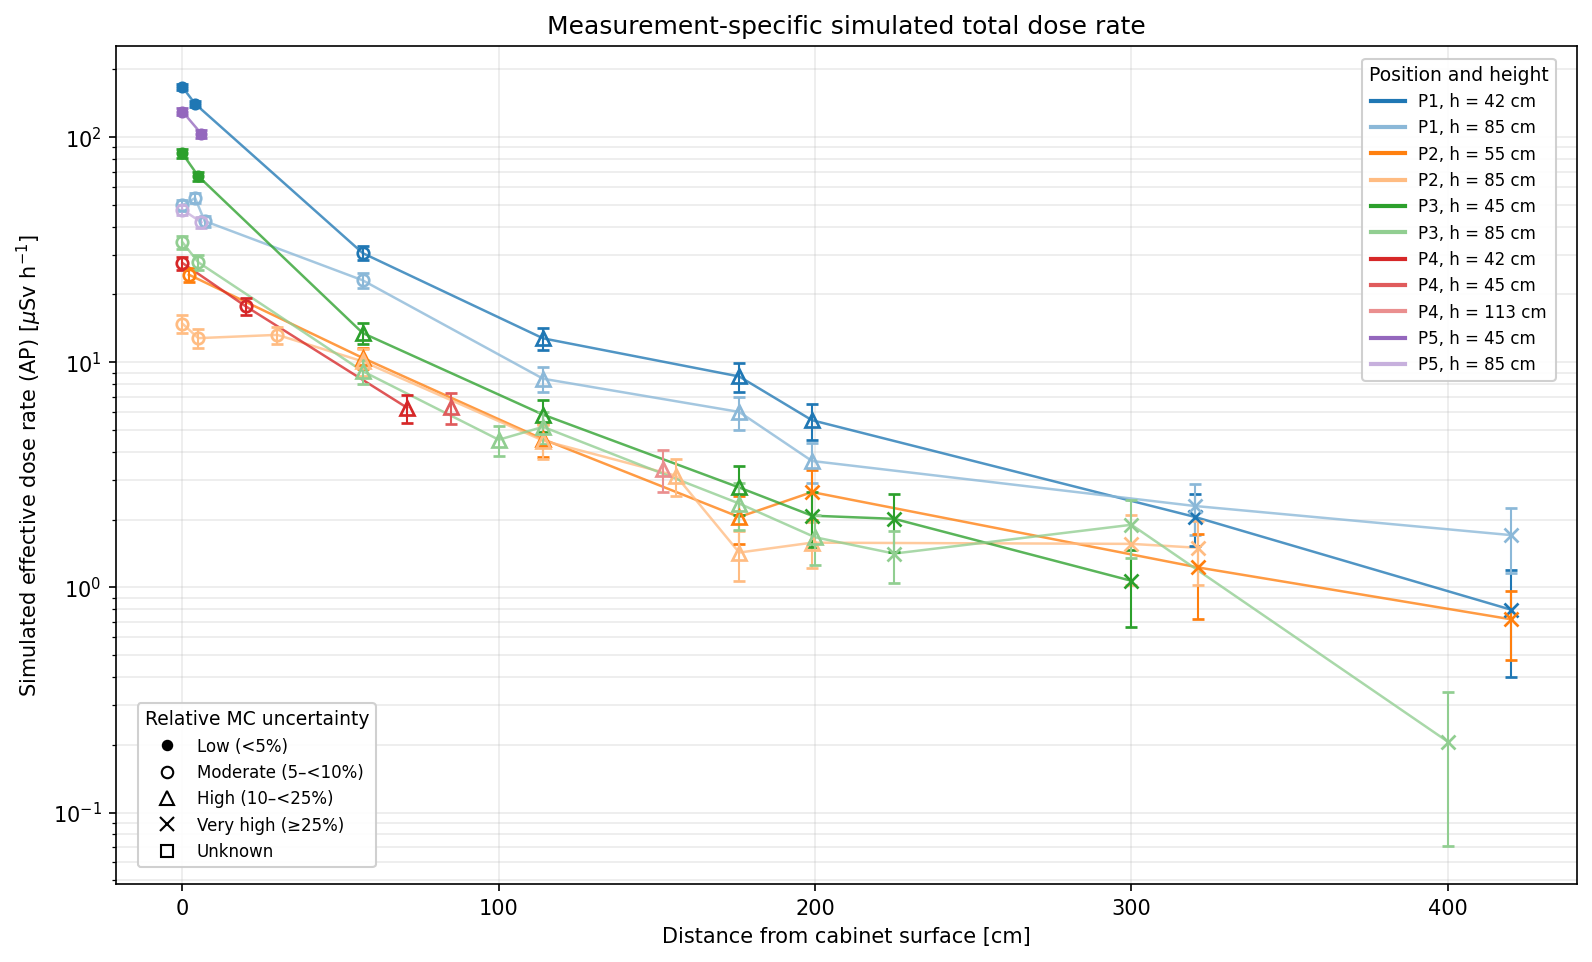

Saved figure: H2_hollow_cabinet_unified_outputs/figures/measurement_specific_total_dose_rate_vs_distance.png


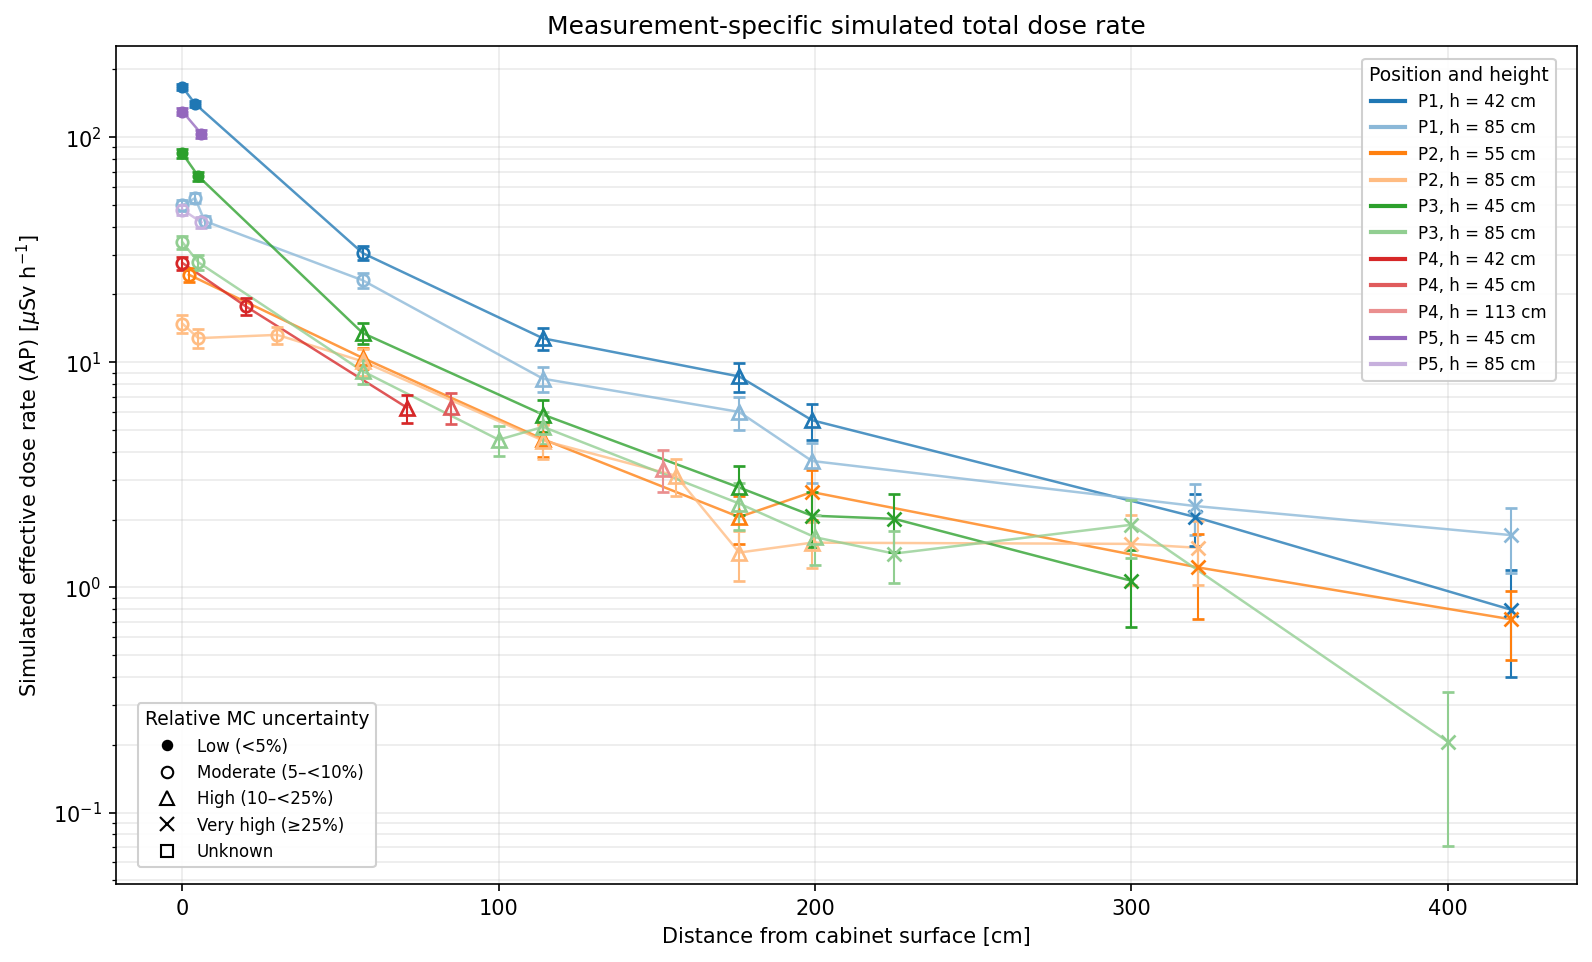

In [14]:
TOTAL_DOSE_COL = "total_dose_rate [uSv/h]"
TOTAL_DOSE_U_COL = "u_mc_total_dose_rate [uSv/h]"
TOTAL_DOSE_REL_U_COL = "rel_u_mc_total_dose_rate [%]"


def plot_total_dose_rate(
    dataframe,
    title,
    figure_path,
    figsize=(10.5, 6.3),
):
    """Plot total dose rate with the common P1--P5 visual convention."""

    fig, ax = plt.subplots(
        figsize=figsize,
        dpi=150,
        layout="constrained",
    )

    position_height_handles = []

    for (position, height_cm), curve_data in dataframe.groupby(
        ["position", "height_cm"],
        sort=True,
    ):
        curve_data = curve_data.sort_values("distance_cm")

        x = curve_data["distance_cm"].to_numpy(dtype=float)
        y = curve_data[TOTAL_DOSE_COL].to_numpy(dtype=float)
        yerr = curve_data[TOTAL_DOSE_U_COL].to_numpy(dtype=float)
        relative_uncertainty = curve_data[
            TOTAL_DOSE_REL_U_COL
        ].to_numpy(dtype=float)

        color = position_height_colors[
            (position, float(height_cm))
        ]

        line_y = np.where(
            np.isfinite(y) & (y > 0.0),
            y,
            np.nan,
        )

        ax.plot(
            x,
            line_y,
            color=color,
            linestyle="-",
            linewidth=1.2,
            alpha=0.78,
            label="_nolegend_",
            zorder=2,
        )

        add_uncertainty_errorbars(
            ax=ax,
            x=x,
            y=y,
            yerr=yerr,
            relative_uncertainty=relative_uncertainty,
            color=color,
        )

        position_height_handles.append(
            Line2D(
                [0],
                [0],
                color=color,
                linestyle="-",
                linewidth=2.0,
                label=f"{position}, h = {height_cm:g} cm",
            )
        )

    ax.set_yscale("log")
    ax.set_xlabel("Distance from cabinet surface [cm]")
    ax.set_ylabel(
        r"Simulated effective dose rate (AP) "
        r"[$\mu$Sv h$^{-1}$]"
    )
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.25)

    position_legend = ax.legend(
        handles=position_height_handles,
        title="Position and height",
        loc="upper right",
        bbox_to_anchor=(0.985, 0.985),
        borderaxespad=0.0,
        fontsize=8,
        title_fontsize=9,
        frameon=True,
        framealpha=0.92,
        facecolor="white",
    )
    ax.add_artist(position_legend)

    ax.legend(
        handles=make_uncertainty_legend_handles(),
        title="Relative MC uncertainty",
        loc="lower left",
        bbox_to_anchor=(0.015, 0.02),
        borderaxespad=0.0,
        fontsize=8,
        title_fontsize=9,
        frameon=True,
        framealpha=0.92,
        facecolor="white",
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    print(f"Saved figure: {figure_path}")
    return fig


total_dose_overview_path = (
    FIGURE_DIR / "measurement_specific_total_dose_rate_vs_distance.png"
)

plot_total_dose_rate(
    dataframe=unified_df,
    title="Measurement-specific simulated total dose rate",
    figure_path=total_dose_overview_path,
)


## 10.1) Lower- and upper-height comparisons

The same total-dose result is separated into the two measurement-height groups.
Exact heights remain visible through the colour shades and legend labels.


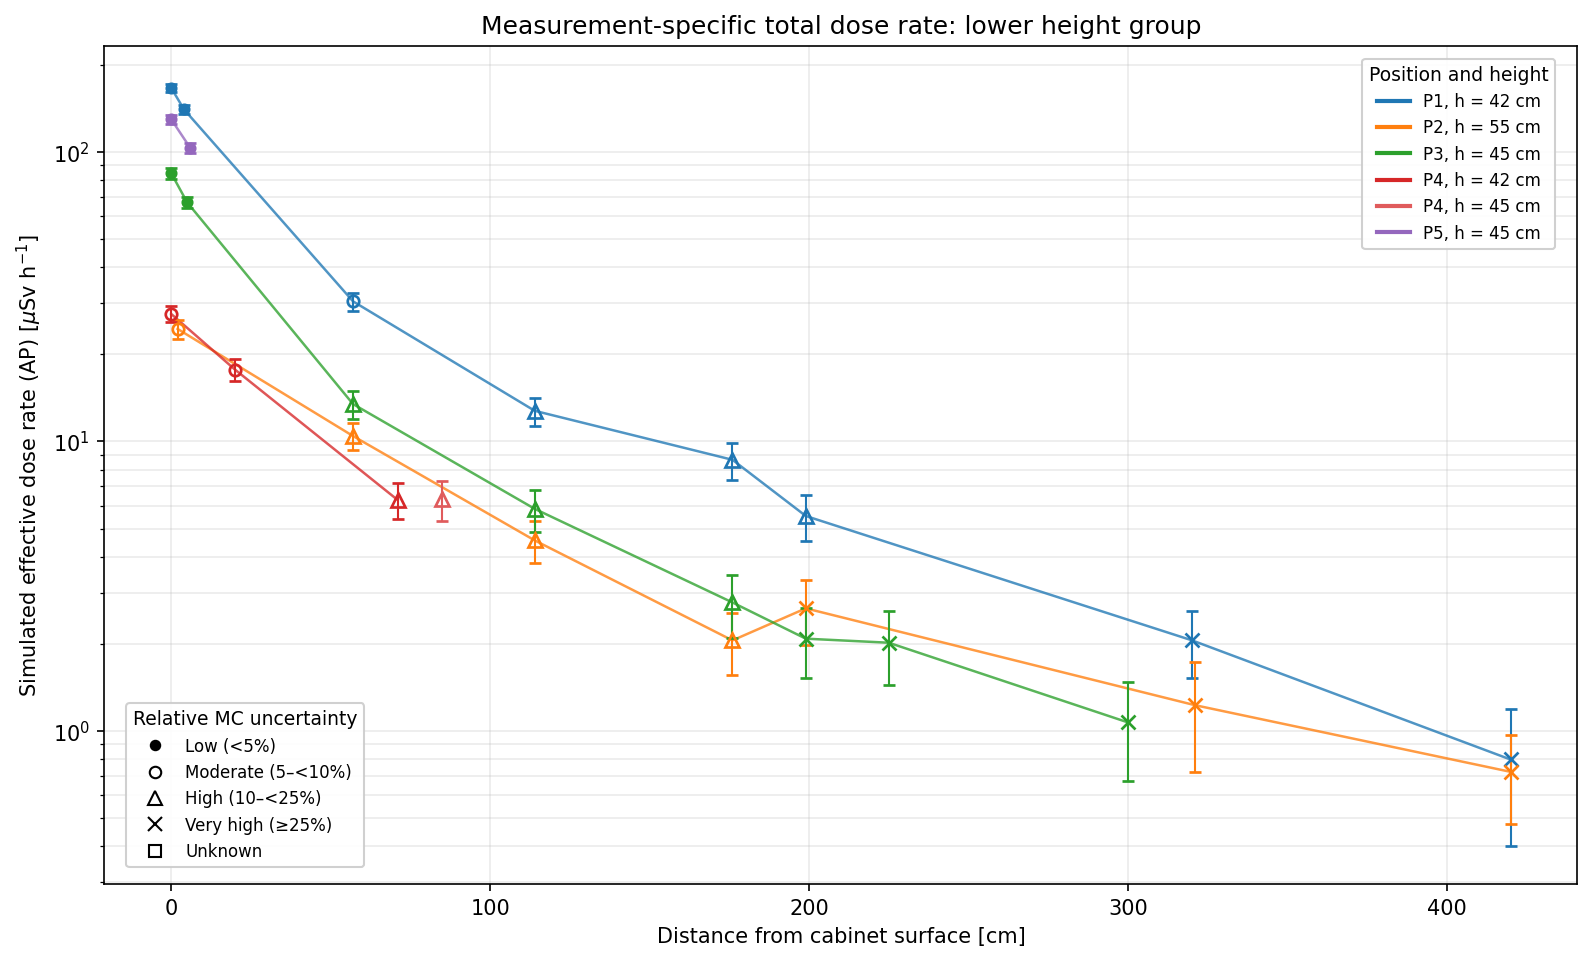

Saved figure: H2_hollow_cabinet_unified_outputs/figures/total_dose_rate_lower_height_group.png


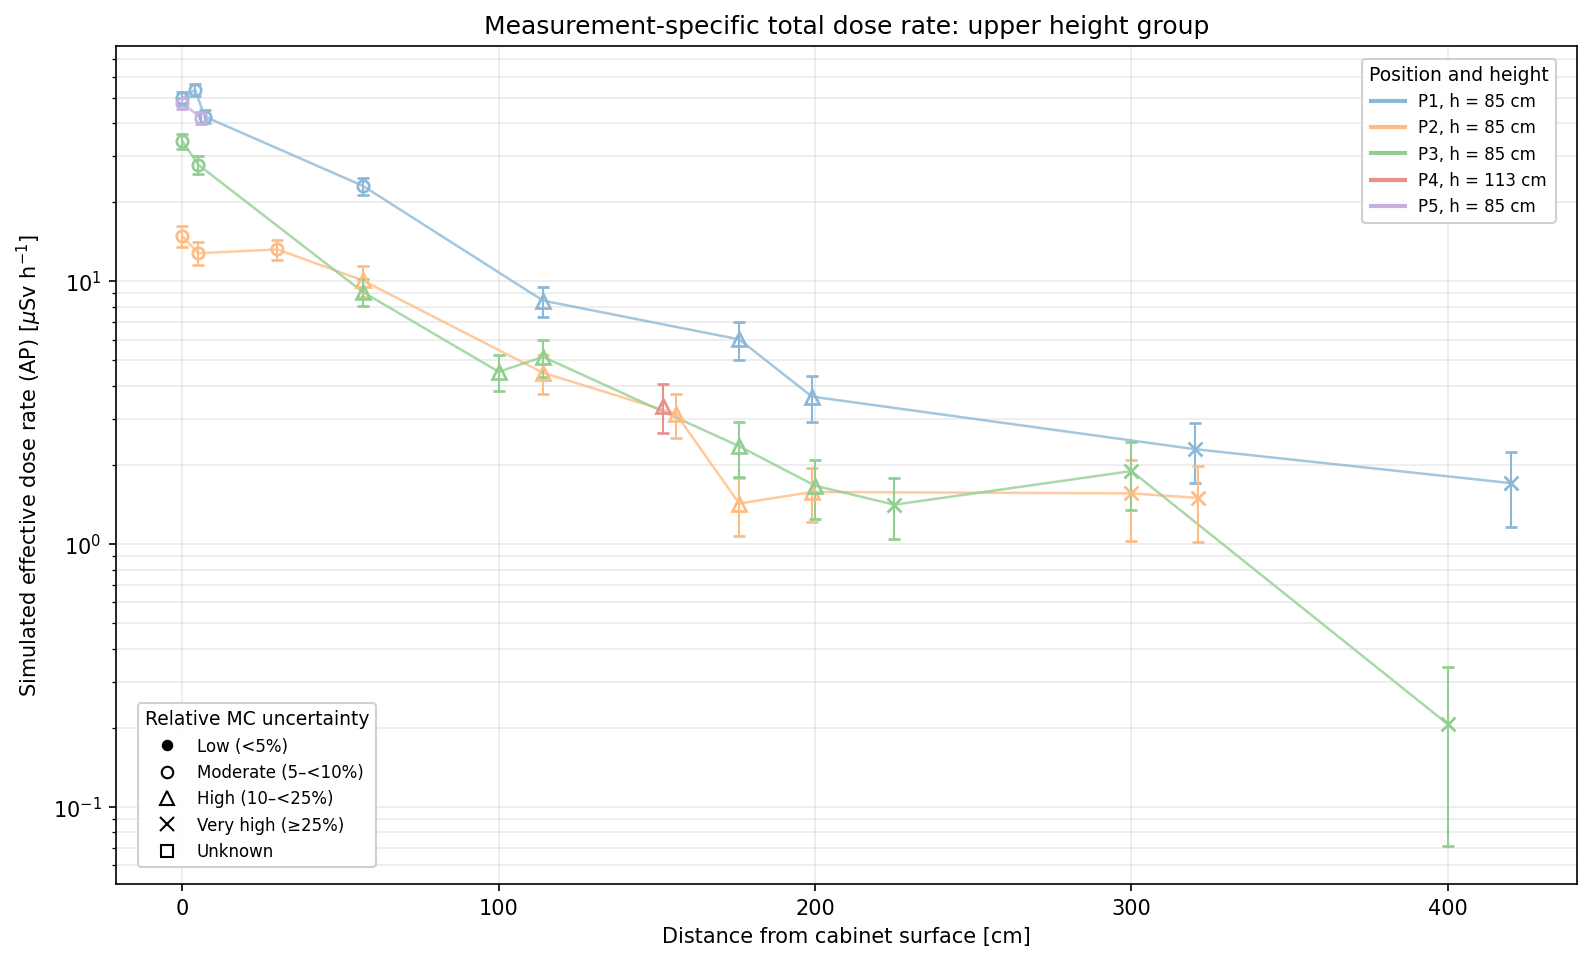

Saved figure: H2_hollow_cabinet_unified_outputs/figures/total_dose_rate_upper_height_group.png


In [15]:
height_group_plot_settings = [
    (
        LOWER_HEIGHT_LABEL,
        "Measurement-specific total dose rate: lower height group",
        FIGURE_DIR / "total_dose_rate_lower_height_group.png",
    ),
    (
        UPPER_HEIGHT_LABEL,
        "Measurement-specific total dose rate: upper height group",
        FIGURE_DIR / "total_dose_rate_upper_height_group.png",
    ),
]

for height_group, title, figure_path in height_group_plot_settings:
    subset = unified_df.loc[
        unified_df["height_group"] == height_group
    ].copy()

    if subset.empty:
        print(f"No data found for {height_group}.")
        continue

    plot_total_dose_rate(
        dataframe=subset,
        title=title,
        figure_path=figure_path,
    )


# 11) Neutron, gamma, and total dose-rate components

Each panel represents one scan direction. Colour shade identifies the exact
height within that position; line style identifies the radiation component.
The shaded regions show the OpenMC $\pm1\sigma$ interval for each component.


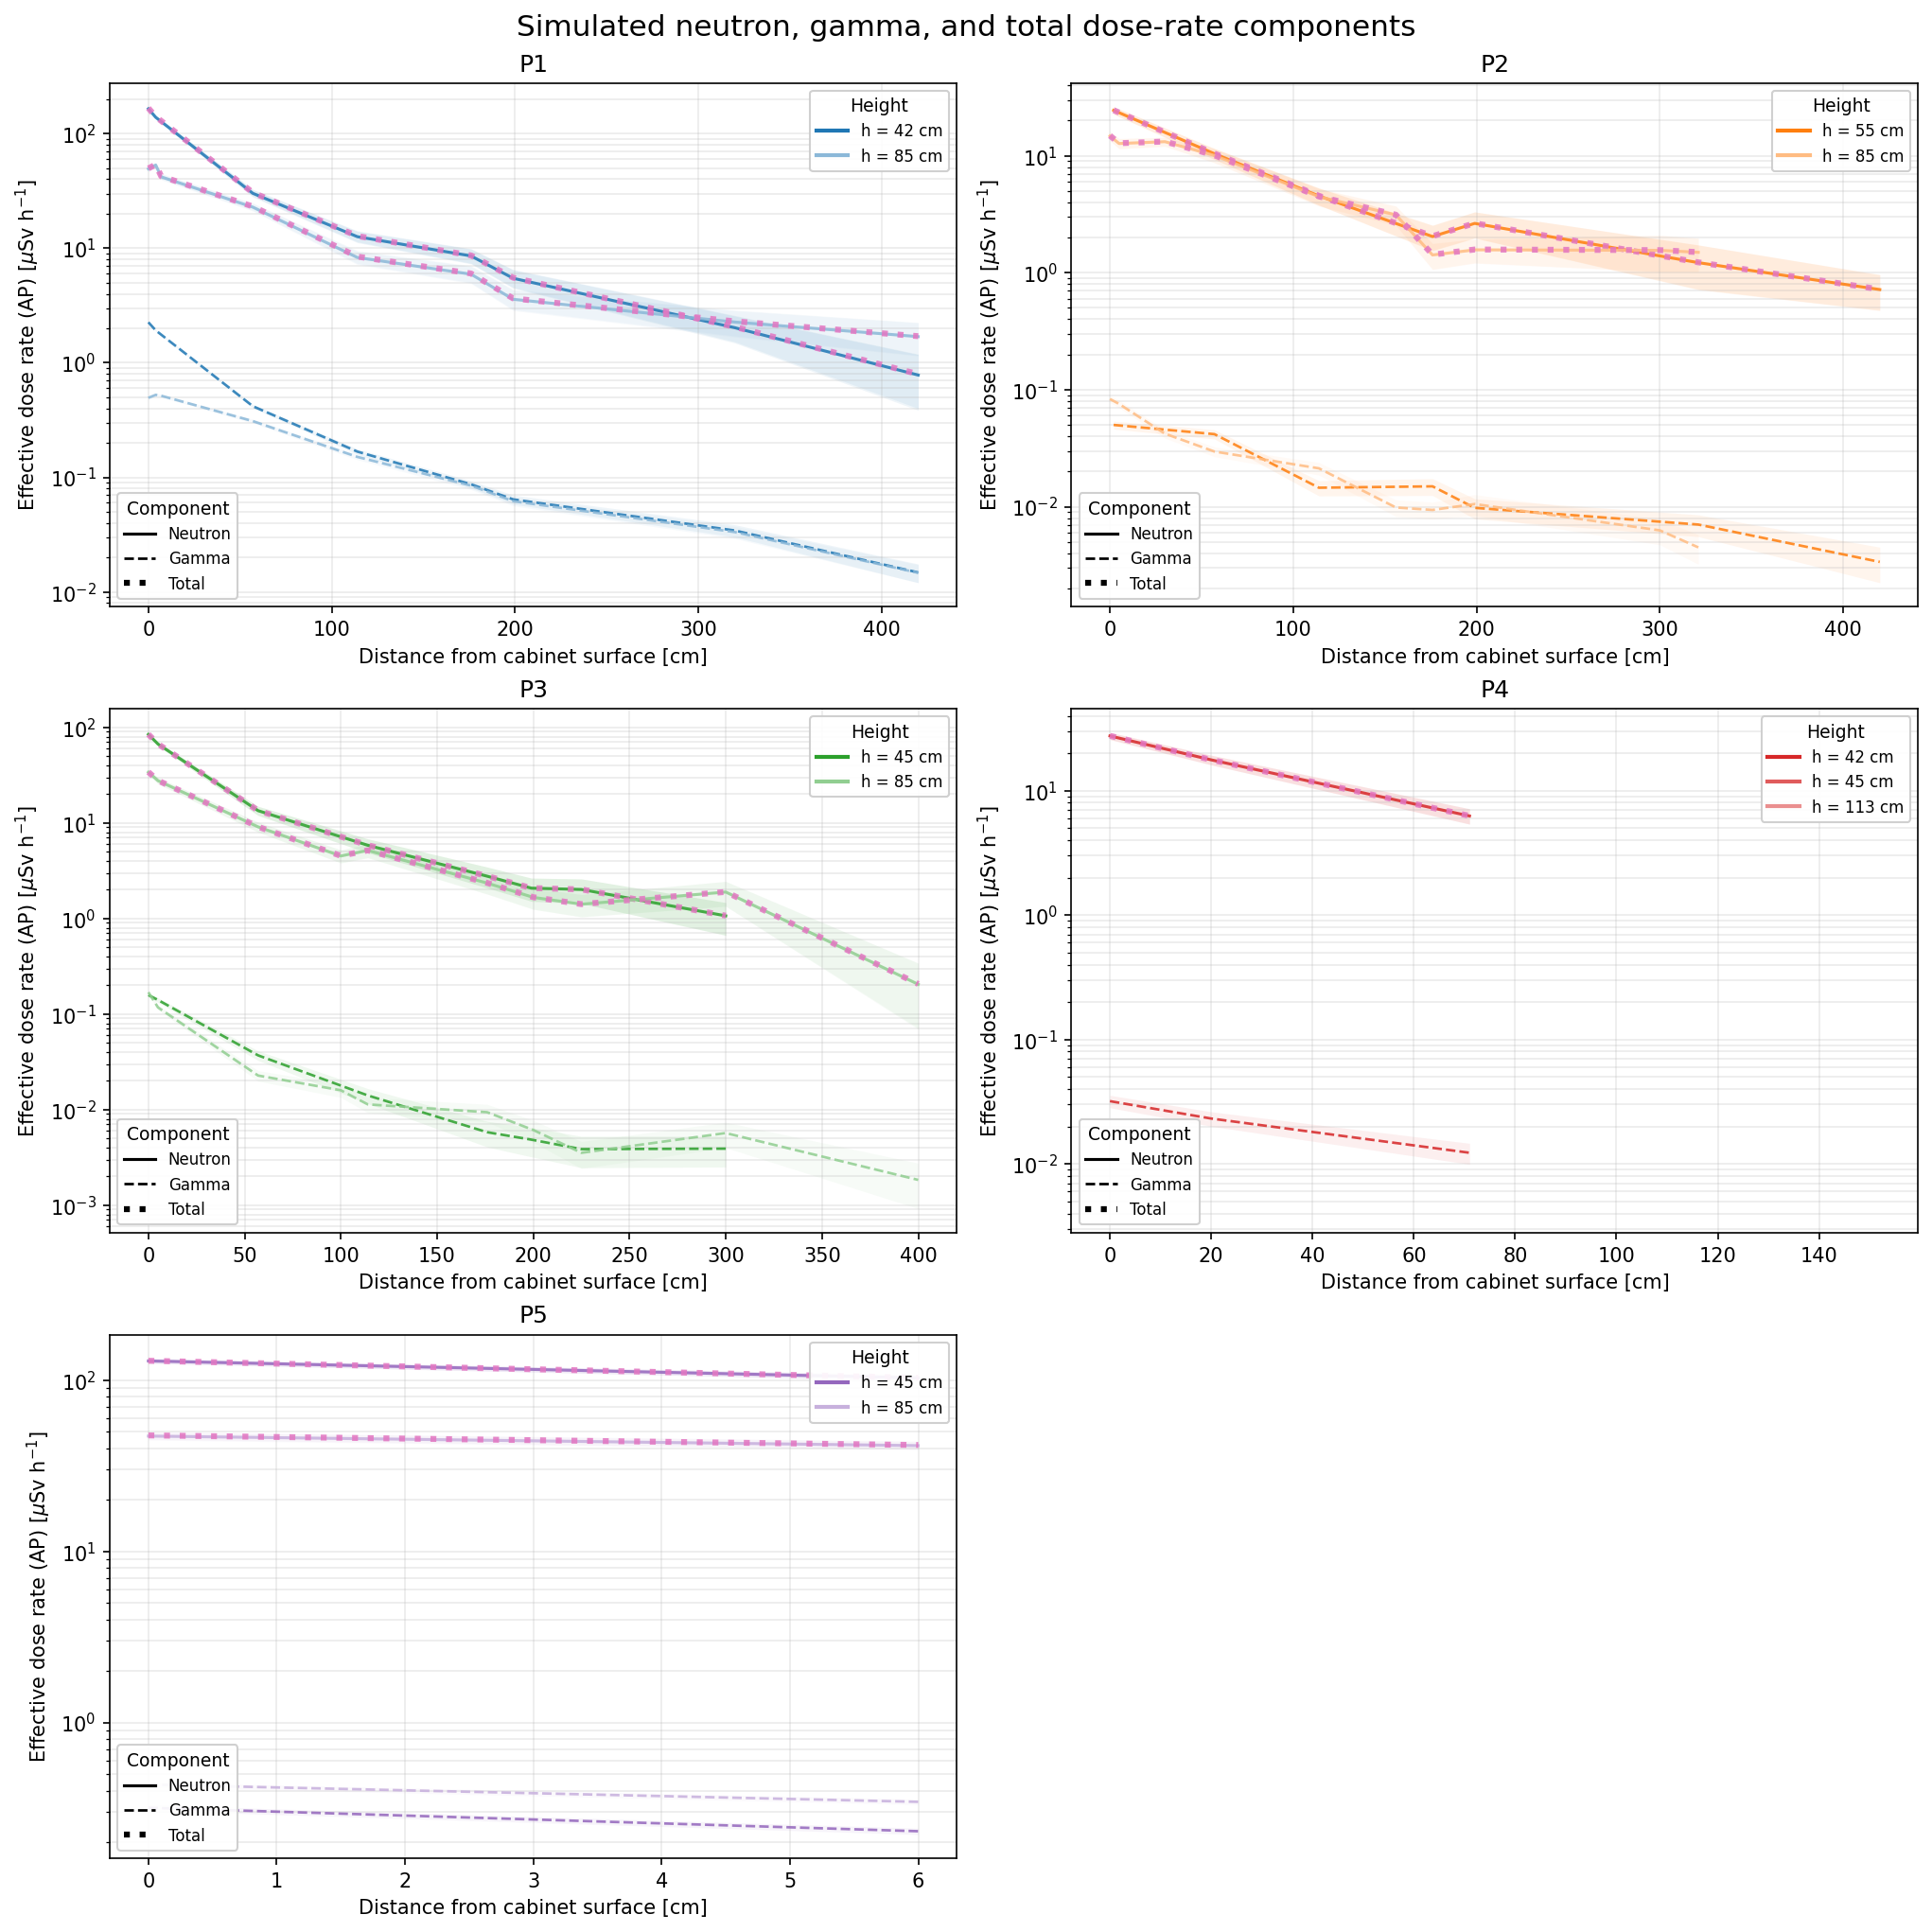

Saved figure: H2_hollow_cabinet_unified_outputs/figures/dose_rate_components_by_position.png


In [30]:
component_settings = [
    {
        "label": "Neutron",
        "value_col": "neutron_dose_rate [uSv/h]",
        "u_col": "u_mc_neutron_dose_rate [uSv/h]",
        "linestyle": "solid",
        "linewidth": 1.5,
    },
    {
        "label": "Gamma",
        "value_col": "gamma_dose_rate [uSv/h]",
        "u_col": "u_mc_gamma_dose_rate [uSv/h]",
        "linestyle": "--",
        "linewidth": 1.3,
    },
    {
        "label": "Total",
        "value_col": "total_dose_rate [uSv/h]",
        "u_col": "u_mc_total_dose_rate [uSv/h]",
        "linestyle": ":",
        "linewidth": 3.0,
        "color": "tab:pink",
    },
]

fig, axes = plt.subplots(
    3,
    2,
    figsize=(13.5, 13.5),
    dpi=150,
    layout="constrained",
)

axes = axes.flatten()

for axis_index, position in enumerate(POSITION_ORDER):
    ax = axes[axis_index]
    position_data = unified_df.loc[
        unified_df["position"] == position
    ].copy()

    if position_data.empty:
        ax.set_visible(False)
        continue

    height_handles = []

    for height_cm, curve_data in position_data.groupby(
        "height_cm",
        sort=True,
    ):
        curve_data = curve_data.sort_values("distance_cm")
        x = curve_data["distance_cm"].to_numpy(dtype=float)
        color = position_height_colors[
            (position, float(height_cm))
        ]

        for component in component_settings:
            y = curve_data[
                component["value_col"]
            ].to_numpy(dtype=float)
            yerr = curve_data[
                component["u_col"]
            ].to_numpy(dtype=float)

            valid = np.isfinite(x) & np.isfinite(y) & (y > 0.0)

            plot_color = component.get("color", color)

            ax.plot(
                x[valid],
                y[valid],
                color=plot_color,
                linestyle=component["linestyle"],
                linewidth=component["linewidth"],
                alpha=0.86,
                zorder=2,
            )

            band_valid = valid & np.isfinite(yerr) & (yerr >= 0.0)

            if np.any(band_valid):
                lower = np.maximum(
                    y[band_valid] - yerr[band_valid],
                    np.finfo(float).tiny,
                )
                upper = y[band_valid] + yerr[band_valid]

                ax.fill_between(
                    x[band_valid],
                    lower,
                    upper,
                    color=color,
                    alpha=0.07,
                    linewidth=0.0,
                    zorder=1,
                )

        height_handles.append(
            Line2D(
                [0],
                [0],
                color=color,
                linestyle="-",
                linewidth=2.0,
                label=f"h = {height_cm:g} cm",
            )
        )

    component_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            linestyle=component["linestyle"],
            linewidth=component["linewidth"],
            label=component["label"],
        )
        for component in component_settings
    ]

    height_legend = ax.legend(
        handles=height_handles,
        title="Height",
        loc="upper right",
        fontsize=8,
        title_fontsize=9,
        framealpha=0.92,
    )
    ax.add_artist(height_legend)

    ax.legend(
        handles=component_handles,
        title="Component",
        loc="lower left",
        fontsize=8,
        title_fontsize=9,
        framealpha=0.92,
    )

    ax.set_yscale("log")
    ax.set_title(position)
    ax.set_xlabel("Distance from cabinet surface [cm]")
    ax.set_ylabel(
        r"Effective dose rate (AP) [$\mu$Sv h$^{-1}$]"
    )
    ax.grid(True, which="both", alpha=0.25)

for unused_axis in axes[len(POSITION_ORDER):]:
    unused_axis.set_visible(False)

fig.suptitle(
    "Simulated neutron, gamma, and total dose-rate components",
    fontsize=15,
)

dose_component_figure_path = (
    FIGURE_DIR / "dose_rate_components_by_position.png"
)

fig.savefig(
    dose_component_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved figure: {dose_component_figure_path}")


# 12) Common-cube flux ratio, gamma dose fraction, and Monte Carlo precision

The local gamma-to-neutron flux ratio is shown only for the co-located common
cubes. The gamma dose fraction is shown separately; the neutron dose fraction
is its complement,

$$
f_n = 1-f_\gamma.
$$

A separate precision plot shows the relative MC uncertainty of the total dose
rate and the 5%, 10%, and 25% classification boundaries.


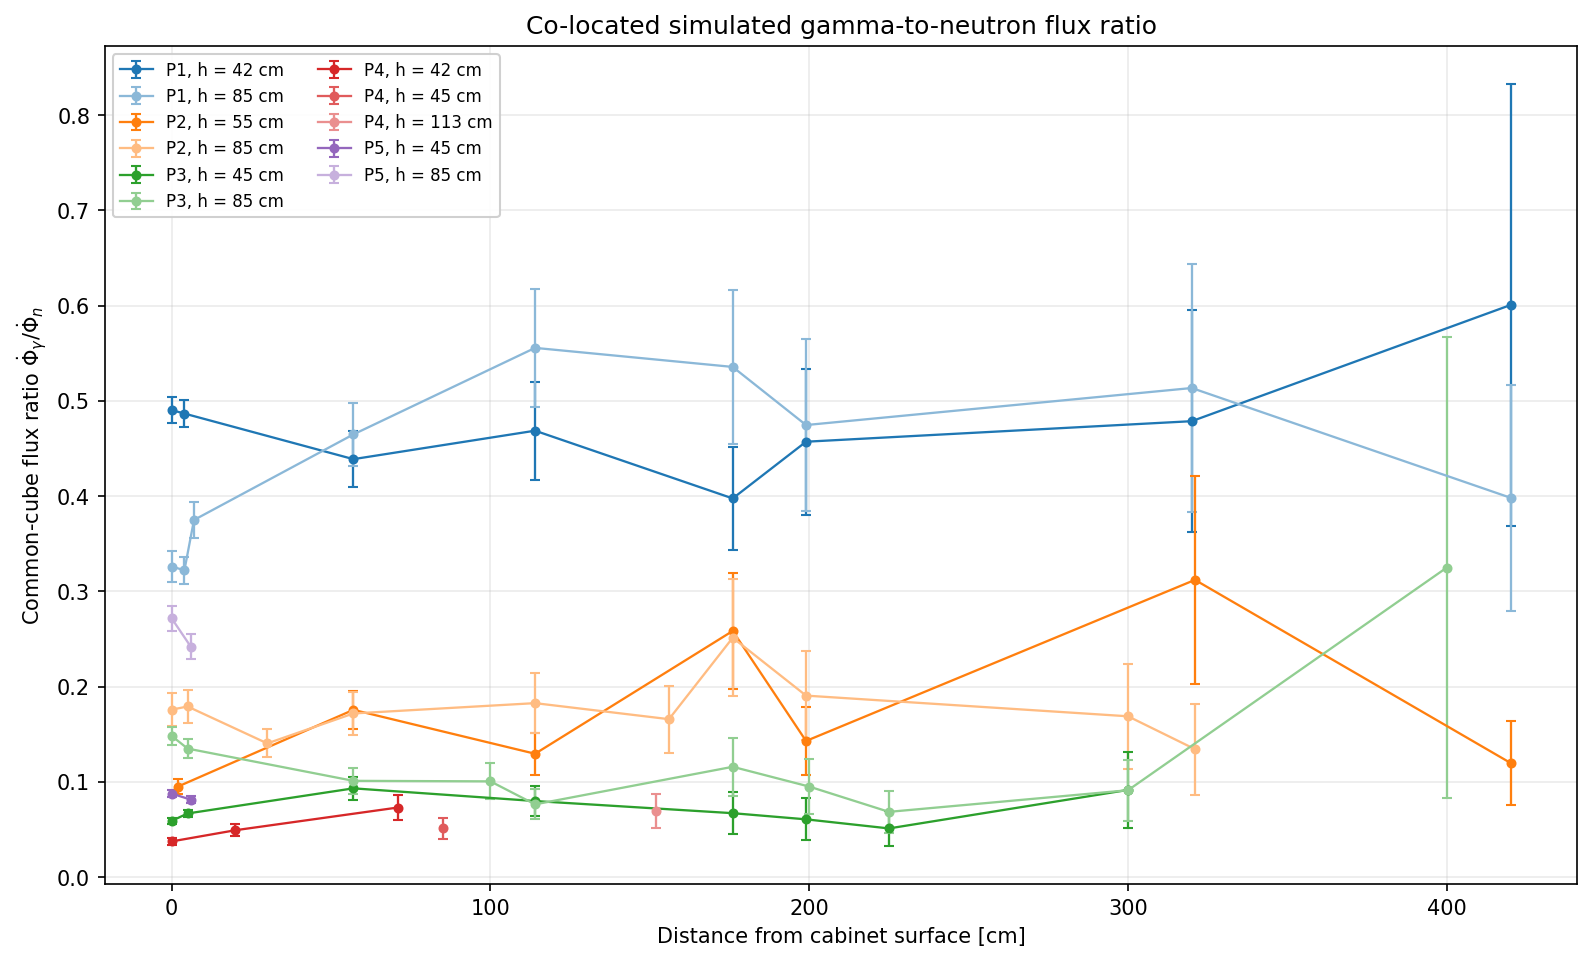

Saved figure: H2_hollow_cabinet_unified_outputs/figures/common_gamma_to_neutron_flux_ratio.png


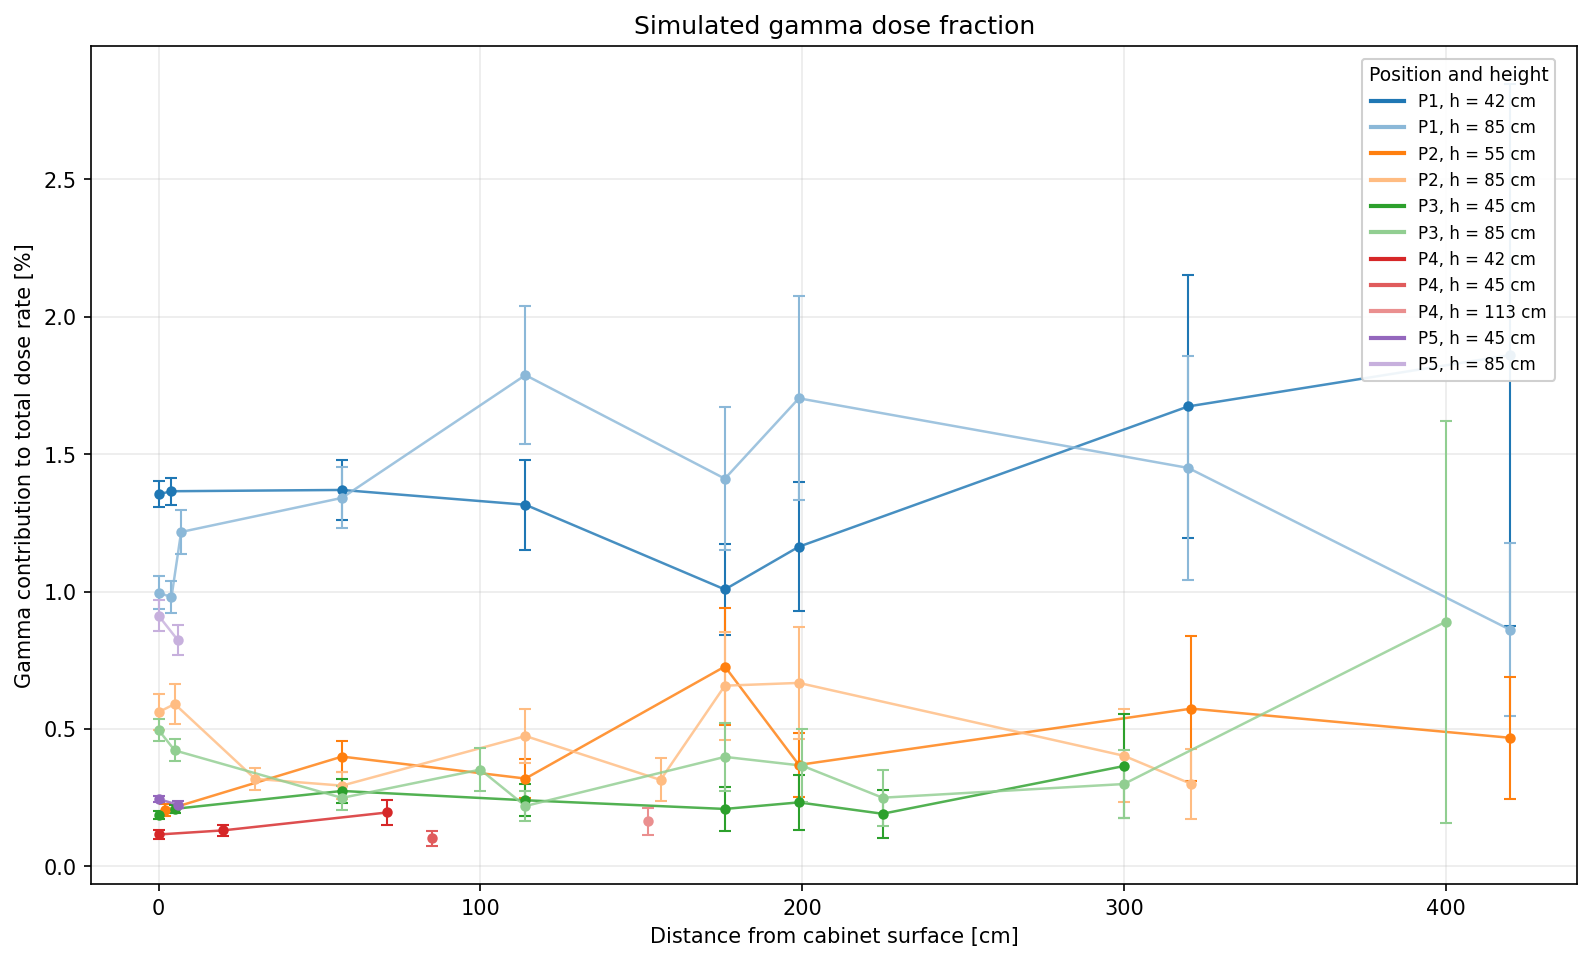

Saved figure: H2_hollow_cabinet_unified_outputs/figures/gamma_dose_fraction_vs_distance.png


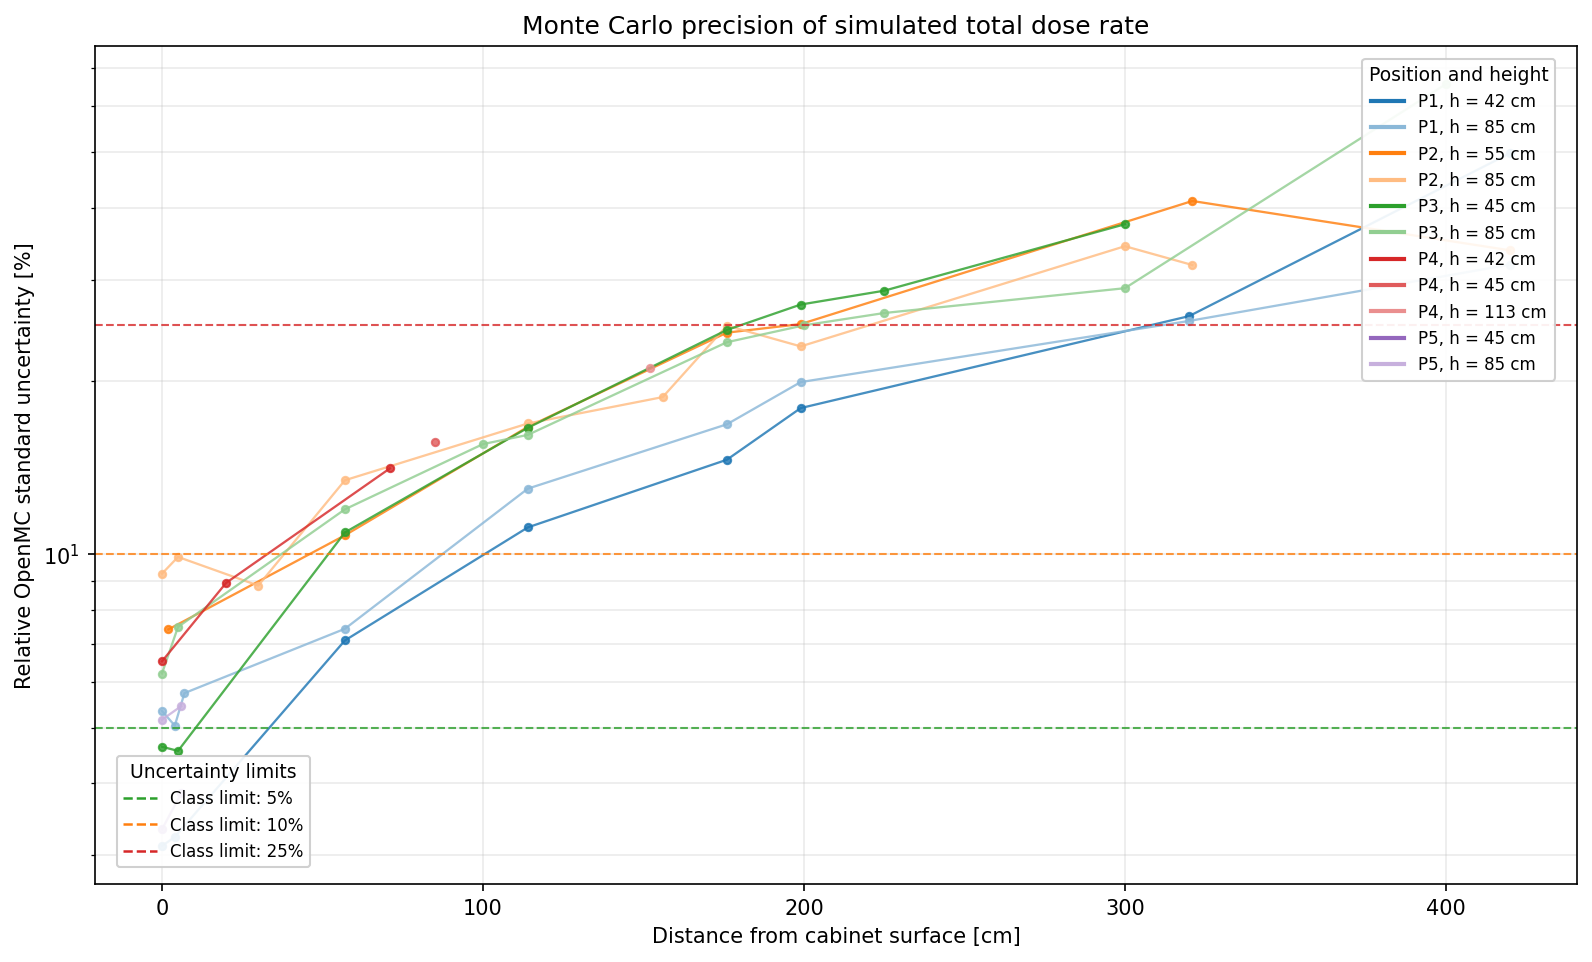

Saved figure: H2_hollow_cabinet_unified_outputs/figures/total_dose_relative_mc_uncertainty.png


In [31]:
# ------------------------------------------------------------
# Co-located gamma-to-neutron flux ratio
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 6.3), dpi=150, layout="constrained")
for (position, height_cm), curve_data in unified_df.groupby(
    ["position", "height_cm"], sort=True
):
    curve_data = curve_data.sort_values("distance_cm")
    color = position_height_colors[(position, float(height_cm))]
    ax.errorbar(
        curve_data["distance_cm"],
        curve_data["common_gamma_to_neutron_flux_ratio"],
        yerr=curve_data["u_mc_common_gamma_to_neutron_flux_ratio"],
        marker="o",
        markersize=3.8,
        linewidth=1.1,
        capsize=2.5,
        color=color,
        label=f"{position}, h = {height_cm:g} cm",
    )
ax.set_xlabel("Distance from cabinet surface [cm]")
ax.set_ylabel(r"Common-cube flux ratio $\dot\Phi_\gamma/\dot\Phi_n$")
ax.set_title("Co-located simulated gamma-to-neutron flux ratio")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8, ncol=2, framealpha=0.92)
common_flux_ratio_figure_path = FIGURE_DIR / "common_gamma_to_neutron_flux_ratio.png"
fig.savefig(common_flux_ratio_figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"Saved figure: {common_flux_ratio_figure_path}")


# ------------------------------------------------------------
# Gamma dose fraction
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 6.3),
    dpi=150,
    layout="constrained",
)

fraction_handles = []

for (position, height_cm), curve_data in unified_df.groupby(
    ["position", "height_cm"],
    sort=True,
):
    curve_data = curve_data.sort_values("distance_cm")
    x = curve_data["distance_cm"].to_numpy(dtype=float)
    y = 100.0 * curve_data["gamma_dose_fraction"].to_numpy(dtype=float)
    yerr = (
        100.0
        * curve_data["u_mc_gamma_dose_fraction"].to_numpy(dtype=float)
    )
    color = position_height_colors[(position, float(height_cm))]

    valid = np.isfinite(x) & np.isfinite(y) & (y > 0.0)

    ax.plot(
        x[valid],
        y[valid],
        color=color,
        linewidth=1.2,
        alpha=0.82,
    )

    error_valid = valid & np.isfinite(yerr) & (yerr >= 0.0)

    ax.errorbar(
        x[error_valid],
        y[error_valid],
        yerr=yerr[error_valid],
        fmt="o",
        markersize=4.0,
        color=color,
        ecolor=color,
        capsize=3,
        linewidth=1.0,
    )

    fraction_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2.0,
            label=f"{position}, h = {height_cm:g} cm",
        )
    )

positive_fraction = unified_df.loc[
    unified_df["gamma_dose_fraction"] > 0.0,
    "gamma_dose_fraction",
]

if not positive_fraction.empty:
    dynamic_range = (
        positive_fraction.max() / positive_fraction.min()
    )
    if dynamic_range >= 100.0:
        ax.set_yscale("log")

ax.set_xlabel("Distance from cabinet surface [cm]")
ax.set_ylabel("Gamma contribution to total dose rate [%]")
ax.set_title("Simulated gamma dose fraction")
ax.grid(True, which="both", alpha=0.25)
ax.legend(
    handles=fraction_handles,
    title="Position and height",
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    borderaxespad=0.0,
    fontsize=8,
    title_fontsize=9,
    framealpha=0.92,
)

gamma_fraction_figure_path = (
    FIGURE_DIR / "gamma_dose_fraction_vs_distance.png"
)

fig.savefig(
    gamma_fraction_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved figure: {gamma_fraction_figure_path}")


# ------------------------------------------------------------
# Relative MC uncertainty of total dose rate
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10.5, 6.3),
    dpi=150,
    layout="constrained",
)

uncertainty_curve_handles = []

for (position, height_cm), curve_data in unified_df.groupby(
    ["position", "height_cm"],
    sort=True,
):
    curve_data = curve_data.sort_values("distance_cm")
    color = position_height_colors[(position, float(height_cm))]

    ax.plot(
        curve_data["distance_cm"],
        curve_data["rel_u_mc_total_dose_rate [%]"],
        marker="o",
        markersize=3.5,
        linewidth=1.1,
        alpha=0.82,
        color=color,
    )

    uncertainty_curve_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2.0,
            label=f"{position}, h = {height_cm:g} cm",
        )
    )

threshold_settings = [
    (MC_LOW_U_MAX_PERCENT, "5%", "tab:green"),
    (MC_MODERATE_U_MAX_PERCENT, "10%", "tab:orange"),
    (MC_HIGH_U_MAX_PERCENT, "25%", "tab:red"),
]

threshold_handles = []

for threshold, label, color in threshold_settings:
    ax.axhline(
        threshold,
        color=color,
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
    )
    threshold_handles.append(
        Line2D(
            [0],
            [0],
            color=color,
            linestyle="--",
            linewidth=1.2,
            label=f"Class limit: {label}",
        )
    )

positive_uncertainties = unified_df.loc[
    unified_df["rel_u_mc_total_dose_rate [%]"] > 0.0,
    "rel_u_mc_total_dose_rate [%]",
]

if not positive_uncertainties.empty:
    ax.set_yscale("log")

ax.set_xlabel("Distance from cabinet surface [cm]")
ax.set_ylabel("Relative OpenMC standard uncertainty [%]")
ax.set_title("Monte Carlo precision of simulated total dose rate")
ax.grid(True, which="both", alpha=0.25)

curve_legend = ax.legend(
    handles=uncertainty_curve_handles,
    title="Position and height",
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    borderaxespad=0.0,
    fontsize=8,
    title_fontsize=9,
    framealpha=0.92,
)
ax.add_artist(curve_legend)

ax.legend(
    handles=threshold_handles,
    title="Uncertainty limits",
    loc="lower left",
    bbox_to_anchor=(0.015, 0.02),
    borderaxespad=0.0,
    fontsize=8,
    title_fontsize=9,
    framealpha=0.92,
)

total_uncertainty_figure_path = (
    FIGURE_DIR / "total_dose_relative_mc_uncertainty.png"
)

fig.savefig(
    total_uncertainty_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved figure: {total_uncertainty_figure_path}")


# 13) Spatial view of the unified dose-tally positions

Several heights share the same $(x,y)$ coordinate. The spatial colour map
therefore uses the median total dose rate across the available heights at each
plan-view point. The full height-resolved results remain in the final table and
distance plots. The map uses `common_dose_x_cm` and `common_dose_y_cm`; it does
not use the displaced LND 712 gamma-flux centres.


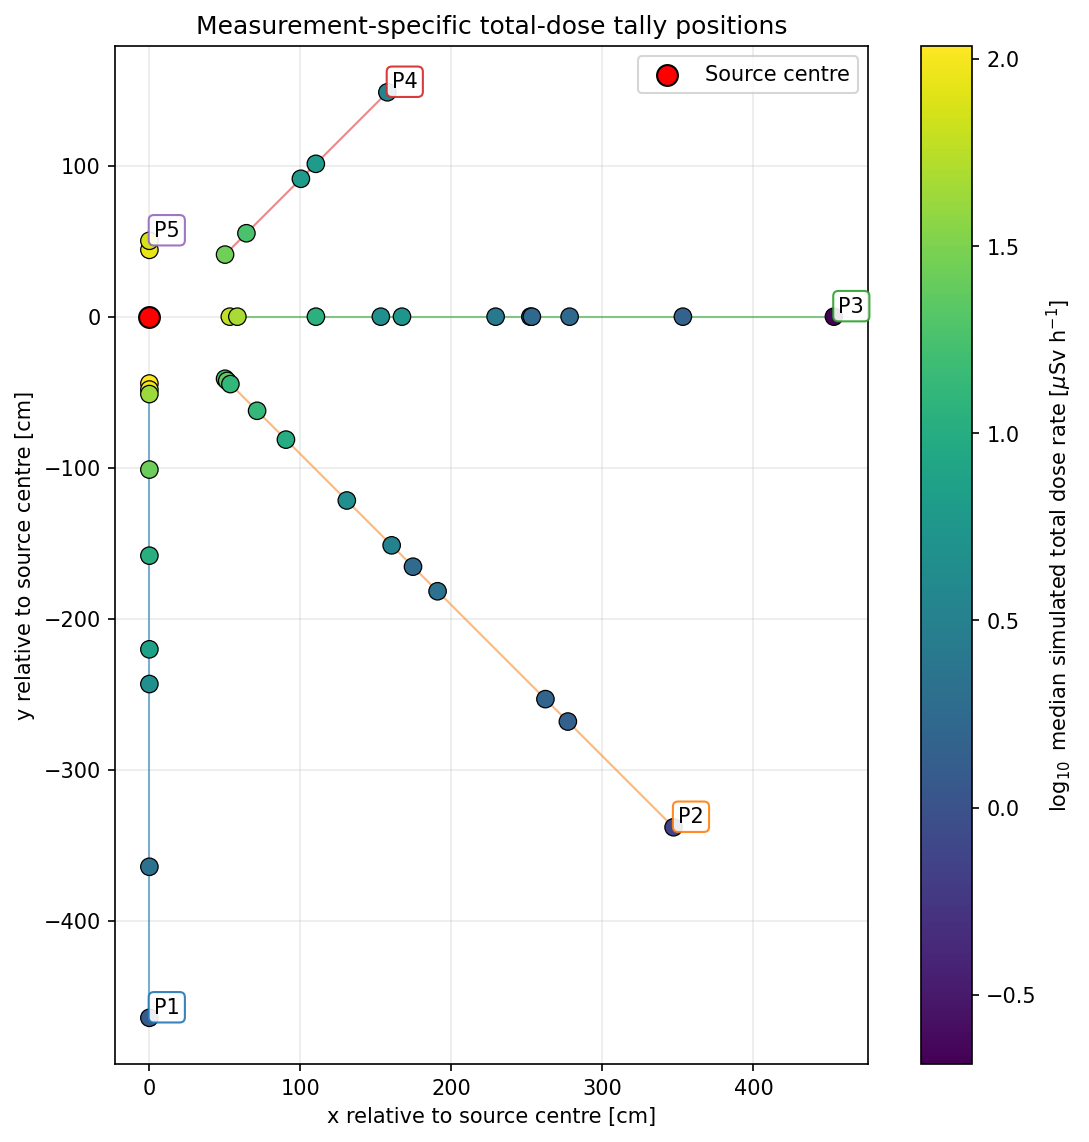

Saved figure: H2_hollow_cabinet_unified_outputs/figures/measurement_specific_total_dose_xy_map.png


In [32]:
spatial_total_dose_df = (
    unified_df
    .groupby(
        [
            "position",
            "distance_cm",
            "common_dose_x_cm",
            "common_dose_y_cm",
        ],
        as_index=False,
    )
    .agg(
        median_total_dose_rate_uSv_h=(
            "total_dose_rate [uSv/h]",
            "median",
        ),
        number_of_heights=("height_cm", "nunique"),
    )
)

positive_spatial_data = spatial_total_dose_df.loc[
    spatial_total_dose_df["median_total_dose_rate_uSv_h"] > 0.0
].copy()

if positive_spatial_data.empty:
    raise ValueError("No positive total dose rates are available for the map.")

fig, ax = plt.subplots(
    figsize=(8.5, 7.5),
    dpi=150,
    layout="constrained",
)

scatter = ax.scatter(
    positive_spatial_data["common_dose_x_cm"],
    positive_spatial_data["common_dose_y_cm"],
    c=np.log10(
        positive_spatial_data["median_total_dose_rate_uSv_h"]
    ),
    s=70,
    edgecolor="black",
    linewidth=0.6,
    zorder=3,
)

for position, position_data in positive_spatial_data.groupby(
    "position",
    sort=True,
):
    xy_data = position_data.sort_values("distance_cm")

    ax.plot(
        xy_data["common_dose_x_cm"],
        xy_data["common_dose_y_cm"],
        color=POSITION_COLORS[position],
        linewidth=1.0,
        alpha=0.55,
        zorder=2,
    )

    label_row = xy_data.iloc[-1]

    ax.text(
        label_row["common_dose_x_cm"] + 3.0,
        label_row["common_dose_y_cm"] + 3.0,
        position,
        fontsize=10,
        fontweight="normal",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": POSITION_COLORS[position],
            "alpha": 0.90,
        },
        zorder=6,
    )

ax.scatter(
    [0.0],
    [0.0],
    s=100,
    color="red",
    edgecolor="black",
    label="Source centre",
    zorder=5,
)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label(
    r"$\log_{10}$ median simulated total dose rate "
    r"[$\mu$Sv h$^{-1}$]"
)

ax.set_xlabel("x relative to source centre [cm]")
ax.set_ylabel("y relative to source centre [cm]")
ax.set_title("Measurement-specific total-dose tally positions")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend(loc="best", frameon=True)

spatial_map_figure_path = (
    FIGURE_DIR / "measurement_specific_total_dose_xy_map.png"
)

fig.savefig(
    spatial_map_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved figure: {spatial_map_figure_path}")


# 14) Save final tables, metadata, and figure inventory

The principal downstream product is
`unified_simulated_radiation_field_final.csv`. It contains the separate fluxes,
all three coordinate definitions, component dose rates, total dose rate, dose
fractions, dose ratios, and MC-only standard uncertainties for all 61 scan
points. It also contains the co-located common-cube neutron and gamma fluxes,
their local ratio, and their arithmetic total particle flux.


In [33]:
unified_output_csv = (
    TABLE_DIR / "hollow_unified_simulated_radiation_field_final.csv"
)
main_unified_output_csv = OUTPUT_DIR / "hollow_unified_simulated_radiation_field_final.csv"

neutron_dose_output_csv = (
    TABLE_DIR / "hollow_neutron_ap_dose_rate.csv"
)
gamma_dose_output_csv = (
    TABLE_DIR / "hollow_gamma_ap_dose_rate.csv"
)
common_neutron_flux_output_csv = (
    TABLE_DIR / "hollow_common_cube_neutron_flux.csv"
)
common_gamma_flux_output_csv = (
    TABLE_DIR / "hollow_common_cube_gamma_flux.csv"
)
position_summary_csv = (
    TABLE_DIR / "simulated_radiation_field_position_summary.csv"
)
height_position_summary_csv = (
    TABLE_DIR / "simulated_radiation_field_height_position_summary.csv"
)
uncertainty_counts_csv = (
    TABLE_DIR / "total_dose_mc_uncertainty_class_counts.csv"
)
very_high_uncertainty_csv = (
    TABLE_DIR / "total_dose_very_high_mc_uncertainty_points.csv"
)
spatial_plotting_data_csv = (
    TABLE_DIR / "total_dose_spatial_plotting_data.csv"
)
coordinate_definition_csv = (
    TABLE_DIR / "h2_tally_coordinate_definitions.csv"
)
gamma_dose_trigger_audit_csv = (
    TABLE_DIR / "gamma_dose_trigger_audit.csv"
)


unified_df.to_csv(unified_output_csv, index=False)
unified_df.to_csv(main_unified_output_csv, index=False)
neutron_dose_df.to_csv(neutron_dose_output_csv, index=False)
gamma_dose_df.to_csv(gamma_dose_output_csv, index=False)
common_neutron_flux_df.to_csv(common_neutron_flux_output_csv, index=False)
common_gamma_flux_df.to_csv(common_gamma_flux_output_csv, index=False)
position_summary_df.to_csv(position_summary_csv, index=False)
height_position_summary_df.to_csv(
    height_position_summary_csv,
    index=False,
)
total_dose_uncertainty_counts_df.to_csv(
    uncertainty_counts_csv,
    index=False,
)
very_high_total_dose_uncertainty_points_df.to_csv(
    very_high_uncertainty_csv,
    index=False,
)
spatial_total_dose_df.to_csv(spatial_plotting_data_csv, index=False)

coordinate_definition_df = unified_df[
    [
        "position",
        "point_name",
        "distance_cm",
        "height_cm",
        "neutron_flux_x_cm",
        "neutron_flux_y_cm",
        "neutron_flux_z_cm",
        "gamma_flux_x_cm",
        "gamma_flux_y_cm",
        "gamma_flux_z_cm",
        "common_dose_x_cm",
        "common_dose_y_cm",
        "common_dose_z_cm",
        "common_flux_x_cm",
        "common_flux_y_cm",
        "common_flux_z_cm",
        "common_flux_tally_volume_cm3",
        "flux_centre_separation_cm",
    ]
].copy()
coordinate_definition_df.to_csv(coordinate_definition_csv, index=False)
GAMMA_DOSE_TRIGGER_AUDIT_DF.to_csv(
    gamma_dose_trigger_audit_csv,
    index=False,
)


metadata_rows = [
    {
        "quantity": "notebook",
        "value": "2H_Hollow_cabinet_unified.ipynb",
        "unit": "",
    },
    {
        "quantity": "number_of_scan_points",
        "value": len(unified_df),
        "unit": "points",
    },
    {
        "quantity": "source_manufacturer",
        "value": SOURCE_MANUFACTURER,
        "unit": "",
    },
    {
        "quantity": "source_model",
        "value": SOURCE_MODEL,
        "unit": "",
    },
    {
        "quantity": "source_serial_number",
        "value": SOURCE_SERIAL_NUMBER,
        "unit": "",
    },
    {
        "quantity": "factory_neutron_emission_reference",
        "value": SOURCE_NEUTRON_EMISSION_REF,
        "unit": "n/s",
    },
    {
        "quantity": "factory_neutron_emission_reference_date",
        "value": SOURCE_NEUTRON_EMISSION_REF_DATE,
        "unit": "",
    },
    {
        "quantity": "selected_neutron_emission",
        "value": SOURCE_NEUTRON_EMISSION,
        "unit": "n/s",
    },
    {
        "quantity": "selected_neutron_emission_date",
        "value": SOURCE_EVALUATION_DATE,
        "unit": "",
    },
    {
        "quantity": "neutron_source_normalization_status",
        "value": SOURCE_NORMALIZATION_STATUS,
        "unit": "",
    },
    {
        "quantity": "alphanso_neutron_yield_key",
        "value": alphanso_neutron_yield_key,
        "unit": "",
    },
    {
        "quantity": "alphanso_neutron_yield",
        "value": alphanso_neutron_yield,
        "unit": "ALPHANSO yield units",
    },
    {
        "quantity": "alphanso_gamma_yield",
        "value": alphanso_gamma_yield,
        "unit": "ALPHANSO yield units",
    },
    {
        "quantity": "alphanso_gamma_to_neutron_ratio",
        "value": GAMMA_TO_NEUTRON_RATIO_ALPHANSO,
        "unit": "photons/neutron",
    },
    {
        "quantity": "selected_gamma_emission",
        "value": GAMMA_SOURCE_EMISSION,
        "unit": "photons/s",
    },
    {
        "quantity": "gamma_source_normalization_status",
        "value": GAMMA_SOURCE_NORMALIZATION_STATUS,
        "unit": "",
    },
    {
        "quantity": "dose_coefficient_data_source",
        "value": DOSE_DATA_SOURCE,
        "unit": "",
    },
    {
        "quantity": "dose_quantity",
        "value": DOSE_QUANTITY,
        "unit": "",
    },
    {
        "quantity": "dose_irradiation_geometry",
        "value": DOSE_GEOMETRY,
        "unit": "",
    },
    {
        "quantity": "dose_detector_side_length",
        "value": DOSE_SCAN_DET_SIZE,
        "unit": "cm",
    },
    {
        "quantity": "dose_detector_volume",
        "value": DOSE_SCAN_DET_VOLUME,
        "unit": "cm3",
    },
    {
        "quantity": "neutron_flux_tally_definition",
        "value": (
            "H1 hollow neutron virtual cube at neutron_flux_x/y/z coordinates"
        ),
        "unit": "",
    },
    {
        "quantity": "gamma_flux_tally_definition",
        "value": (
            "LND 712 finite active CSG cylinder with CellFilter at "
            "gamma_flux_x/y/z coordinates"
        ),
        "unit": "",
    },
    {
        "quantity": "gamma_flux_lnd712_active_volume",
        "value": GAMMA_FLUX_LND712_VOLUME_CM3,
        "unit": "cm3",
    },
    {
        "quantity": "h1_gamma_group_1_configured_relative_error_target",
        "value": GROUP_1_FLUX_TARGET_PERCENT,
        "unit": "%",
    },
    {
        "quantity": "h1_gamma_group_1_target_reached",
        "value": GROUP_1_FLUX_TARGET_REACHED,
        "unit": "boolean",
    },
    {
        "quantity": "h1_gamma_group_1_maximum_relative_error",
        "value": GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT,
        "unit": "%",
    },
    {
        "quantity": "h1_gamma_input_convergence_status",
        "value": H1_GAMMA_INPUT_CONVERGENCE_STATUS,
        "unit": "",
    },
    {
        "quantity": "gamma_flux_reference_offset_to_active_centre",
        "value": GAMMA_FLUX_REFERENCE_OFFSET_CM,
        "unit": "cm",
    },
    {
        "quantity": "common_dose_tally_definition",
        "value": (
            "2 x 2 x 2 cm virtual cube at common_dose_x/y/z coordinates; "
            "coordinates equal Notebook 1H neutron-flux centres"
        ),
        "unit": "",
    },
    {
        "quantity": "common_flux_tally_definition",
        "value": (
            "unweighted neutron and photon flux tallies in identical "
            "2 x 2 x 2 cm virtual cubes at the H1 Studsvik-reference "
            "centres"
        ),
        "unit": "",
    },
    {
        "quantity": "common_flux_tally_volume",
        "value": DOSE_SCAN_DET_VOLUME,
        "unit": "cm3",
    },
    {
        "quantity": "height_group_boundary",
        "value": HEIGHT_GROUP_BOUNDARY_CM,
        "unit": "cm",
    },
    {
        "quantity": "height_group_method",
        "value": "midpoint of largest gap between unique loaded heights",
        "unit": "",
    },
    {
        "quantity": "legacy_xyz_coordinate_alias",
        "value": "x_cm/y_cm/z_cm equal common_dose_x/y/z_cm",
        "unit": "",
    },
    {
        "quantity": "gamma_to_neutron_flux_ratio_status",
        "value": (
            "calculated only from co-located 2 x 2 x 2 cm common-cube tallies; "
            "detector-specific H1 neutron and gamma fluxes are not ratioed"
        ),
        "unit": "",
    },
    {
        "quantity": "neutron_dose_batches",
        "value": NEUTRON_DOSE_RUN_BATCHES,
        "unit": "batches",
    },
    {
        "quantity": "neutron_dose_particles_per_batch",
        "value": NEUTRON_DOSE_RUN_PARTICLES,
        "unit": "source neutrons/batch",
    },
    {
        "quantity": "neutron_dose_total_histories",
        "value": NEUTRON_DOSE_RUN_BATCHES * NEUTRON_DOSE_RUN_PARTICLES,
        "unit": "source neutrons",
    },
    {
        "quantity": "gamma_dose_variance_reduction_method",
        "value": "H1 hollow-cabinet MAGIC photon weight windows",
        "unit": "",
    },
    {
        "quantity": "gamma_dose_weight_window_file",
        "value": str(GROUP_1_WEIGHT_WINDOWS_PATH),
        "unit": "",
    },
    {
        "quantity": "gamma_dose_relative_error_target",
        "value": 100.0 * GAMMA_DOSE_TARGET_REL_ERR,
        "unit": "%",
    },
    {
        "quantity": "gamma_dose_minimum_batches",
        "value": GAMMA_DOSE_MIN_BATCHES,
        "unit": "batches",
    },
    {
        "quantity": "gamma_dose_maximum_batches",
        "value": GAMMA_DOSE_MAX_BATCHES,
        "unit": "batches",
    },
    {
        "quantity": "gamma_dose_trigger_batch_interval",
        "value": GAMMA_DOSE_TRIGGER_BATCH_INTERVAL,
        "unit": "batches",
    },
    {
        "quantity": "gamma_dose_completed_batches",
        "value": GAMMA_DOSE_PRODUCTION_BATCHES_COMPLETED,
        "unit": "batches",
    },
    {
        "quantity": "gamma_dose_particles_per_batch",
        "value": GAMMA_DOSE_PARTICLES_PER_BATCH,
        "unit": "source photons/batch",
    },
    {
        "quantity": "gamma_dose_total_histories",
        "value": (
            GAMMA_DOSE_PRODUCTION_BATCHES_COMPLETED
            * GAMMA_DOSE_PARTICLES_PER_BATCH
        ),
        "unit": "source photons",
    },
    {
        "quantity": "gamma_dose_maximum_relative_error",
        "value": GAMMA_DOSE_MAX_RELATIVE_ERROR_PERCENT,
        "unit": "%",
    },
    {
        "quantity": "gamma_dose_target_reached",
        "value": GAMMA_DOSE_TARGET_REACHED,
        "unit": "",
    },
    {
        "quantity": "neutron_dose_statepoint",
        "value": str(sp_path_neutron_dose),
        "unit": "",
    },
    {
        "quantity": "gamma_dose_statepoint",
        "value": str(sp_path_gamma_dose),
        "unit": "",
    },
    {
        "quantity": "reported_uncertainty_scope",
        "value": "OpenMC batch-statistical standard uncertainty only",
        "unit": "",
    },
    {
        "quantity": "excluded_uncertainty_sources",
        "value": (
            "source certificate, decay correction, ALPHANSO yields and "
            "spectra, geometry, materials, nuclear data, detector response"
        ),
        "unit": "",
    },
    {
        "quantity": "neutron_flux_input",
        "value": str(neutron_flux_path),
        "unit": "",
    },
    {
        "quantity": "gamma_flux_input",
        "value": str(gamma_flux_path),
        "unit": "",
    },
    {
        "quantity": "unified_output",
        "value": str(unified_output_csv),
        "unit": "",
    },
]

metadata_df = pd.DataFrame(metadata_rows)
metadata_path = METADATA_DIR / "h2_hollow_unified_metadata.csv"
metadata_df.to_csv(metadata_path, index=False)


saved_figure_paths = sorted(FIGURE_DIR.glob("*.png"))

print("Saved final Notebook 2H outputs:")
print(f"  Unified table: {unified_output_csv}")
print(f"  Main copy:     {main_unified_output_csv}")
print(f"  Metadata:      {metadata_path}")
print(f"  Coordinates:   {coordinate_definition_csv}")
print(f"  Gamma audit:   {gamma_dose_trigger_audit_csv}")
print(f"  Figures:       {len(saved_figure_paths)}")

for figure_path in saved_figure_paths:
    print(f"    {figure_path}")


Saved final Notebook 2H outputs:
  Unified table: H2_hollow_cabinet_unified_outputs/tables/hollow_unified_simulated_radiation_field_final.csv
  Main copy:     H2_hollow_cabinet_unified_outputs/hollow_unified_simulated_radiation_field_final.csv
  Metadata:      H2_hollow_cabinet_unified_outputs/metadata/h2_hollow_unified_metadata.csv
  Coordinates:   H2_hollow_cabinet_unified_outputs/tables/h2_tally_coordinate_definitions.csv
  Gamma audit:   H2_hollow_cabinet_unified_outputs/tables/gamma_dose_trigger_audit.csv
  Figures:       9
    H2_hollow_cabinet_unified_outputs/figures/common_gamma_to_neutron_flux_ratio.png
    H2_hollow_cabinet_unified_outputs/figures/dose_rate_components_by_position.png
    H2_hollow_cabinet_unified_outputs/figures/gamma_dose_fraction_vs_distance.png
    H2_hollow_cabinet_unified_outputs/figures/measurement_specific_total_dose_rate_vs_distance.png
    H2_hollow_cabinet_unified_outputs/figures/measurement_specific_total_dose_xy_map.png
    H2_hollow_cabinet_unifi

# 15) Simulated instrument-equivalent comparison field

Notebook 6 requires a simulated quantity corresponding to Notebook 5's measured
instrument-indicated field. The two components retain their detector-specific
reference geometries and are paired only by the identical nominal scan key.

Because complete numerical response matrices are unavailable, these values are
explicit proxies:

$$
\dot H_{\mathrm{n,2202D-eq,sim}}
\equiv \dot E_{\mathrm{AP,n}}
$$

at the Studsvik reference centre, and

$$
\dot H_{\mathrm{\gamma,GCA-Cs137-eq,sim}}
=
\dot\Phi_{\gamma,\mathrm{LND712}}
\,h_{\gamma,\mathrm{AP}}(661.657\ \mathrm{keV}).
$$

The second expression is a Cs-137-reference fluence-to-dose proxy, not a full
GM-tube pulse-response calculation. The combined value is used only for a
like-labelled comparison with Notebook 5 and must not be called AP effective
dose.


gamma_flux_mc_uncertainty_class
Very high (≥25%)     29
Unknown              21
High (10–<25%)        9
Moderate (5–<10%)     1
Low (<5%)             1
Name: count, dtype: int64


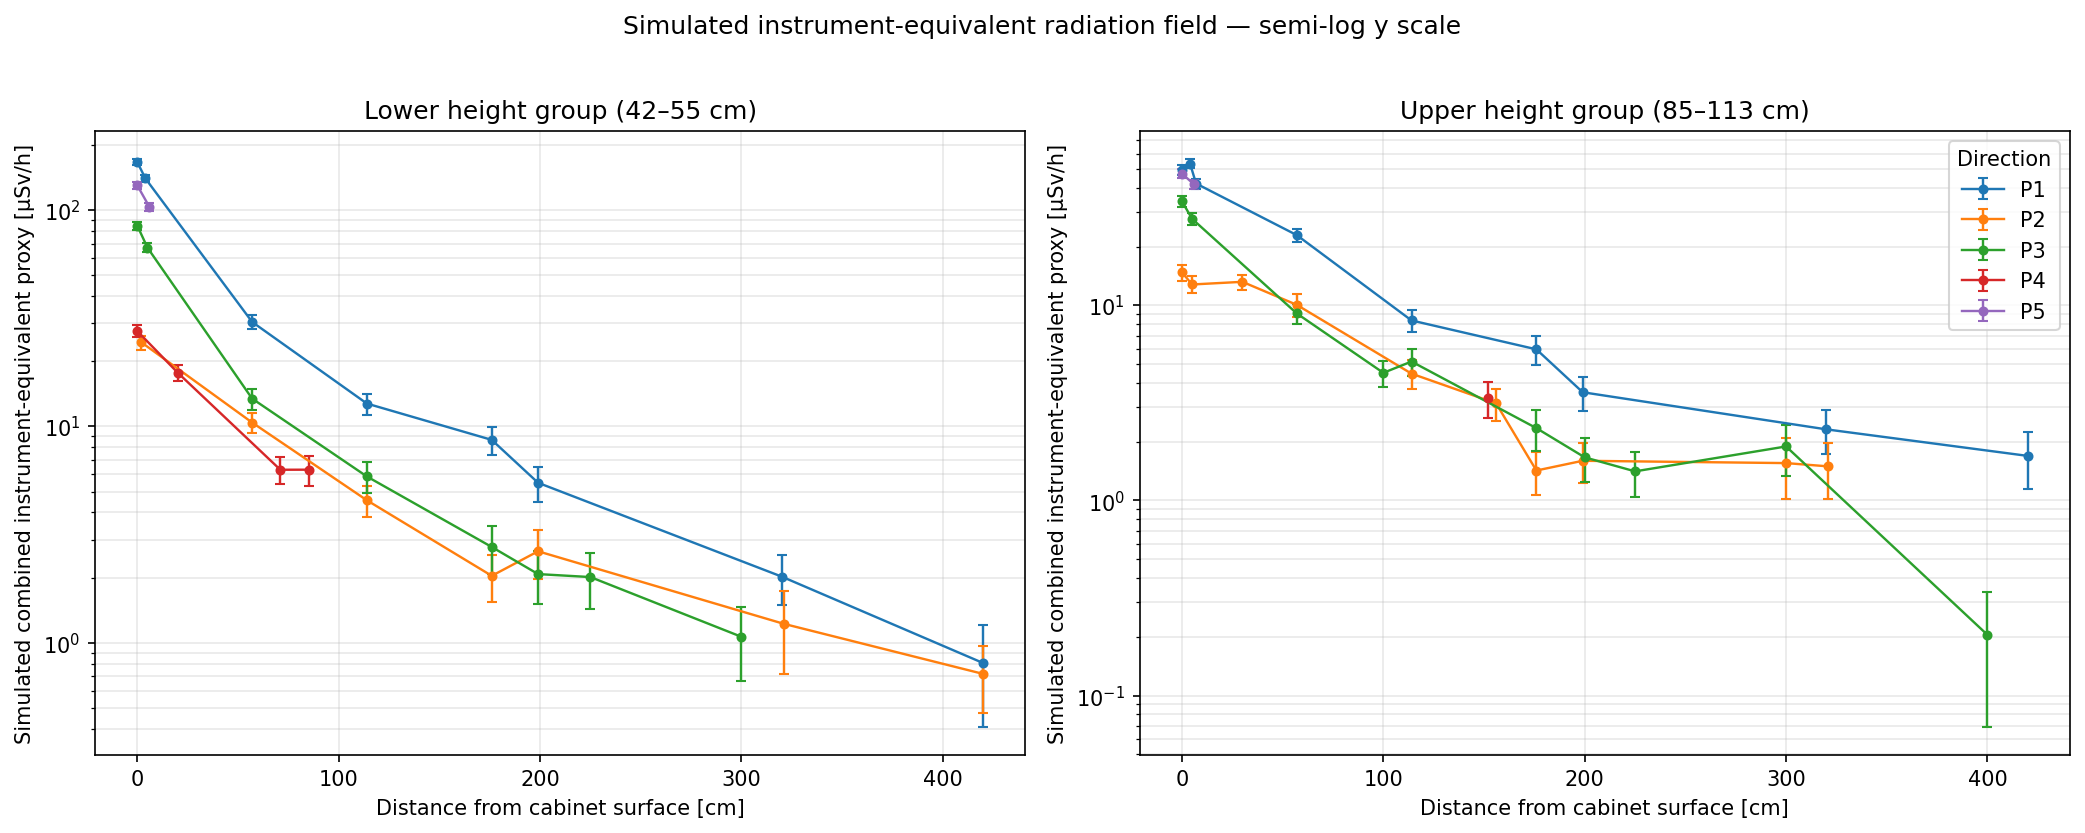

Cs-137 AP reference coefficient: 3.168571e+00 pSv cm²
Saved instrument-proxy table: H2_hollow_cabinet_unified_outputs/tables/hollow_simulated_instrument_equivalent_radiation_field_final.csv
Saved instrument-proxy figure: H2_hollow_cabinet_unified_outputs/figures/simulated_instrument_equivalent_field_semilog.png


,point_name,position,distance_cm,height_cm,height_group,common_dose_x_cm,common_dose_y_cm,common_dose_z_cm,gamma_flux_x_cm,gamma_flux_y_cm,...,u_mc_simulated_combined_instrument_indication [uSv/h],simulated_gamma_instrument_fraction,h1_gamma_group_1_target_reached,h1_gamma_group_1_configured_target_percent,h1_gamma_group_1_max_relative_error_percent,h1_gamma_input_convergence_status,instrument_proxy_status,pairing_method_for_3h,neutron_proxy_response_reference,gamma_proxy_response_reference
0,P1_x0_h42,P1,0.0,42.0,Lower height group (42–55 cm),0.0,-44.25,1.0,0.0,-35.405,...,5.193860,0.010642,False,80.0,100.0,configured 80% exploratory target not demonstr...,response-labelled proxy; not a full detector-r...,"exact position, nominal distance_cm, and nomin...",Studsvik reference centre; ICRP-116 AP spectru...,LND 712 active-centre field; Cs-137-energy AP ...
1,P1_x4_h42,P1,4.0,42.0,Lower height group (42–55 cm),0.0,-48.25,1.0,0.0,-39.405,...,4.539380,0.009339,False,80.0,100.0,configured 80% exploratory target not demonstr...,response-labelled proxy; not a full detector-r...,"exact position, nominal distance_cm, and nomin...",Studsvik reference centre; ICRP-116 AP spectru...,LND 712 active-centre field; Cs-137-energy AP ...
2,P1_x57_h42,P1,57.0,42.0,Lower height group (42–55 cm),0.0,-101.25,1.0,0.0,-92.405,...,2.163314,0.009678,False,80.0,100.0,configured 80% exploratory target not demonstr...,response-labelled proxy; not a full detector-r...,"exact position, nominal distance_cm, and nomin...",Studsvik reference centre; ICRP-116 AP spectru...,LND 712 active-centre field; Cs-137-energy AP ...
3,P1_x114_h42,P1,114.0,42.0,Lower height group (42–55 cm),0.0,-158.25,1.0,0.0,-149.405,...,1.423093,0.011902,False,80.0,100.0,configured 80% exploratory target not demonstr...,response-labelled proxy; not a full detector-r...,"exact position, nominal distance_cm, and nomin...",Studsvik reference centre; ICRP-116 AP spectru...,LND 712 active-centre field; Cs-137-energy AP ...
4,P1_x176_h42,P1,176.0,42.0,Lower height group (42–55 cm),0.0,-220.25,1.0,0.0,-211.405,...,1.262996,0.012132,False,80.0,100.0,configured 80% exploratory target not demonstr...,response-labelled proxy; not a full detector-r...,"exact position, nominal distance_cm, and nomin...",Studsvik reference centre; ICRP-116 AP spectru...,LND 712 active-centre field; Cs-137-energy AP ...
5,P1_x199_h42,P1,199.0,42.0,Lower height group (42–55 cm),0.0,-243.25,1.0,0.0,-234.405,...,0.992497,0.004560,False,80.0,100.0,configured 80% exploratory target not demonstr...,response-labelled proxy; not a full detector-r...,"exact position, nominal distance_cm, and nomin...",Studsvik reference centre; ICRP-116 AP spectru...,LND 712 active-centre field; Cs-137-energy AP ...
6,P1_x320_h42,P1,320.0,42.0,Lower height group (42–55 cm),0.0,-364.25,1.0,0.0,-355.405,...,0.533197,0.000000,False,80.0,100.0,configured 80% exploratory target not demonstr...,response-labelled proxy; not a full detector-r...,"exact position, nominal distance_cm, and nomin...",Studsvik reference centre; ICRP-116 AP spectru...,LND 712 active-centre field; Cs-137-energy AP ...
7,P1_x420_h42,P1,420.0,42.0,Lower height group (42–55 cm),0.0,-464.25,1.0,0.0,-455.405,...,0.396802,0.031049,False,80.0,100.0,configured 80% exploratory target not demonstr...,response-labelled proxy; not a full detector-r...,"exact position, nominal distance_cm, and nomin...",Studsvik reference centre; ICRP-116 AP spectru...,LND 712 active-centre field; Cs-137-energy AP ...
8,P1_x0_h85,P1,0.0,85.0,Upper height group (85–113 cm),0.0,-44.25,44.0,0.0,-35.405,...,2.657396,0.005391,False,80.0,100.0,configured 80% exploratory target not demonstr...,response-labelled proxy; not a full detector-r...,"exact position, nominal distance_cm, and nomin...",Studsvik reference centre; ICRP-116 AP spectru...,LND 712 active-centre field; Cs-137-energy AP ...
9,P1_x4_h85,P1,4.0,85.0,Upper height group (85–113 cm),0.0,-48.25,44.0,0.0,-39.405,...,2.702557,0.004421,False,80.0,100.0

In [36]:
# ------------------------------------------------------------
# Instrument-equivalent proxy definitions
# ------------------------------------------------------------

CS137_REFERENCE_ENERGY_EV = 661_657.0


def loglog_interpolate_positive(x, xp, fp):
    """Log-log interpolation for positive tabulated response coefficients."""

    x = float(x)
    xp = np.asarray(xp, dtype=float)
    fp = np.asarray(fp, dtype=float)
    valid = np.isfinite(xp) & np.isfinite(fp) & (xp > 0.0) & (fp > 0.0)
    xp = xp[valid]
    fp = fp[valid]
    order = np.argsort(xp)
    xp = xp[order]
    fp = fp[order]
    if not (xp[0] <= x <= xp[-1]):
        raise ValueError("The Cs-137 reference energy is outside the coefficient grid.")
    return float(np.exp(np.interp(np.log(x), np.log(xp), np.log(fp))))


CS137_AP_COEFFICIENT_PSV_CM2 = loglog_interpolate_positive(
    CS137_REFERENCE_ENERGY_EV,
    photon_dose_energies,
    photon_dose_coefficients,
)

# Reconstruct the descriptive gamma-flux uncertainty class.
gamma_relative_uncertainty = pd.to_numeric(
    unified_df["rel_u_mc_gamma_flux [%]"],
    errors="coerce",
)

unified_df["gamma_flux_mc_uncertainty_class"] = np.select(
    [
        gamma_relative_uncertainty.ge(0.0)
        & gamma_relative_uncertainty.lt(5.0),

        gamma_relative_uncertainty.ge(5.0)
        & gamma_relative_uncertainty.lt(10.0),

        gamma_relative_uncertainty.ge(10.0)
        & gamma_relative_uncertainty.lt(25.0),

        gamma_relative_uncertainty.ge(25.0),
    ],
    [
        "Low (<5%)",
        "Moderate (5–<10%)",
        "High (10–<25%)",
        "Very high (≥25%)",
    ],
    default="Unknown",
)

print(
    unified_df["gamma_flux_mc_uncertainty_class"]
    .value_counts(dropna=False)
)

# The neutron proxy is the existing spectrum-weighted AP neutron component at
# the Studsvik reference cube. It is explicitly not a digitized 2202D response.
instrument_proxy_df = unified_df[
    [
        "point_name", "position", "distance_cm", "height_cm", "height_group",
        "common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm",
        "gamma_flux_x_cm", "gamma_flux_y_cm", "gamma_flux_z_cm",
        "neutron_dose_rate [uSv/h]", "u_mc_neutron_dose_rate [uSv/h]",
        "gamma_flux [photon/cm2/s]", "u_mc_gamma_flux [photon/cm2/s]",
        "rel_u_mc_gamma_flux [%]", "gamma_flux_mc_uncertainty_class",
    ]
].copy()

instrument_proxy_df = instrument_proxy_df.rename(columns={
    "neutron_dose_rate [uSv/h]": "simulated_2202d_equivalent_proxy [uSv/h]",
    "u_mc_neutron_dose_rate [uSv/h]": "u_mc_simulated_2202d_equivalent_proxy [uSv/h]",
    "rel_u_mc_gamma_flux [%]": "rel_u_mc_simulated_gca_cs137_equivalent_proxy [%]",
    "gamma_flux_mc_uncertainty_class": "simulated_gca_proxy_mc_uncertainty_class",
})

cs137_factor_uSv_h_per_flux = (
    CS137_AP_COEFFICIENT_PSV_CM2 * PSV_PER_S_TO_USV_PER_H
)
instrument_proxy_df["simulated_gca_cs137_equivalent_proxy [uSv/h]"] = (
    instrument_proxy_df["gamma_flux [photon/cm2/s]"]
    * cs137_factor_uSv_h_per_flux
)
instrument_proxy_df["u_mc_simulated_gca_cs137_equivalent_proxy [uSv/h]"] = (
    instrument_proxy_df["u_mc_gamma_flux [photon/cm2/s]"]
    * cs137_factor_uSv_h_per_flux
)

instrument_proxy_df["simulated_combined_instrument_indication [uSv/h]"] = (
    instrument_proxy_df["simulated_2202d_equivalent_proxy [uSv/h]"]
    + instrument_proxy_df["simulated_gca_cs137_equivalent_proxy [uSv/h]"]
)
instrument_proxy_df["u_mc_simulated_combined_instrument_indication [uSv/h]"] = np.sqrt(
    instrument_proxy_df["u_mc_simulated_2202d_equivalent_proxy [uSv/h]"] ** 2
    + instrument_proxy_df["u_mc_simulated_gca_cs137_equivalent_proxy [uSv/h]"] ** 2
)
instrument_proxy_df["simulated_gamma_instrument_fraction"] = np.where(
    instrument_proxy_df["simulated_combined_instrument_indication [uSv/h]"] > 0.0,
    instrument_proxy_df["simulated_gca_cs137_equivalent_proxy [uSv/h]"]
    / instrument_proxy_df["simulated_combined_instrument_indication [uSv/h]"],
    np.nan,
)
instrument_proxy_df["h1_gamma_group_1_target_reached"] = (
    GROUP_1_FLUX_TARGET_REACHED
)
instrument_proxy_df["h1_gamma_group_1_configured_target_percent"] = (
    GROUP_1_FLUX_TARGET_PERCENT
)
instrument_proxy_df["h1_gamma_group_1_max_relative_error_percent"] = (
    GROUP_1_FLUX_MAX_RELATIVE_ERROR_PERCENT
)
instrument_proxy_df["h1_gamma_input_convergence_status"] = (
    H1_GAMMA_INPUT_CONVERGENCE_STATUS
)

instrument_proxy_df["instrument_proxy_status"] = (
    "response-labelled proxy; not a full detector-response calculation and not AP total dose"
)
instrument_proxy_df["pairing_method_for_3h"] = (
    "exact position, nominal distance_cm, and nominal height_cm"
)
instrument_proxy_df["neutron_proxy_response_reference"] = (
    "Studsvik reference centre; ICRP-116 AP spectrum-weighted neutron proxy"
)
instrument_proxy_df["gamma_proxy_response_reference"] = (
    "LND 712 active-centre field; Cs-137-energy AP coefficient proxy"
)

instrument_proxy_output_csv = (
    TABLE_DIR / "hollow_simulated_instrument_equivalent_radiation_field_final.csv"
)
instrument_proxy_df.to_csv(instrument_proxy_output_csv, index=False)


# ------------------------------------------------------------
# Component and combined overview
# ------------------------------------------------------------

# ------------------------------------------------------------
# Component and combined overview — semi-log y scale
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.4),
    dpi=150,
    sharey=False,
)

for axis, group_label in zip(
    axes,
    [LOWER_HEIGHT_LABEL, UPPER_HEIGHT_LABEL],
):
    group = instrument_proxy_df.loc[
        instrument_proxy_df["height_group"].eq(group_label)
    ]

    for position in POSITION_ORDER:
        curve = (
            group.loc[group["position"].eq(position)]
            .sort_values("distance_cm")
        )

        if curve.empty:
            continue

        value_column = (
            "simulated_combined_instrument_indication [uSv/h]"
        )
        uncertainty_column = (
            "u_mc_simulated_combined_instrument_indication [uSv/h]"
        )

        # A logarithmic axis can only display positive values.
        valid = (
            np.isfinite(curve["distance_cm"])
            & np.isfinite(curve[value_column])
            & np.isfinite(curve[uncertainty_column])
            & curve[value_column].gt(0.0)
            & curve[uncertainty_column].ge(0.0)
        )

        curve = curve.loc[valid]

        if curve.empty:
            continue

        axis.errorbar(
            curve["distance_cm"],
            curve[value_column],
            yerr=curve[uncertainty_column],
            marker="o",
            markersize=3.8,
            linewidth=1.15,
            capsize=2.5,
            color=POSITION_COLORS[position],
            label=position,
        )

    # Linear x-axis and logarithmic y-axis.
    axis.set_yscale("log")

    axis.set_title(group_label)
    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel(
        "Simulated combined instrument-equivalent proxy [µSv/h]"
    )
    axis.grid(
        True,
        which="both",
        alpha=0.28,
    )

axes[1].legend(
    title="Direction",
    loc="best",
)

fig.suptitle(
    "Simulated instrument-equivalent radiation field — semi-log y scale",
    y=1.02,
)

fig.tight_layout()

instrument_proxy_figure_path = (
    FIGURE_DIR / "simulated_instrument_equivalent_field_semilog.png"
)

fig.savefig(
    instrument_proxy_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(
    f"Cs-137 AP reference coefficient: "
    f"{CS137_AP_COEFFICIENT_PSV_CM2:.6e} pSv cm²"
)
print(f"Saved instrument-proxy table: {instrument_proxy_output_csv}")
print(f"Saved instrument-proxy figure: {instrument_proxy_figure_path}")

display(instrument_proxy_df.head(10))


# 16) Summary, interpretation, and limitations

Notebook 2H produces one 61-point hollow-cabinet simulation table containing:

- the original H1 detector-specific neutron and gamma fluxes with their own
  physical centres and tally volumes;
- co-located common-cube neutron and gamma fluxes for valid local flux-ratio
  diagnostics;
- energy-dependent AP neutron and gamma dose-rate components;
- total AP dose rate, formed only after the two dose components are compatible;
- propagated OpenMC batch-statistical standard uncertainties;
- explicitly labelled Studsvik- and GCA-equivalent comparison proxies.

The adopted cabinet is fixed to the front f2 + both f1 air-layer model, with
the rear f2, bottom, and top solid. The physical source normalizations are the
same as in 1H. The H1 photon weight windows alter transport efficiency only;
they do not provide source normalization and are not reused as statistical
histories.

The final table is the simulation input for
`3H_Hollow_vs_measurement.ipynb`. The reported uncertainty remains Monte Carlo
precision only and must not be interpreted as a complete experimental or model
uncertainty budget.
